In [341]:
#| label: setup
#| results: "hold"

rm(list = ls()); gc()

required_packages <- c("dplyr", "readr", "haven", 
                       "ggplot2", "gridExtra", 
                       "fitdistrplus", "MASS", 
                      # Added by me
                      "janitor", "tidyr",
                      # Added posteriorly:
                      "readxl",
                      # MWE
                      "MicSim")

# Install and load required packages
sapply(required_packages, function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) install.packages(pkg)
  library(pkg, character.only = TRUE)
})


      dplyr          readr          haven          ggplot2        gridExtra      fitdistrplus   MASS           janitor        tidyr          readxl         MicSim        
 [1,] "patchwork"    "patchwork"    "patchwork"    "patchwork"    "patchwork"    "patchwork"    "patchwork"    "patchwork"    "patchwork"    "patchwork"    "patchwork"   
 [2,] "writexl"      "writexl"      "writexl"      "writexl"      "writexl"      "writexl"      "writexl"      "writexl"      "writexl"      "writexl"      "writexl"     
 [3,] "htmltools"    "htmltools"    "htmltools"    "htmltools"    "htmltools"    "htmltools"    "htmltools"    "htmltools"    "htmltools"    "htmltools"    "htmltools"   
 [4,] "MicSim"       "MicSim"       "MicSim"       "MicSim"       "MicSim"       "MicSim"       "MicSim"       "MicSim"       "MicSim"       "MicSim"       "MicSim"      
 [5,] "readxl"       "readxl"       "readxl"       "readxl"       "readxl"       "readxl"       "readxl"       "readxl"       "readxl"       "rea

In [342]:
#| label: stree-structure
#| results: "hold"

# ├── ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/
# │   ├── .RData
# │   ├── .Rhistory
# │   ├── ENPG_FULL.RDS
# │   ├── PAF INJURIES.rds
# │   ├── PAF INJURIES_SENS.rds
# │   ├── PIF injuries.rds
# │   ├── PIF-BINGE.R
# │   ├── README.md
# │   ├── ine_proyecciones.xlsx
# │   └── mortality_injuries.rds
# ├── Elasticidad/
# │   ├── Data/
# │   ├── Scripts/
# │   └── README.md
# ├── FONDECYT-REGULAR--main/
# │   ├── .Rproj.user/
# │   ├── rawdata/
# │   ├── .Rhistory
# │   ├── .gitignore
# │   ├── 02-11.RData
# │   ├── 3-11.RData
# │   ├── 30-10.RData
# │   ├── 31-10.RData
# │   ├── 4-11.RData
# │   ├── DATA PREPARATION ENPG.R
# │   └── ... and 15 more
# ├── Mortalidad/
# │   ├── Data/
# │   ├── Matrices/
# │   ├── Scripts/
# │   └── README.md
# ├── Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/
# │   ├── .Rproj.user/
# │   ├── Raw data/
# │   ├── .Rhistory
# │   ├── DATA PREPARATION ENPG.R
# │   ├── Paper mortality trends.R
# │   ├── README.md
# │   └── Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main.Rproj
# ├── Simulacion/
# │   ├── Alcohol Transitions FINAL.R
# │   ├── Alcohol Transitions_CALIB.R
# │   ├── IMIS ALCOHOL.R
# │   ├── IPF PREP.R
# │   ├── MWE.R
# │   └── README.md
# ├── __andres_control/
# │   ├── _lib/
# │   ├── 00_inventory_jrt_files.R
# │   ├── 01_inspect_rds_objects.R
# │   ├── jrt_duplicate_hashes.csv
# │   ├── jrt_duplicate_names.csv
# │   ├── jrt_file_inventory.csv
# │   ├── jrt_rds_inventory.csv
# │   ├── revision_datos.html
# │   └── revision_datos.ipynb
# ├── 01_mapa_material_jrt.md
# └── 04_avance_para_reunion_15_mayo.md


### Mortality

#### Final PAF

- Results matrix: 1,248 × 8  
- Dimensions: causes × years × sex × age  
- Full calculation performed for the entire period  [@shield2020national]

In [343]:
#| label: population-attributable-fraction
#| results: "hold"
PAF_FINAL <- readRDS(paste0(gsub("/__andres_control","",getwd()),"/","Mortalidad/Matrices/PAF FINAL.rds")) 

In [344]:
#| label: PAF-explore-structure
#| results: "hold"

dplyr::glimpse(PAF_FINAL)

Rows: 1,248
Columns: 8
$ year      <dbl> 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008, 2008…
$ age_group <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2…
$ gender    <chr> "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer…
$ disease   <chr> "Acute Pancreatitis", "Colon and rectum Cancer", "DM2", "Epilepsy", "HIV", "Hypertensive Heart Disease", "Intentional Injuries", "Intracerebral Haemorrhage", "Ischaemic Heart Disease", "Ischaemic …
$ deaths    <dbl> 6, 2, 0, 15, 35, 2, 314, 18, 20, 2, 0, 1, 3, 6, 13, 0, 422, 6, 301, 4, 8, 2, 1, 4, 6, 2, 22, 15

In [345]:
#| label: avg-PAF-of-deaths

PAF_FINAL |>
  count(disease, gender) |>
  left_join(
    aggregate(point ~ gender+disease, 
          data = PAF_FINAL, 
          FUN = mean),
    by = c("disease", "gender")
  ) |> 
    left_join(
    aggregate(lower ~ gender+disease, 
          data = PAF_FINAL, 
          FUN = mean),
    by = c("disease", "gender")
  ) |>  
        left_join(
    aggregate(upper ~ gender+disease, 
          data = PAF_FINAL, 
          FUN = mean),
    by = c("disease", "gender")
  ) |> 
  dplyr::rename("avg_PAF"="point")|> 
  knitr::kable("markdown", caption="PAF by gender and disease (non-weighted)")



Table: PAF by gender and disease (non-weighted)

|disease                     |gender |  n|    avg_PAF|      lower|      upper|
|:---------------------------|:------|--:|----------:|----------:|----------:|
|Acute Pancreatitis          |Hombre | 32|  0.4325312|  0.3303727|  0.5525648|
|Acute Pancreatitis          |Mujer  | 32|  0.3163977|  0.2991250|  0.3331250|
|Breast Cancer               |Mujer  | 32|  0.0674062|  0.0529375|  0.0832508|
|Colon and rectum Cancer     |Hombre | 32|  0.3447188|  0.3188734|  0.3704695|
|Colon and rectum Cancer     |Mujer  | 32|  0.0366875|  0.0253750|  0.0484375|
|DM2                         |Hombre | 32|  0.0633835|  0.0493438|  0.0942195|
|DM2                         |Mujer  | 32| -0.0384564| -0.0739383| -0.0038125|
|Epilepsy                    |Hombre | 32|  0.2601562|  0.0952766|  0.4422508|
|Epilepsy                    |Mujer  | 32|  0.0873750|  0.0313125|  0.1530953|
|HIV                         |Hombre | 32|  0.0482187|  0.0288750|  0.0701875|
|

#### PAF injuries

In [346]:
#| label: population-attributable-fraction-injuries
#| results: "hold"

PAF_INJURIES <- readRDS(paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/PAF INJURIES.rds"))
PAF_INJURIES_private <- readRDS(paste0(gsub("/__andres_control","",getwd()),"/","Mortalidad/Matrices/PAF INJURIES.rds"))

cat("Are they identical objects?")
identical(PAF_INJURIES,PAF_INJURIES_private)

Are they identical objects?

[1] FALSE

In [347]:
#| label: PAF-injuries-explore-structure
#| results: "hold"

dplyr::glimpse(PAF_INJURIES)

Rows: 192
Columns: 7
$ year      <int> 2008, 2008, 2008, 2008, 2010, 2010, 2010, 2010, 2012, 2012, 2012, 2012, 2014, 2014, 2014, 2014, 2016, 2016, 2016, 2016, 2018, 2018, 2018, 2018, 2020, 2020, 2020, 2020, 2022, 2022, 2022, 2022, 2008…
$ age_group <int> 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2…
$ gender    <chr> "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer"…
$ point     <dbl> 0.345, 0.191, 0.182, 0.161, 0.340, 0.240, 0.182, 0.127, 0.315, 0.196, 0.170, 0.103, 0.364, 0.282, 0.222, 0.122, 0.380, 0.248, 0.191, 0.115, 0.356, 0.351, 0.184, 0.195, 0.397, 0.307, 0.257, 0.126, …
$ lower     <dbl> 0.275, 0.148, 0.145, 0.126, 0.267, 0.183, 0.139, 0.099, 0.253, 0.150, 0.133, 0.083, 0.294, 0.226,

In [348]:
#| label: PAF-injuries-private-explore-structure
#| results: "hold"

dplyr::glimpse(PAF_INJURIES_private)

Rows: 192
Columns: 7
$ year      <int> 2008, 2008, 2008, 2008, 2010, 2010, 2010, 2010, 2012, 2012, 2012, 2012, 2014, 2014, 2014, 2014, 2016, 2016, 2016, 2016, 2018, 2018, 2018, 2018, 2020, 2020, 2020, 2020, 2022, 2022, 2022, 2022, 2008…
$ age_group <int> 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2…
$ gender    <chr> "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer"…
$ point     <dbl> 0.344, 0.191, 0.182, 0.161, 0.340, 0.242, 0.183, 0.127, 0.316, 0.196, 0.170, 0.103, 0.365, 0.282, 0.222, 0.122, 0.380, 0.248, 0.191, 0.115, 0.355, 0.351, 0.183, 0.195, 0.398, 0.307, 0.257, 0.127, …
$ lower     <dbl> 0.274, 0.148, 0.145, 0.125, 0.267, 0.184, 0.140, 0.099, 0.254, 0.150, 0.133, 0.083, 0.294, 0.225,

In [349]:
#| label: PAF-injuries-private-explore-structure2
#| results: "hold"

dplyr::bind_rows(summary(PAF_INJURIES$point), summary(PAF_INJURIES_private$point)) |> knitr::kable("markdown", caption= "Differences between PAF for injuries in one database vs. private")



Table: Differences between PAF for injuries in one database vs. private

|  Min.| 1st Qu.| Median|      Mean| 3rd Qu.|  Max.| NA's|
|-----:|-------:|------:|---------:|-------:|-----:|----:|
| 0.031|   0.183| 0.3105| 0.3406105| 0.56775| 0.659|    2|
| 0.031|   0.183| 0.3130| 0.3419896| 0.56400| 0.659|   NA|

#### PAF injuries sens

In [350]:
#| label: population-attributable-fraction-injuries-sens
#| results: "hold"

PAF_INJURIES_sens <- readRDS(paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/PAF INJURIES_sens.rds"))

In [351]:
#| label: population-attributable-fraction-injuries-sens-str
#| results: "hold"

dplyr::glimpse(PAF_INJURIES_sens)

Rows: 192
Columns: 7
$ year      <int> 2008, 2008, 2008, 2008, 2010, 2010, 2010, 2010, 2012, 2012, 2012, 2012, 2014, 2014, 2014, 2014, 2016, 2016, 2016, 2016, 2018, 2018, 2018, 2018, 2020, 2020, 2020, 2020, 2022, 2022, 2022, 2022, 2008…
$ age_group <int> 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2…
$ gender    <chr> "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer", "Mujer"…
$ point     <dbl> 0.300, 0.145, 0.140, 0.103, 0.274, 0.177, 0.137, 0.099, 0.248, 0.152, 0.155, 0.100, 0.280, 0.258, 0.188, 0.103, 0.296, 0.179, 0.155, 0.098, 0.283, 0.275, 0.155, 0.165, 0.326, 0.265, 0.186, 0.095, …
$ lower     <dbl> 0.248, 0.119, 0.115, 0.089, 0.225, 0.144, 0.110, 0.079, 0.210, 0.124, 0.123, 0.080, 0.238, 0.211,

In [352]:
 #| label: population-attributable-fraction-injuries-sens-str2
#| results: "hold"

 summary(PAF_INJURIES_sens$point)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0150  0.1210  0.1880  0.2769  0.5112  0.6030 

#### PIF

In [353]:
#| label: potential-impact-fraction-injuries
#| results: "hold"

PIF_INJURIES <- readRDS(paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/PIF INJURIES.rds"))
PIF_INJURIES_private <- readRDS(paste0(gsub("/__andres_control","",getwd()),"/","Mortalidad/Matrices/PIF injuries.rds"))

cat("Are they identical objects?")
identical(PIF_INJURIES,PIF_INJURIES_private)


Are they identical objects?

[1] TRUE

In [354]:
#| label: potential-impact-fraction-injuries-str
#| results: "hold"

dplyr::glimpse(PIF_INJURIES)

Rows: 144
Columns: 16
$ Year    <dbl> 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2008, …
$ PIF_ag1 <dbl> 0.107, 0.127, 0.101, 0.113, 0.109, 0.127, 0.137, 0.133, 0.071, 0.085, 0.067, 0.075, 0.072, 0.085, 0.091, 0.089, 0.036, 0.042, 0.034, 0.038, 0.036, 0.042, 0.046, 0.044, 0.107, 0.127, 0.101, 0.113, 0.…
$ LL_ag1  <dbl> 0.077, 0.097, 0.072, 0.083, 0.078, 0.096, 0.105, 0.103, 0.051, 0.064, 0.048, 0.055, 0.052, 0.064, 0.070, 0.069, 0.026, 0.032, 0.024, 0.028, 0.026, 0.032, 0.035, 0.034, 0.077, 0.097, 0.072, 0.083, 0.…
$ UL_ag1  <dbl> 0.137, 0.157, 0.130, 0.143, 0.139, 0.158, 0.166, 0.162, 0.091, 0.104, 0.087, 0.095, 0.092, 0.105, 0.111, 0.108, 0.046, 0.052, 0.043, 0.048, 0.046, 0.053, 0.055, 0.054, 0.137, 0.157, 0.130, 0.143, 0.…
$ PIF_ag2 <dbl> 0.066, 0.100, 0.076, 0.086, 0.080, 0.136, 0.093, 0.111, 0.044, 0.067, 0.051, 0.057, 0.053, 0.091, 

**PENDING**

- Only covers injuries  
- Former drinkers must be incorporated into the PIF calculation for other causes  
- Former drinkers have a different risk profile compared to current drinkers and abstainers  

**IMPLICATION**  
Not considering former drinkers may bias the PIF downward, underestimating the potential impact of consumption-reduction policies on chronic causes (e.g., liver disease, cancer, cardiovascular).  

### Potentially Avoidable Injury Mortality and Years of Potential Life Lost through Reduction of Heavy Episodic Drinking in Chile

#### ENPG's Daily use by age group and sexo + categorization

National Household Survey on Drug Use: 2008–2022, three-stage sampling, non-institutionalized population at national and regional levels. Alcohol consumption was estimated by weighting for each subpopulation of interest: sex and age groups. For alcohol use, AUDIT-C included three questions: frequency and quantity of alcohol, and use and frequency of HED. These were then triangulated with per capita alcohol consumption estimates. The per capita benchmark was external to the survey and served as a correction factor. Capping was set at 150 g.

- `volajohdia`: average daily grams or volume of alcohol.  
- `sexo`: Male/Female.  
- `edad_tramo`: age group, coded 1 to 4.  
- `hed`: whether the person engages in HED/binge drinking. 1 = HED, 0 = non-HED.  
- `exp`: survey weight, i.e., how much that person represents in the population.  
- `cvolaj`: consumption category, e.g., `ltabs` (lifetime abstainer) or `fd` (former drinker, if no alcohol in the last 30 days or more than 1 year).  
- `years_vec`: analyzed years, 2008 to 2022.  

Alcohol-consumption status was operationalized using the variable `cvolaj`, which classified respondents into lifetime abstainers (`ltabs`), former drinkers (`fd`), and current drinkers categorized by sex-specific average daily alcohol volume. Lifetime abstainers reported no alcohol use, while former drinkers had previous alcohol use but no recent/current drinking. Current drinkers were classified into four volume categories:  
- `cat1`: >0–19.99 g/day in women, >0–39.99 g/day in men.  
- `cat2`: 20–39.99 g/day in women, 40–59.99 g/day in men.  
- `cat3`: 40–60 g/day in women, 60–100 g/day in men.  
- `cat4`: >60 g/day in women, >100 g/day in men.  

These categories describe average daily pure alcohol consumption and were distinct from the heavy episodic drinking indicator, which captured binge-pattern drinking among current drinkers [@ruiztagle2025potentially].

In [ ]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red1-SUD
#| results: "hold"

data <- readRDS(paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ENPG_FULL.RDS")) %>% 
  mutate(aux = ifelse(oh1 == "No" & !is.na(oh2) ,1,0)) %>% 
  filter(aux == 0) %>% 
  dplyr::select(-aux) 

data_input <- data %>% 
  dplyr::mutate(edad_tramo = case_when(between(edad, 15, 29)~1,
                                between(edad, 30,44)~2,
                                between(edad,45,59)~3,
                                between(edad,60,65)~4),
         cvolaj = case_when(oh1 == "No" ~ "ltabs",
                            oh2 == ">30" | oh2 == ">1 año" ~ "fd",
                            sexo == "Mujer" & volajohdia > 0 & volajohdia <= 19.99 ~ "cat1",
                            sexo == "Mujer" & volajohdia >= 20 & volajohdia <= 39.99 ~ "cat2",
                            sexo == "Mujer" & volajohdia >= 40 & volajohdia <= 60  ~ "cat3",
                            sexo == "Mujer" & volajohdia > 60 ~ "cat4",
                            sexo == "Hombre" & volajohdia > 0 & volajohdia <= 39.99 ~ "cat1",
                            sexo == "Hombre" & volajohdia >= 40 & volajohdia <= 59.99 ~ "cat2",
                            sexo == "Hombre" & volajohdia >= 60 & volajohdia<= 100 ~ "cat3",
                            sexo == "Hombre" & volajohdia > 100 ~ "cat4",
                            TRUE ~ NA),
         hed = ifelse(dias_binge > 0,1,0)) %>% 
  dplyr::select(year, sexo, exp, edad_tramo, volajohdia, cvolaj,hed)

cat(paste0("I guess that `exp` is the aggregated expansion factor (average by year): ", data_input |>  group_by(year) |> summarise(sum= sum(exp)) |> pull(sum) |> mean() |>  round(0)  ))
head(data_input) |> 
  knitr::kable("markdown", caption= "Substance use patterns by year, age, sex, classification and HED/NHED")

I guess that `exp` is the aggregated expansion factor (average by year): 9820915



Table: Substance use patterns by year, age, sex, classification and HED/NHED

| year|sexo   |      exp| edad_tramo| volajohdia|cvolaj | hed|
|----:|:------|--------:|----------:|----------:|:------|---:|
| 2008|Hombre | 114.3656|          1|   0.000000|fd     |   0|
| 2008|Hombre | 228.7313|          2|   0.000000|NA     |   0|
| 2008|Mujer  | 285.9141|          1|   0.000000|ltabs  |   0|
| 2008|Mujer  | 114.3656|          4|   4.489333|cat1   |   0|
| 2008|Mujer  | 114.3656|          2|   2.244667|cat1   |   0|
| 2008|Hombre | 285.9141|          1|  25.813667|cat1   |   1|

Build lists of positive daily consumption, separated by year, age group, sex, and HED/NHED. Then, for `volajohdia > 0` (excluding abstainers), take the consumption list and fit a gamma distribution for each combination of year–age group–sex–HED/NHED, to smooth the distribution ([@gmel2011estimating]).

In [356]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red2-HED-smooth-use-helpers
#| results: "hold"

# Construye lista de consumos por aÃ±o x tramo x HED/NHED (para un sexo)
build_cd_hed_list <- function(df, sexo_value, years_vec) {
  out <- vector("list", length(years_vec))
  names(out) <- as.character(years_vec)
  for (yy in years_vec) {
    out[[as.character(yy)]] <- list()
    for (tr in 1:4) {
      for (hv in c(0L, 1L)) {
        key <- paste0("edad", tr, ifelse(hv == 0L, "_nhed", "_hed"))
        out[[as.character(yy)]][[key]] <- df %>%
          filter(volajohdia > 0,
                 sexo == sexo_value,
                 edad_tramo == tr,
                 hed == hv,
                 year == yy) %>%
          pull(volajohdia)
      }
    }
  }
  out
}

# Ajusta gamma por aÃ±o x tramo, devuelve estructura [[year]][[tramo]]$nhed/$hed
fit_gamma_by_tramo <- function(cd_hed_list) {
  out <- vector("list", length(cd_hed_list))
  names(out) <- names(cd_hed_list)
  for (yy in names(cd_hed_list)) {
    out[[yy]] <- vector("list", 4)
    for (tr in 1:4) {
      nhed_key <- paste0("edad", tr, "_nhed")
      hed_key  <- paste0("edad", tr, "_hed")
      data_nh <- cd_hed_list[[yy]][[nhed_key]]
      data_h  <- cd_hed_list[[yy]][[hed_key]]
      out[[yy]][[tr]] <- list(
        nhed = if (length(data_nh) > 1) fitdist(data_nh, "gamma") else NULL,
        hed  = if (length(data_h)  > 1) fitdist(data_h,  "gamma") else NULL
      )
    }
  }
  out
}

# Construye s_hed (HED/(HED+NHED)) ponderado por 'exp' para each year x tramo, devuelto como lista [[tramo]][i_year]
build_s_hed_list_weighted <- function(df, sexo_value, years_vec) {
  tmp <- df %>%
    filter(volajohdia > 0,
           sexo == sexo_value,
           year %in% years_vec,
           edad_tramo %in% 1:4,
           hed %in% c(0L, 1L)) %>%
    group_by(year, edad_tramo, hed) %>%
    summarise(w = sum(exp, na.rm = TRUE), .groups = "drop") %>%
    complete(year = years_vec, edad_tramo = 1:4, hed = 0:1, fill = list(w = 0)) %>%
    group_by(year, edad_tramo) %>%
    mutate(w_tot = sum(w),
           s_hed = ifelse(w_tot > 0, w[hed == 1] / w_tot, NA_real_)) %>%
    ungroup() %>%
    filter(hed == 1) %>%
    arrange(edad_tramo, match(year, years_vec))
  split(tmp$s_hed, tmp$edad_tramo)
}

# ProporciÃ³n ponderada por exp de una categorÃ­a cvolaj (ltabs o fd),
# por sexo, aÃ±o y tramo de edad. Devuelve lista de 4 vectores (aÃ±os en el orden de years_vec).
build_prop_list_weighted <- function(data_input, sexo, years_vec, cvolaj_value) {
  stopifnot(cvolaj_value %in% c("ltabs", "fd"))
  
  # asegurar tipos
  df <- data_input %>%
    dplyr::mutate(
      year = as.integer(year),
      edad_tramo = as.integer(edad_tramo),
      sexo = as.character(sexo)
    ) %>%
    dplyr::filter(!is.na(cvolaj), !is.na(exp), sexo == !!sexo, year %in% years_vec, edad_tramo %in% 1:4)
  
  # tabla de proporciones ponderadas por (year, edad_tramo)
  props <- df %>%
    dplyr::group_by(year, edad_tramo) %>%
    dplyr::summarise(
      wt_sum_all = sum(exp, na.rm = TRUE),
      wt_sum_cat = sum(exp[cvolaj == cvolaj_value], na.rm = TRUE),
      .groups = "drop"
    ) %>%
    dplyr::mutate(prop = dplyr::if_else(wt_sum_all > 0, wt_sum_cat / wt_sum_all, NA_real_))
  
  # construir lista: Ã­ndice 1..4 = tramo; cada elemento = vector en orden de years_vec
  out <- lapply(1:4, function(tr) {
    v <- sapply(years_vec, function(y) {
      row <- props %>% dplyr::filter(year == y, edad_tramo == tr)
      if (nrow(row) == 1) row$prop else NA_real_
    })
    as.numeric(v)
  })
  out
}

The following lists are created:

- Observed consumption for women/men, separated into HED/NHED.  
- Gamma distributions fitted for women/men.  
- Weighted proportion of women/men drinkers who engage in HED.  
- Weighted proportion of women/men in the lifetime abstainer category.  
- Weighted proportion of women/men in the former drinker category.  

Former drinkers (RR = 1) who are now abstainers are assigned the same risk as those who have never consumed alcohol. Only the HED group receives the additional “surcharge” for intensity of consumption (volume ≥ 60 g).  

In [357]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red3-HED-smooth-use-apply
#| results: "hold"

#Aplicar para calcular la proporciÃ³n de HED por edad y aÃ±os
build_abs_list_weighted  <- function(data_input, sexo, years_vec) build_prop_list_weighted(data_input, sexo, years_vec, "ltabs")
build_form_list_weighted <- function(data_input, sexo, years_vec) build_prop_list_weighted(data_input, sexo, years_vec, "fd")

years_vec <- c(2008L, 2010L, 2012L, 2014L, 2016L, 2018L, 2020L, 2022L)

# Mujeres
cd_fem_hed_list   <- build_cd_hed_list(data_input, "Mujer",  years_vec)
g_fem_hed_list    <- fit_gamma_by_tramo(cd_fem_hed_list)
p_hed_list_fem    <- build_s_hed_list_weighted(data_input, "Mujer",  years_vec)
p_abs_list_fem  <- build_abs_list_weighted(data_input,  "Mujer", years_vec)
p_form_list_fem <- build_form_list_weighted(data_input, "Mujer", years_vec)

# Hombres
cd_male_hed_list  <- build_cd_hed_list(data_input, "Hombre", years_vec)
g_male_hed_list   <- fit_gamma_by_tramo(cd_male_hed_list)
p_hed_list_male   <- build_s_hed_list_weighted(data_input, "Hombre", years_vec)
p_abs_list_male  <- build_abs_list_weighted(data_input,  "Hombre", years_vec)  # ltabs
p_form_list_male <- build_form_list_weighted(data_input, "Hombre", years_vec)  # fd

Definimos las funciones para calcular PAF/FAA combinando abstinentes, former drinkers, consumidores NHED y HED. Para eso toma las proporciones poblacionales y aplica las funciones de RR para NHED y HED, integra el *excess risk* con la regla trapezoidal. 

Luego calcula la PIF (fracciÃ³n ed impacto potencial) si se logra hacer que personas pasen a NHED [no se asume que pasan a abstemio, sino que cambian a NHED (*shift*)]

Para obtener intervalos de `confint_paf_hed` y `confint_pif_hed`, se calcularon intervalos de incertidumbre al generar muchos conjuntos aleatorios de parÃ¡metros de bajo nivel y ver la variabilidad resultante.

In [358]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red4-PAF-funcs
#| results: "hold"

# PAF con HED en 0â€“150, incluyendo p_abs y p_form
paf_hed_function <- function(
    x,                 # grilla comÃºn (p.ej., seq(0.1,150,length.out=1500))
    y_nhed, y_hed,     # densidades (dgamma) para nHED y HED en la grilla x
    rr_nhed, rr_hed,   # RR(x) para nHED y HED en la grilla x
    rr_form,           # RR de ex-bebedores vs abstinentes (constante)
    p_abs, p_form,     # proporciones de lifetime abstainers y former drinkers
    p_hed              # fracciÃ³n HED dentro de current drinkers
){
  trap_int <- function(x, f){
    if (length(x) < 2L) return(0)
    dx <- diff(x)
    sum((f[-1] + f[-length(f)]) * dx / 2)
  }
  seg_num <- function(x, y, rr, weight){
    Z <- trap_int(x, y)
    if (!is.finite(Z) || Z <= 0) return(0)
    dens_norm <- weight * y / Z
    trap_int(x, dens_norm * (rr - 1))  # exceso de riesgo
  }
  
  w_curr <- 1 - (p_abs + p_form)
  if (w_curr < 0) w_curr <- 0
  
  num_form <- (rr_form - 1) * p_form
  num_nhed <- seg_num(x, y_nhed, rr_nhed, w_curr * (1 - p_hed))
  num_hed  <- seg_num(x, y_hed,  rr_hed,  w_curr * p_hed)
  
  num <- num_form + num_nhed + num_hed
  den <- 1 + num
  num / den
}

confint_paf_hed <- function(
    x,
    fit_nhed, fit_hed,           # objetos 'fitdist' (gamma) para nHED y HED
    rr_fun_nhed,                 # function(x, b1)
    rr_fun_hed,                  # function(x, c(b1, b2))
    beta_mean_nhed, beta_var_nhed,  # media/var de b1 (pendiente comÃºn)
    beta_mean_b2,   beta_var_b2,    # media/var de b2 (intercepto HED)
    p_abs, p_form, s_hed,        # proporciones puntuales
    rr_form = 1,
    n_sim = 10000,
    neff_prev = 1000,
    seed = 145
){
  set.seed(seed)
  
  dens_from_fit <- function(fit, x){
    est <- fit$estimate
    if ("rate" %in% names(est))  return(dgamma(x, shape = est[["shape"]], rate  = est[["rate"]]))
    if ("scale" %in% names(est)) return(dgamma(x, shape = est[["shape"]], scale = est[["scale"]]))
    stop("fit$estimate debe tener 'rate' o 'scale'.")
  }
  y_nhed <- dens_from_fit(fit_nhed, x)
  y_hed  <- dens_from_fit(fit_hed,  x)
  
  clamp01 <- function(p, eps=1e-6) pmin(pmax(p, eps), 1 - eps)
  
  sims <- numeric(n_sim)
  for (i in seq_len(n_sim)) {
    # 1) Simular Î²1 y Î²2 (independientes)
    b1_i <- if (beta_var_nhed > 0) rnorm(1, beta_mean_nhed, sqrt(beta_var_nhed)) else beta_mean_nhed
    b2_i <- if (beta_var_b2   > 0) rnorm(1, beta_mean_b2,   sqrt(beta_var_b2))   else beta_mean_b2
    
    # 2) RR en grilla
    rr_nhed <- rr_fun_nhed(x, b1_i)
    rr_hed  <- rr_fun_hed( x, c(b1_i, b2_i))
    
    # 3) Re-simular proporciones (suave)
    p_abs_i  <- clamp01(rnorm(1, p_abs,  sqrt(p_abs  * (1 - p_abs)  / neff_prev)))
    p_form_i <- clamp01(rnorm(1, p_form, sqrt(p_form * (1 - p_form) / neff_prev)))
    s_hed_i  <- clamp01(rnorm(1, s_hed,  sqrt(s_hed  * (1 - s_hed)  / neff_prev)))
    
    # 4) PAF
    sims[i] <- paf_hed_function(
      x = x,
      y_nhed = y_nhed, y_hed = y_hed,
      rr_nhed = rr_nhed, rr_hed = rr_hed,
      rr_form = rr_form,
      p_abs = p_abs_i, p_form = p_form_i, p_hed = s_hed_i
    )
  }
  
  sims <- sims[is.finite(sims)]
  if (!length(sims)) stop("Todas las simulaciones fallaron. Revisa insumos.")
  
  list(
    point_estimate = round(mean(sims), 3),
    lower_ci       = round(quantile(sims, 0.025), 3),
    upper_ci       = round(quantile(sims, 0.975), 3),
    sims = sims
  )
}

# PIF con dos segmentos (0â€“150): nhed y hed
# - Integra por separado: R_nhed y R_hed
# - Pondera por p_abs, p_form y fracciÃ³n HED entre current (s_hed)
# - Contrafactual: reduce HED por 'shift' y migra esa masa a N-HED
# PIF solo entre current drinkers
pif_hed_function <- function(
    x, fit_nhed, fit_hed,
    rr_fun_nhed, rr_fun_hed,
    b,                 # escalar o list(nhed = b, hed = c(b1, b2))
    s_hed,             # fracciÃ³n HED entre current
    shift = 1
){
  # utilidades
  trap_int <- function(x, f){ #integraciÃ³n trapezoidal
    if (length(x) < 2L) return(0)
    dx <- diff(x)
    sum((f[-1] + f[-length(f)]) * dx / 2)
  }
  seg_risk <- function(x, y, rr){
    Z <- trap_int(x, y)
    if (!is.finite(Z) || Z <= 0) return(0)
    trap_int(x, (y / Z) * rr)
  }
  dens_from_fit <- function(fit, x){
    est <- fit$estimate
    if ("rate" %in% names(est))  return(dgamma(x, shape = est[["shape"]], rate  = est[["rate"]]))
    if ("scale" %in% names(est)) return(dgamma(x, shape = est[["shape"]], scale = est[["scale"]]))
    stop("fit$estimate debe tener 'rate' o 'scale'.")
  }
  
  # 1) densidades
  y_nhed <- dens_from_fit(fit_nhed, x)
  y_hed  <- dens_from_fit(fit_hed,  x)
  
  # 2) parÃ¡metros y RRs (acepta b escalar o lista)
  par_nhed <- if (is.list(b)) b$nhed else b
  par_hed  <- if (is.list(b)) b$hed  else b
  
  rr_nhed <- rr_fun_nhed(x, par_nhed)      # e.g. exp(b * x)
  rr_hed  <- rr_fun_hed( x, par_hed )      # e.g. exp(b1 * x + b2)
  
  # 3) riesgos por segmento
  R_nhed <- seg_risk(x, y_nhed, rr_nhed)
  R_hed  <- seg_risk(x, y_hed,  rr_hed)
  
  # 4) pesos observados y CF (solo current)
  s_nhed     <- 1 - s_hed
  s_hed_cf   <- s_hed * shift
  s_nhed_cf  <- 1 - s_hed_cf
  
  R_obs <- s_nhed * R_nhed + s_hed * R_hed
  R_cf  <- s_nhed_cf * R_nhed + s_hed_cf * R_hed
  
  if (!is.finite(R_obs) || R_obs <= 0) return(NA_real_)
  round(1 - R_cf / R_obs, 3)
}

confint_pif_hed <- function(
    x, fit_nhed, fit_hed,
    rr_fun_nhed,            # function(x, b1)
    rr_fun_hed,             # function(x, c(b1, b2))
    beta_mean_nhed,         # media de b1
    beta_var_nhed,          # var(b1)
    beta_mean_b2,           # media de b2 (intercepto HED)
    beta_var_b2,            # var(b2)
    s_hed,
    shift = 1,
    n_sim = 5000,
    seed = 145
){
  set.seed(seed)
  clamp01 <- function(p, eps=1e-4) pmin(pmax(p, eps), 1 - eps)
  
  sims <- numeric(n_sim)
  
  for (i in seq_len(n_sim)) {
    # 1) Simular pendiente b1 (comÃºn a nHED y HED)
    b1_i <- if (beta_var_nhed > 0) {
      rnorm(1, beta_mean_nhed, sqrt(beta_var_nhed))
    } else beta_mean_nhed
    
    # 2) Simular intercepto b2 (solo para HED)
    b2_i <- if (beta_var_b2 > 0) {
      rnorm(1, beta_mean_b2, sqrt(beta_var_b2))
    } else beta_mean_b2
    
    # 3) Calcular PIF con el mismo b1 en ambos
    sims[i] <- tryCatch(
      pif_hed_function(
        x = x,
        fit_nhed = fit_nhed,
        fit_hed  = fit_hed,
        rr_fun_nhed = rr_fun_nhed,          # usa b1_i
        rr_fun_hed  = rr_fun_hed,           # usa (b1_i, b2_i)
        b = list(nhed = b1_i, hed = c(b1_i, b2_i)),
        s_hed = s_hed,
        shift = shift
      ),
      error = function(e) NA_real_
    )
  }
  
  sims <- sims[is.finite(sims)]
  if (!length(sims)) stop("Todas las simulaciones fallaron. Revisar insumos.")
  
  lo <- max(0, quantile(sims, 0.025))
  hi <- min(1, quantile(sims, 0.975))
  
  list(
    point_estimate = round(mean(sims), 3),
    lower_ci = round(lo, 3),
    upper_ci = round(hi, 3),
    sims = sims
  )
}
compute_inj <- function(
    sexo = c("Mujer","Hombre"),
    g_hed_list,          # g_fem_hed_list o g_male_hed_list
    p_hed_list,          # p_hed_list_fem o p_hed_list_male
    shift_val,
    rr_fun_nhed,         # function(x, b1)
    rr_fun_hed,          # function(x, c(b1, b2))
    beta_mean_nhed,      # media de b1 (pendiente comÃºn)
    beta_var_nhed,       # var(b1)
    beta_mean_b2,        # media de b2 (intercepto HED)
    beta_var_b2,         # var(b2)
    n_sim = 10000,
    seed = 145,
    disease = "Road Injuries"
) {
  sexo <- match.arg(sexo)
  prefix <- if (sexo == "Mujer") "Fem" else "Male"
  
  # Grilla comÃºn (0â€“150)
  if (exists("x_vals_nhed") && exists("x_vals_hed") &&
      length(x_vals_nhed) > 2 && length(x_vals_hed) > 2 &&
      identical(x_vals_nhed, x_vals_hed)) {
    x <- x_vals_nhed
  } else {
    x <- seq(0.1, 150, length.out = 1500)
  }
  
  years_vec <- c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022)
  df <- data.frame(
    Year = years_vec,
    setNames(as.list(rep(NA_real_, 12)),
             c(paste0(prefix, 1, c("_point","_lower","_upper")),
               paste0(prefix, 2, c("_point","_lower","_upper")),
               paste0(prefix, 3, c("_point","_lower","_upper")),
               paste0(prefix, 4, c("_point","_lower","_upper"))))
  )
  
  for (i in seq_along(df$Year)) {
    year_i <- as.character(df$Year[i])
    
    for (j in 1:4) {
      fit_nhed <- g_hed_list[[year_i]][[j]]$nhed
      fit_hed  <- g_hed_list[[year_i]][[j]]$hed
      s_hed    <- p_hed_list[[j]][i]   # fracciÃ³n HED entre current
      
      if (is.null(fit_nhed) || is.null(fit_hed) || is.na(s_hed)) {
        cat("Skipping Year:", df$Year[i], "Group", sexo, j,
            "- Invalid data (shift", shift_val, ")\n")
        next
      }
      
      res <- tryCatch({
        confint_pif_hed(
          x = x,
          fit_nhed = fit_nhed,
          fit_hed  = fit_hed,
          rr_fun_nhed = rr_fun_nhed,
          rr_fun_hed  = rr_fun_hed,
          beta_mean_nhed = beta_mean_nhed,
          beta_var_nhed  = beta_var_nhed,
          beta_mean_b2   = beta_mean_b2,
          beta_var_b2    = beta_var_b2,
          s_hed = s_hed,
          shift = shift_val,
          n_sim = n_sim,
          seed = seed
        )
      }, error = function(e) {
        cat("Error in Year:", df$Year[i], "Group", sexo, j,
            "shift", shift_val, "->", e$message, "\n")
        NULL
      })
      
      if (!is.null(res) && !is.null(res$point_estimate)) {
        df[i, paste0(prefix, j, "_point")] <- res$point_estimate
        df[i, paste0(prefix, j, "_lower")] <- res$lower_ci
        df[i, paste0(prefix, j, "_upper")] <- res$upper_ci
      } else {
        cat("Calculation failed for Year:", df$Year[i],
            "Group", sexo, j, "shift", shift_val, "\n")
      }
    }
  }
  
  df$disease <- disease
  df$shift   <- paste0(((1 - shift_val) * 100), "%")
  df
}

compute_paf <- function(
    sexo = c("Mujer","Hombre"),
    g_hed_list,           # g_fem_hed_list o g_male_hed_list
    p_abs_list,           # lista por tramo (1..4) -> vector por aÃ±os
    p_form_list,          # idem
    p_hed_list,           # idem (fracciÃ³n HED entre current)
    rr_fun_nhed,          # function(x, b1)
    rr_fun_hed,           # function(x, c(b1, b2))
    beta_mean_nhed,       # media b1
    beta_var_nhed,        # var   b1
    beta_mean_b2,         # media b2 (HED)
    beta_var_b2,          # var   b2 (HED)
    rr_form = 1,          # RR de former vs abstainers
    n_sim = 10000,
    neff_prev = 1000,
    seed = 145,
    disease = "Road Injuries"
){
  sexo <- match.arg(sexo)
  prefix <- if (sexo == "Mujer") "Fem" else "Male"
  
  # Grilla comÃºn (usa la tuya si existe)
  if (exists("x_vals_nhed") && exists("x_vals_hed") &&
      length(x_vals_nhed) > 2 && length(x_vals_hed) > 2 &&
      identical(x_vals_nhed, x_vals_hed)) {
    x <- x_vals_nhed
  } else {
    x <- seq(0.1, 150, length.out = 1500)
  }
  
  years_vec <- as.integer(names(g_hed_list))
  if (is.null(years_vec) || anyNA(years_vec)) {
    years_vec <- c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022)
  }
  
  df <- data.frame(
    Year = years_vec,
    setNames(as.list(rep(NA_real_, 12)),
             c(paste0(prefix, 1, c("_point","_lower","_upper")),
               paste0(prefix, 2, c("_point","_lower","_upper")),
               paste0(prefix, 3, c("_point","_lower","_upper")),
               paste0(prefix, 4, c("_point","_lower","_upper")))),
    check.names = FALSE
  )
  
  for (i in seq_along(df$Year)) {
    ychr <- as.character(df$Year[i])
    
    for (j in 1:4) {
      fit_nhed <- g_hed_list[[ychr]][[j]]$nhed
      fit_hed  <- g_hed_list[[ychr]][[j]]$hed
      
      p_abs  <- p_abs_list[[j]][i]
      p_form <- p_form_list[[j]][i]
      s_hed  <- p_hed_list[[j]][i]
      
      if (is.null(fit_nhed) || is.null(fit_hed) ||
          anyNA(c(p_abs, p_form, s_hed))) {
        cat("Skipping Year:", df$Year[i], "Group", sexo, j, "- Invalid data\n")
        next
      }
      
      res <- tryCatch({
        confint_paf_hed(
          x = x,
          fit_nhed = fit_nhed,
          fit_hed  = fit_hed,
          rr_fun_nhed = rr_fun_nhed,
          rr_fun_hed  = rr_fun_hed,
          beta_mean_nhed = beta_mean_nhed,
          beta_var_nhed  = beta_var_nhed,
          beta_mean_b2   = beta_mean_b2,
          beta_var_b2    = beta_var_b2,
          p_abs = p_abs,
          p_form = p_form,
          s_hed = s_hed,
          rr_form = rr_form,
          n_sim = n_sim,
          neff_prev = neff_prev,
          seed = seed
        )
      }, error = function(e){
        cat("Error:", df$Year[i], "Group", sexo, j, "->", e$message, "\n")
        NULL
      })
      
      if (!is.null(res) && !is.null(res$point_estimate)) {
        df[i, paste0(prefix, j, "_point")] <- res$point_estimate
        df[i, paste0(prefix, j, "_lower")] <- res$lower_ci
        df[i, paste0(prefix, j, "_upper")] <- res$upper_ci
      }
    }
  }
  
  df$disease <- disease
  df
}

In [359]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red5-table-coeffs
#| tbl-cap: "Relative Risk Parameters for Injury Outcomes"

b1_ri <- 0.00299550897979837
var_b1_ri <- 0.000508678222^2
b2_ri <- 0.959350221334602
vcov_hed <- matrix(c(0.000508678222^2, 0,
                     0, 0.2278758576498492^2), nrow = 2)

b1_inj <- 0.0199800266267306 
var_b1_inj <- 0.000509186^2
b2_inj <- 0.647103242058538
var_b2_inj <- 0.155119431^2

rr_table <- data.frame(
  Outcome = c("Road Injuries", "Poisonings; Falls; Fire, Heat and Hot Substances; Drowning; Exposure to Mechanical Forces; Violence; Other Unintentional Injuries",
              "Self-Inflicted Injuries"),
  b1 = c(b1_ri, rep(b1_inj, 2)),
  SE_b1 = c(sqrt(var_b1_ri), rep(sqrt(var_b1_inj), 2)),
  b2 = c(b2_ri, rep(b2_inj, 2)),
  SE_b2 = c(sqrt(vcov_hed[2,2]), rep(sqrt(var_b2_inj), 2))
)

knitr::kable(rr_table, digits = 5,
             col.names = c("Outcome", "b1", "SE(b1)", "b2", "SE(b2)"),
             align = c("l", "r", "r", "r", "r"))



|Outcome                                                                                                                           |      b1|  SE(b1)|      b2|  SE(b2)|
|:---------------------------------------------------------------------------------------------------------------------------------|-------:|-------:|-------:|-------:|
|Road Injuries                                                                                                                     | 0.00300| 0.00051| 0.95935| 0.22788|
|Poisonings; Falls; Fire, Heat and Hot Substances; Drowning; Exposure to Mechanical Forces; Violence; Other Unintentional Injuries | 0.01998| 0.00051| 0.64710| 0.15512|
|Self-Inflicted Injuries                                                                                                           | 0.01998| 0.00051| 0.64710| 0.15512|

First, the coefficient associated with the increase in risk per gram of daily alcohol ($\beta_1$) plus the excess linked to HED ($\beta_2$) is loaded.  

Then, PAF functions are calculated for men and women by combining the gamma distributions of consumption, the proportions of abstainers, former drinkers, and HED, together with the relative risks. Monte Carlo simulation (10,000 runs) is used to obtain point estimates and simulated intervals.  

Finally, PIF is calculated for men and women and for Road, Unintentional, and Intentional Injuries, under three different scenarios (*1-shift_val*): a reduction of HED by 10%, 20%, and 30%, shifting them to NHED.  

In [360]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red6-PAF-apply
#| results: "hold"
#| eval: false


# Load parallel drop-in versions of compute_paf()/compute_inj()
parallel_functions_path <- file.path("__andres_control", "confint_paf_hed_parallel.R")
if (!file.exists(parallel_functions_path)) {
  parallel_functions_path <- "confint_paf_hed_parallel.R"
}
source(parallel_functions_path)

n_cores_hed <- 16

x_vals_nhed <- seq(0.1, 150, length.out = 1500)
x_vals_hed <- seq(0.1,150, length.out = 1500)
# ROAD INJURIES
b1_ri <- 0.00299550897979837
var_b1_ri <- 0.000508678222^2
b2_ri = 0.959350221334602
vcov_hed = matrix(c(0.000508678222^2, 0,
                  0, 0.2278758576498492^2), nrow = 2)

#riesgo para consumidores HED
ri_hed_fun <- function(x, beta) {
  exp(beta[1] * x + beta[2])
}
#riesgo para consumidores NHED
rr_linear <- function(x, b) {
  exp(b * x)
}

# PAF CALCULATION

# previous function: compute_paf(...)
paf_ri_male <- compute_paf_parallel(
  sexo = "Hombre",
  g_hed_list   = g_male_hed_list,
  p_abs_list   = p_abs_list_male,
  p_form_list  = p_form_list_male,
  p_hed_list   = p_hed_list_male,
  rr_fun_nhed  = rr_linear,
  rr_fun_hed   = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  rr_form = 1,
  n_sim = 10000,
  neff_prev = 1000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)

paf_ri_fem <- compute_paf_parallel(
  sexo = "Mujer",
  g_hed_list   = g_fem_hed_list,
  p_abs_list   = p_abs_list_fem,
  p_form_list  = p_form_list_fem,
  p_hed_list   = p_hed_list_fem,
  rr_fun_nhed  = rr_linear,
  rr_fun_hed   = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  rr_form = 1,
  n_sim = 10000,
  neff_prev = 1000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)

# PIF CALCULATION

# previous function: compute_inj(...)
# 10% REDUCTION
ri_male_s9 <- compute_inj_parallel(
  sexo = "Hombre",
  g_hed_list = g_male_hed_list,
  p_hed_list = p_hed_list_male,
  shift_val = 0.9,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  n_sim = 10000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)
ri_fem_s9 <- compute_inj_parallel(
  sexo = "Mujer",
  g_hed_list = g_fem_hed_list,
  p_hed_list = p_hed_list_fem,
  shift_val = 0.9,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  n_sim = 10000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)

# 20% REDUCTION
ri_male_s8 <- compute_inj_parallel(
  sexo = "Hombre",
  g_hed_list = g_male_hed_list,
  p_hed_list = p_hed_list_male,
  shift_val = 0.8,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  n_sim = 10000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)

ri_fem_s8 <- compute_inj_parallel(
  sexo = "Mujer",
  g_hed_list = g_fem_hed_list,
  p_hed_list = p_hed_list_fem,
  shift_val = 0.8,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  n_sim = 10000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)

#30% REDUCTION
ri_male_s7 <- compute_inj_parallel(
  sexo = "Hombre",
  g_hed_list = g_male_hed_list,
  p_hed_list = p_hed_list_male,
  shift_val = 0.7,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  n_sim = 10000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)

ri_fem_s7 <- compute_inj_parallel(
  sexo = "Mujer",
  g_hed_list = g_fem_hed_list,
  p_hed_list = p_hed_list_fem,
  shift_val = 0.7,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_ri,
  beta_var_nhed  = var_b1_ri,
  beta_mean_b2   = b2_ri,
  beta_var_b2    = vcov_hed[2,2],
  n_sim = 10000,
  seed = 145,
  disease = "Road Injuries",
  n_cores = n_cores_hed
)

#POISONINGS, FALLS, FIRE, HEAT AND HOT SUBSTANCES, DROWING,
# EXPOSURE TO MECHANICAL FORCES, OTHER UNINTENTIONAL INJURIES

# 2026-06-02= La función de Sherk en __andres_control\GENERAL_injuries_RR_2018_03_16.R 
# contiene el beta corregido. Este está heredado del error de puntuación de Shields en su suplementario.
b1_inj <- 0.0199800266267306
var_b1_inj <- 0.000509186^2
b2_inj = 0.647103242058538
var_b2_inj = 0.155119431^2

# PAF CALCULATION
# previous function: compute_paf(...)
paf_inj_male <- compute_paf_parallel(
  sexo = "Hombre",
  g_hed_list   = g_male_hed_list,
  p_abs_list   = p_abs_list_male,
  p_form_list  = p_form_list_male,
  p_hed_list   = p_hed_list_male,
  rr_fun_nhed  = rr_linear,
  rr_fun_hed   = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  rr_form = 1,
  n_sim = 10000,
  neff_prev = 1000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)

paf_inj_fem <- compute_paf_parallel(
  sexo = "Mujer",
  g_hed_list   = g_fem_hed_list,
  p_abs_list   = p_abs_list_fem,
  p_form_list  = p_form_list_fem,
  p_hed_list   = p_hed_list_fem,
  rr_fun_nhed  = rr_linear,
  rr_fun_hed   = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  rr_form = 1,
  n_sim = 10000,
  neff_prev = 1000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)


# PIF CALCULATION

# previous function: compute_inj(...)
# 10% REDUCTION
inj_male_s9 <- compute_inj_parallel(
  sexo = "Hombre",
  g_hed_list = g_male_hed_list,
  p_hed_list = p_hed_list_male,
  shift_val = 0.9,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  n_sim = 10000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)

inj_fem_s9 <- compute_inj_parallel(
  sexo = "Mujer",
  g_hed_list = g_fem_hed_list,
  p_hed_list = p_hed_list_fem,
  shift_val = 0.9,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  n_sim = 10000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)

# 20% reduction
inj_male_s8 <- compute_inj_parallel(
  sexo = "Hombre",
  g_hed_list = g_male_hed_list,
  p_hed_list = p_hed_list_male,
  shift_val = 0.8,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  n_sim = 10000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)

inj_fem_s8 <- compute_inj_parallel(
  sexo = "Mujer",
  g_hed_list = g_fem_hed_list,
  p_hed_list = p_hed_list_fem,
  shift_val = 0.8,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  n_sim = 10000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)

# 30% REDUCTION
inj_male_s7 <- compute_inj_parallel(
  sexo = "Hombre",
  g_hed_list = g_male_hed_list,
  p_hed_list = p_hed_list_male,
  shift_val = 0.7,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  n_sim = 10000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)

inj_fem_s7 <- compute_inj_parallel(
  sexo = "Mujer",
  g_hed_list = g_fem_hed_list,
  p_hed_list = p_hed_list_fem,
  shift_val = 0.7,
  rr_fun_nhed = rr_linear,
  rr_fun_hed  = ri_hed_fun,
  beta_mean_nhed = b1_inj,
  beta_var_nhed  = var_b1_inj,
  beta_mean_b2   = b2_inj,
  beta_var_b2    = var_b2_inj,
  n_sim = 10000,
  seed = 145,
  disease = "Unintentional Injuries",
  n_cores = n_cores_hed
)

# SELF INFLICTED INJURIES AND VIOLENCE IS THE SAME THAT UNINENTIONAL INJURIES

In [361]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red6b-PAF-apply2
#| results: "hold"

paf_si_male <- paf_inj_male %>% 
  mutate(disease = "Intentional Injuries")
paf_si_fem <- paf_inj_fem %>% 
  mutate(disease = "Intentional Injuries")

paf_male <- bind_rows(paf_inj_male, paf_ri_male, paf_si_male) %>% 
  rename(PAF_ag1 = Male1_point, LL_ag1 = Male1_lower, UL_ag1 = Male1_upper,
         PAF_ag2 = Male2_point, LL_ag2 = Male2_lower, UL_ag2 = Male2_upper,
         PAF_ag3 = Male3_point, LL_ag3 = Male3_lower, UL_ag3 = Male3_upper,
         PAF_ag4 = Male4_point, LL_ag4 = Male4_lower, UL_ag4 = Male4_upper) %>% 
  pivot_longer(
    cols = starts_with("PAF_ag"),
    names_to = "age_group",
    names_prefix = "PAF_ag",
    values_to = "point"
  ) %>%
  mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Hombre") %>% 
  dplyr::select(Year, age_group, gender, point, lower, upper, disease) %>% 
  rename(year = Year)

paf_fem <- bind_rows(paf_inj_fem, paf_ri_fem, paf_si_fem)%>% 
  rename(PAF_ag1 = Fem1_point, LL_ag1 = Fem1_lower, UL_ag1 = Fem1_upper,
         PAF_ag2 = Fem2_point, LL_ag2 = Fem2_lower, UL_ag2 = Fem2_upper,
         PAF_ag3 = Fem3_point, LL_ag3 = Fem3_lower, UL_ag3 = Fem3_upper,
         PAF_ag4 = Fem4_point, LL_ag4 = Fem4_lower, UL_ag4 = Fem4_upper) %>% 
  pivot_longer(
    cols = starts_with("PAF_ag"),
    names_to = "age_group",
    names_prefix = "PAF_ag",
    values_to = "point"
  ) %>%
  mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Mujer") %>% 
  dplyr::select(Year, age_group, gender, point, lower, upper, disease) %>% 
  rename(year = Year)

paf_injuries <- bind_rows(paf_fem,paf_male)

si_fem_s9 <- inj_fem_s9 %>% 
  mutate(disease = "Intentional Injuries")
si_fem_s8 <- inj_fem_s8 %>% 
  mutate(disease = "Intentional Injuries")
si_fem_s7 <- inj_fem_s7 %>% 
  mutate(disease = "Intentional Injuries")

si_male_s9 <- inj_male_s9 %>% 
  mutate(disease = "Intentional Injuries")
si_male_s8 <- inj_male_s8 %>% 
  mutate(disease = "Intentional Injuries")
si_male_s7 <- inj_male_s7 %>% 
  mutate(disease = "Intentional Injuries")

pif_inj_fem <- bind_rows(si_fem_s7, si_fem_s8, si_fem_s9,
                         inj_fem_s7, inj_fem_s8, inj_fem_s9,
                         ri_fem_s7, ri_fem_s8, ri_fem_s9) %>% 
  rename(PIF_ag1 = Fem1_point, LL_ag1 = Fem1_lower, UL_ag1 = Fem1_upper,
         PIF_ag2 = Fem2_point, LL_ag2 = Fem2_lower, UL_ag2 = Fem2_upper,
         PIF_ag3 = Fem3_point, LL_ag3 = Fem3_lower, UL_ag3 = Fem3_upper,
         PIF_ag4 = Fem4_point, LL_ag4 = Fem4_lower, UL_ag4 = Fem4_upper)

pif_inj_male <- bind_rows(si_male_s7, si_male_s8, si_male_s9,
                          inj_male_s7, inj_male_s8, inj_male_s9,
                          ri_male_s7, ri_male_s8, ri_male_s9) %>% 
  rename(PIF_ag1 = Male1_point, LL_ag1 = Male1_lower, UL_ag1 = Male1_upper,
         PIF_ag2 = Male2_point, LL_ag2 = Male2_lower, UL_ag2 = Male2_upper,
         PIF_ag3 = Male3_point, LL_ag3 = Male3_lower, UL_ag3 = Male3_upper,
         PIF_ag4 = Male4_point, LL_ag4 = Male4_lower, UL_ag4 = Male4_upper)

pif_injuries <- bind_rows(pif_inj_fem %>% mutate(Sex = "Women"), pif_inj_male %>% 
                            mutate(Sex = "Men"))

write_rds(paf_injuries, "PAF INJURIES.rds")
write_rds(pif_injuries, "PIF injuries.rds")

cat(paste0("PIF and PAF injuries Stored in: ", getwd()))

PIF and PAF injuries Stored in: c:/Users/nDP/Desktop/ACC1240138_private/__andres_control

As a validation check, the parallelized implementation was compared against the original sequential output for the injury PAF calculations. The fresh parallel run reproduced the original saved results exactly for all non-missing numeric cells, with a maximum absolute difference of 0.000 across point estimates and confidence limits. The only discrepancies were two rows in the original sequential output with missing values for men aged 60-65 in 2016 for unintentional injuries and the duplicated intentional-injury category; the parallel run returned finite estimates for these cells. Thus, parallelization did not change the numerical results where the original computation completed, and it additionally resolved two previously missing estimates.

The age-group variable is generated for the death records (`def`). YPLL are summed by subtracting age at death from life expectancy, but if someone dies after the assigned life expectancy, no years are subtracted. Then the data are grouped by year, sex, age group, and type of injury.

In [362]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red7-import-mort
#| results: "hold"

def <- rio::import(paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/mortality_injuries.rds"))%>% 
  mutate(age_group = case_when(between(age, 15, 29) ~ 1,
                               between(age, 30, 44) ~ 2,
                               between(age, 45, 59) ~ 3,
                               age >= 60 ~ 4))

ypll <- def %>% 
  mutate(esperanza = ifelse(gender == "Hombre", 76, 82),
         ypll = pmax(esperanza-age, 0)) %>% 
  group_by(year, gender,age_group,disease) %>% 
  summarise(deaths = n(),
            ypll = sum(ypll)) %>% 
  mutate(gender = recode(gender, "Hombre" = "Men", "Mujer" = "Women")) 

deaths <- def %>% 
  group_by(year, gender, age_group, disease) %>% 
  summarise(deaths = n()) %>% 
  mutate(gender = recode(gender, "Hombre" = "Men", "Mujer" = "Women"))

Warning message:
Missing `trust` will be set to FALSE by default for RDS in 2.0.0. 


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, gender, age_group, and disease.
ℹ Output is grouped by year, gender, and age_group.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, gender, age_group, disease))` for ]8;;x-r-help:dplyr::dplyr_byper-operation grouping]8;; instead.
`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by year, gender, age_group, and disease.
ℹ Output is grouped by year, gender, and age_group.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(year, gender, age_group, disease))` for ]8;;x-r-help:dplyr::dplyr_byper-operation grouping]8;; instead.


In [363]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red8-pop
#| results: "hold"

ine_male <- rio::import(paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ine_proyecciones.xlsx")) %>% 
  mutate(edad = as.numeric(ifelse(edad == "100+", 100, edad))) %>% 
  filter(edad >= 15) %>% 
  pivot_longer(cols = starts_with("ano_"),
               names_to = "year",
               values_to = "pop") %>% 
  group_by(year) %>% 
  summarise(pop = sum(pop)) %>% 
  mutate(year = as.numeric(gsub("ano_", "", year)),
         gender = "Men") %>% 
  filter(year != 2017)

ine_fem <- rio::import(paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ine_proyecciones.xlsx"), sheet = 2) %>% 
  mutate(edad = as.numeric(ifelse(edad == "100+", 100, edad))) %>% 
  filter(edad >= 15) %>% 
  pivot_longer(cols = starts_with("ano_"),
               names_to = "year",
               values_to = "pop") %>% 
  group_by(year) %>% 
  summarise(pop = sum(pop)) %>% 
  mutate(year = as.numeric(gsub("ano_", "", year)),
         gender = "Women")

pop <- bind_rows(ine_male, ine_fem)

pop |>  knitr::kable("markdown", caption= "Population by year and sex")



Table: Population by year and sex

| year|     pop|gender |
|----:|-------:|:------|
| 2008| 6269927|Men    |
| 2010| 6478924|Men    |
| 2012| 6684342|Men    |
| 2014| 6871179|Men    |
| 2016| 7063599|Men    |
| 2018| 7362719|Men    |
| 2020| 7695859|Men    |
| 2022| 7878851|Men    |
| 2008| 6604744|Women  |
| 2010| 6817236|Women  |
| 2012| 7027044|Women  |
| 2014| 7217509|Women  |
| 2016| 7410797|Women  |
| 2018| 7692546|Women  |
| 2020| 8024413|Women  |
| 2022| 8210346|Women  |

In [364]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red9-att-paf-pif
#| results: "hold"

paf <- paf_injuries %>% 
  dplyr::mutate(gender = recode(gender, "Hombre" = "Men", "Mujer" = "Women")) 

paf2 <- paf_injuries %>% 
  dplyr::mutate(gender = recode(gender, "Hombre" = "Men", "Mujer" = "Women")) 

att <- ypll %>% 
  left_join(paf, by = c("year","disease", "gender", "age_group")) %>%
  dplyr::mutate(att = deaths*point,
         att_low = deaths*lower,
         att_up = deaths*upper,
         ypll_att = ypll*point,
         ypll_att_low = ypll*lower,
         ypll_att_up = ypll*upper) %>% 
  dplyr::arrange(year, gender,age_group)
att2 <- ypll %>% 
  left_join(paf2, by = c("year","disease", "gender", "age_group")) %>%
  dplyr::mutate(att = deaths*point,
         att_low = deaths*lower,
         att_up = deaths*upper,
         ypll_att = ypll*point,
         ypll_att_low = ypll*lower,
         ypll_att_up = ypll*upper) %>% 
  dplyr::arrange(year, gender,age_group)

pif <- pif_injuries%>%
  pivot_longer(
    cols = starts_with(c("PIF_", "LL_", "UL_")),
    names_to   = c(".value", "age_group"),         # deja PIF/LL/UL como columnas
    names_pattern = "(PIF|LL|UL)_(ag\\d+)"         # captura prefijo y el ag#
  ) %>%
  dplyr::rename(
    year   = Year,
    gender = Sex,
    pif  = PIF,
    pif_low  = LL,
    pif_up  = UL
  ) %>% 
  dplyr::mutate(age_group = dplyr::recode(age_group, "ag1" = 1,
                            "ag2" = 2,
                            "ag3" = 3,
                            "ag4" = 4))

DISTRIBUTIONAL EQUALITY BETWEEN HED AND NHED

In [365]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red10-dist-nhed-hed
#| results: "hold"

tab_des <- data %>% 
  mutate(hed = case_when(dias_binge > 0 & volajohdia > 0 ~ 1,
                         dias_binge == 0 & volajohdia > 0 ~ 0,
                         volajohdia == 0 ~ NA)) %>% 
  dplyr::select(year, sex = sexo, exp, age = edad, volajohdia, hed, nedu, ecivil) %>% 
  filter(volajohdia <= 150)

print(
  tab_des %>% 
    filter(!is.na(hed)) %>% 
    group_by(hed) %>%
    summarise(
      pca_mean = mean(volajohdia, na.rm = TRUE),
      pca_sd   = sd(volajohdia, na.rm = TRUE),
      age_mean = mean(age, na.rm = TRUE),
      age_sd   = sd(age, na.rm = TRUE),
      n = n(),
      .groups = "drop"
    )
)
print(
  tab_des %>%
    filter(!is.na(hed)) %>% 
    janitor::tabyl(hed, sex) %>% 
    adorn_percentages("row") %>%
    adorn_pct_formatting(digits = 2) %>%
    adorn_ns()
)
print(
  tab_des %>%
    filter(!is.na(hed)) %>% 
    janitor::tabyl(hed, ecivil) %>% 
    adorn_percentages("row") %>%
    adorn_pct_formatting(digits = 2) %>%
    adorn_ns()
)
tab_des %>%
  filter(!is.na(hed)) %>% 
  tabyl(sex)


# A tibble: 2 × 6
    hed pca_mean pca_sd age_mean age_sd     n
  <dbl>    <dbl>  <dbl>    <dbl>  <dbl> <int>
1     0     15.1   21.3     40.6   13.7 39765
2     1     38.3   29.1     36.2   12.9 14196
 hed          Hombre           Mujer
   0 46.04% (18,307) 53.96% (21,458)
   1 69.98%  (9,935) 30.02%  (4,261)
 hed         casado      separado         soltero         viudo            NA_
   0 22.05% (8,768) 8.98% (3,572) 49.25% (19,585) 2.65% (1,055) 17.06% (6,785)
   1 14.84% (2,107) 7.07% (1,004) 63.32%  (8,989) 1.27%   (180) 13.50% (1,916)


    sex     n  percent
 Hombre 28242 0.523378
  Mujer 25719 0.476622

YPLL

In [366]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red11-ATT
#| results: "hold"

print(paste0("Are previous PAF and deaths and YPLLL identical?: ",identical(att,att2)))

att |> knitr::kable("markdown", caption= "YPLL, deaths as an output, and PAFs")

[1] "Are previous PAF and deaths and YPLLL identical?: TRUE"




Table: YPLL, deaths as an output, and PAFs

| year|gender | age_group|disease                | deaths|  ypll| point| lower| upper|     att| att_low|  att_up|  ypll_att| ypll_att_low| ypll_att_up|
|----:|:------|---------:|:----------------------|------:|-----:|-----:|-----:|-----:|-------:|-------:|-------:|---------:|------------:|-----------:|
| 2008|Men    |         1|Intentional Injuries   |    314| 16709| 0.638| 0.570| 0.700| 200.332| 178.980| 219.800| 10660.342|     9524.130|   11696.300|
| 2008|Men    |         1|Road Injuries          |    422| 22390| 0.371| 0.225| 0.514| 156.562|  94.950| 216.908|  8306.690|     5037.750|   11508.460|
| 2008|Men    |         1|Unintentional Injuries |    301| 16153| 0.638| 0.570| 0.700| 192.038| 171.570| 210.700| 10305.614|     9207.210|   11307.100|
| 2008|Men    |         2|Intentional Injuries   |    194|  7776| 0.652| 0.588| 0.711| 126.488| 114.072| 137.934|  5069.952|     4572.288|    5528.736|
| 2008|Men    |         2|Road Injuries   

In [367]:
#| label: pot-avoidable-injury-mortality-ypll-hed-red12-ypll
#| results: "hold"

ypll_sex_rates <- att %>% 
  group_by(year, gender, disease) %>% 
  summarise(
    ypll     = sum(ypll_att,     na.rm = TRUE),
    ypll_low = sum(ypll_att_low, na.rm = TRUE),
    ypll_up  = sum(ypll_att_up,  na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  left_join(pop, by = c("year", "gender")) %>% 
  mutate(
    value = ypll     / pop * 100000,
    low   = ypll_low / pop * 100000,
    up    = ypll_up  / pop * 100000,
    group = as.character(gender)
  ) %>% 
  dplyr::select(year, group, disease,value, low, up)

## 2) Tasa total (mismos nombres)
ypll_overall_rates <- att %>% 
  group_by(year, disease) %>% 
  summarise(
    ypll     = sum(ypll_att,     na.rm = TRUE),
    ypll_low = sum(ypll_att_low, na.rm = TRUE),
    ypll_up  = sum(ypll_att_up,  na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  left_join(pop %>% group_by(year) %>% summarise(pop = sum(pop, na.rm = TRUE), .groups="drop"),
            by = "year") %>% 
  mutate(
    value = ypll     / pop * 100000,
    low   = ypll_low / pop * 100000,
    up    = ypll_up  / pop * 100000,
    group = "Overall"
  ) %>% 
  dplyr::select(year, group, disease,value, low, up)

## 3) Unir
ypll_all <- bind_rows(ypll_sex_rates, ypll_overall_rates) %>% 
  mutate(year = as.numeric(year))

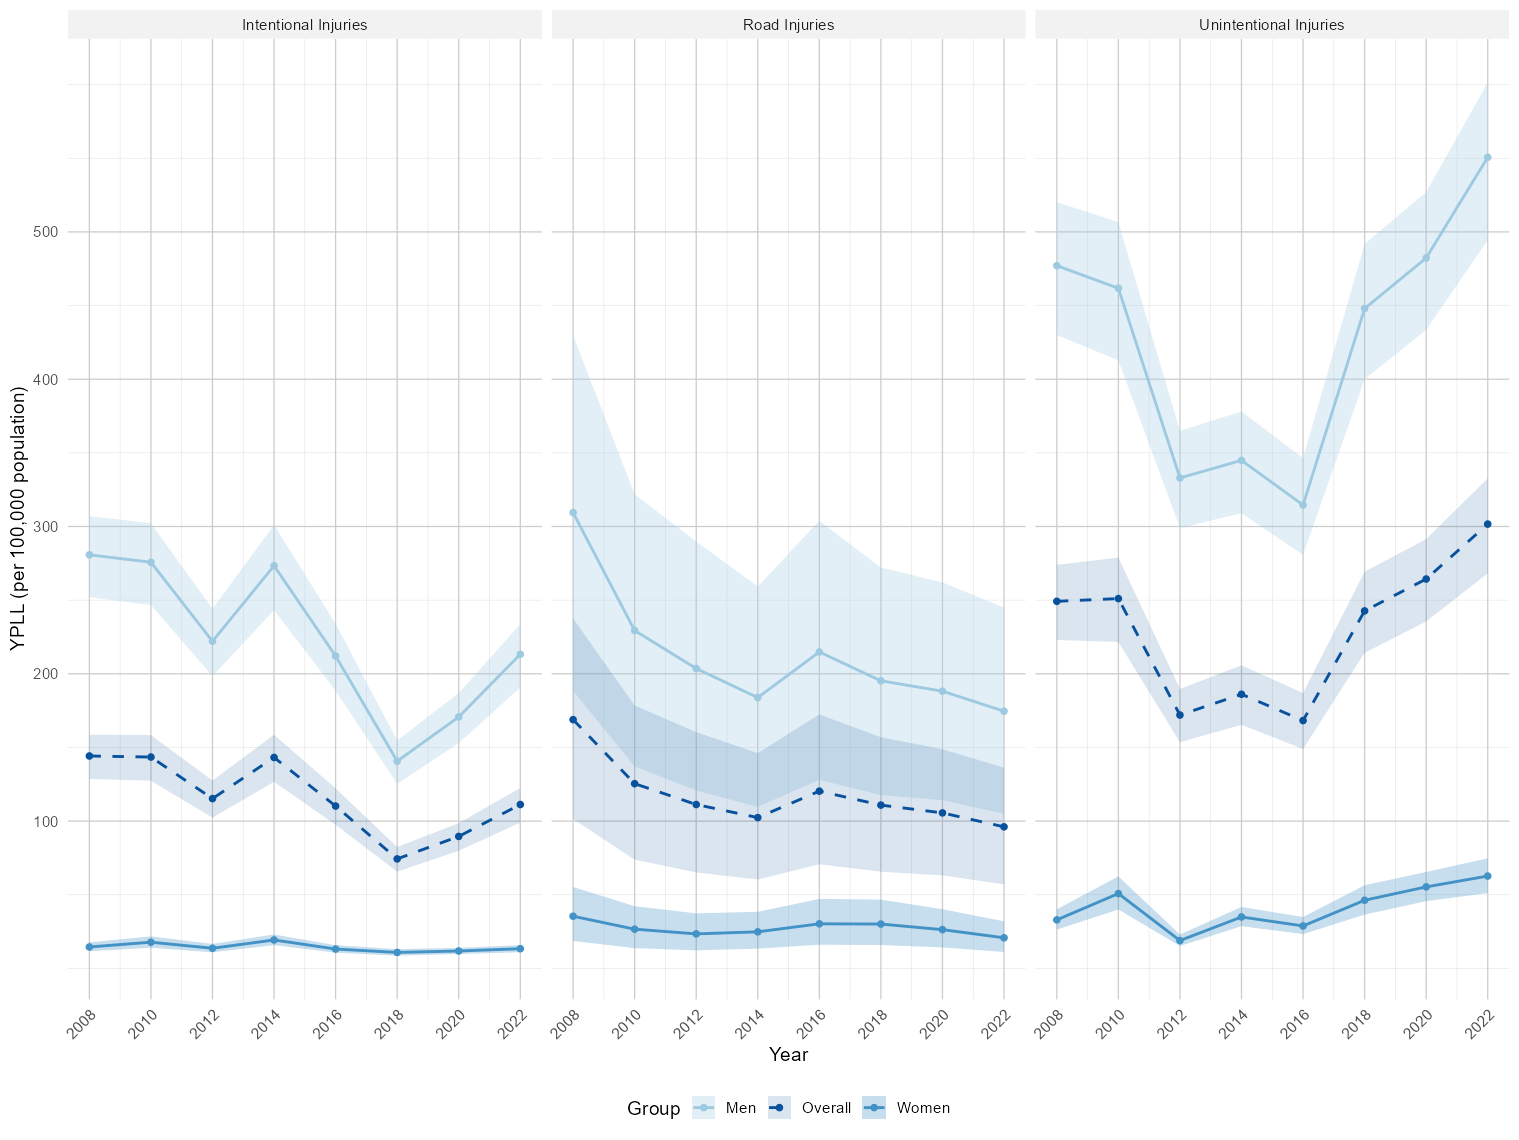

In [368]:
#| label: pot-avoidable-injury-mortality13-ypll-plot
#| results: "hold"

# Paleta Blues: seleccionamos algunos tonos intermedios y oscuros
pal_blues <- RColorBrewer::brewer.pal(9, "Blues")[c(4, 6, 8)]

# Asignamos: Men, Women y Overall
col_vals  <- c("Men" = pal_blues[1],
               "Women" = pal_blues[2],
               "Overall" = pal_blues[3])  # negro para destacar el total

fill_vals <- c("Men" = adjustcolor(pal_blues[1], alpha.f = 0.3),
               "Women" = adjustcolor(pal_blues[2], alpha.f = 0.3),
               "Overall" = adjustcolor(pal_blues[3], alpha.f = 0.15))

ypll_plot <- ggplot(ypll_all, aes(x = year, y = value, group = group)) +
  geom_ribbon(aes(ymin = low, ymax = up, fill = group),
              colour = NA) +
  geom_line(aes(color = group, linetype = group), linewidth = 0.9) +
  geom_point(aes(color = group), size = 1.6) +
  facet_wrap(~disease) +
  scale_color_manual(values = col_vals, name = "Group") +
  scale_fill_manual(values  = fill_vals, name = "Group") +
  scale_linetype_manual(values = c(Men = "solid", Women = "solid", Overall = "dashed"),
                        name = "Group") +
  scale_x_continuous(breaks = scales::pretty_breaks(6)) +
  scale_y_continuous(
    breaks = seq(100, 500, 100),   # â† aquÃ­ defines los cortes
    labels = scales::label_number(accuracy = 1)
  ) +
  labs(
    x = "Year", 
    y = "YPLL (per 100,000 population)"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.placement = "outside",
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text.y.right = element_text(angle = 0, face = "bold"),
    panel.background = element_rect(fill = "white", colour = NA),
    panel.grid.major = element_line(color = "grey80", linewidth = 0.4),
    panel.grid.minor = element_line(color = "grey90", linewidth = 0.2)
  )
print(ypll_plot)

AVOIDABLE YPLL

In [369]:
#| label: pot-avoidable-injury-mortality14-avoid-ypll
#| results: "hold"

pif_ypll <- att %>%
  dplyr::select(year, gender, age_group, disease, ypll_att) %>% 
  left_join(pif, by = c("year", "gender", "age_group", "disease")) %>% 
  mutate(avoid_ypll = ypll_att*pif,
         avoid_ypll_low = ypll_att*pif_low,
         avoid_ypll_up = ypll_att*pif_up)

avoid_ypll_sex <- pif_ypll %>% 
  group_by(year, gender, disease,shift) %>% 
  summarise(
    avoid_ypll     = sum(avoid_ypll,     na.rm = TRUE),
    avoid_ypll_low = sum(avoid_ypll_low, na.rm = TRUE),
    avoid_ypll_up  = sum(avoid_ypll_up,  na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  left_join(pop, by = c("year", "gender")) %>% 
  mutate(
    value = round(avoid_ypll     / pop * 100000),
    low   = round(avoid_ypll_low / pop * 100000),
    up    = round(avoid_ypll_up  / pop * 100000),
    group = as.character(gender)
  ) %>% 
  dplyr::select(year, shift,group, disease,value, low, up)

avoid_ypll_overall <- pif_ypll %>% 
  group_by(year, disease,shift) %>% 
  summarise(
    avoid_ypll     = sum(avoid_ypll,     na.rm = TRUE),
    avoid_ypll_low = sum(avoid_ypll_low, na.rm = TRUE),
    avoid_ypll_up  = sum(avoid_ypll_up,  na.rm = TRUE),
    .groups = "drop"
  ) %>% 
  left_join(pop %>% group_by(year) %>% summarise(pop = sum(pop, na.rm = TRUE), .groups="drop"),
            by = "year") %>% 
  mutate(
    value = round(avoid_ypll     / pop * 100000),
    low   = round(avoid_ypll_low / pop * 100000),
    up    = round(avoid_ypll_up  / pop * 100000),
    group = "Overall"
  ) %>% 
  dplyr::select(year, shift,group, disease, value, low, up)

avoid_ypll <- bind_rows(avoid_ypll_sex, avoid_ypll_overall) %>% 
  arrange(year)

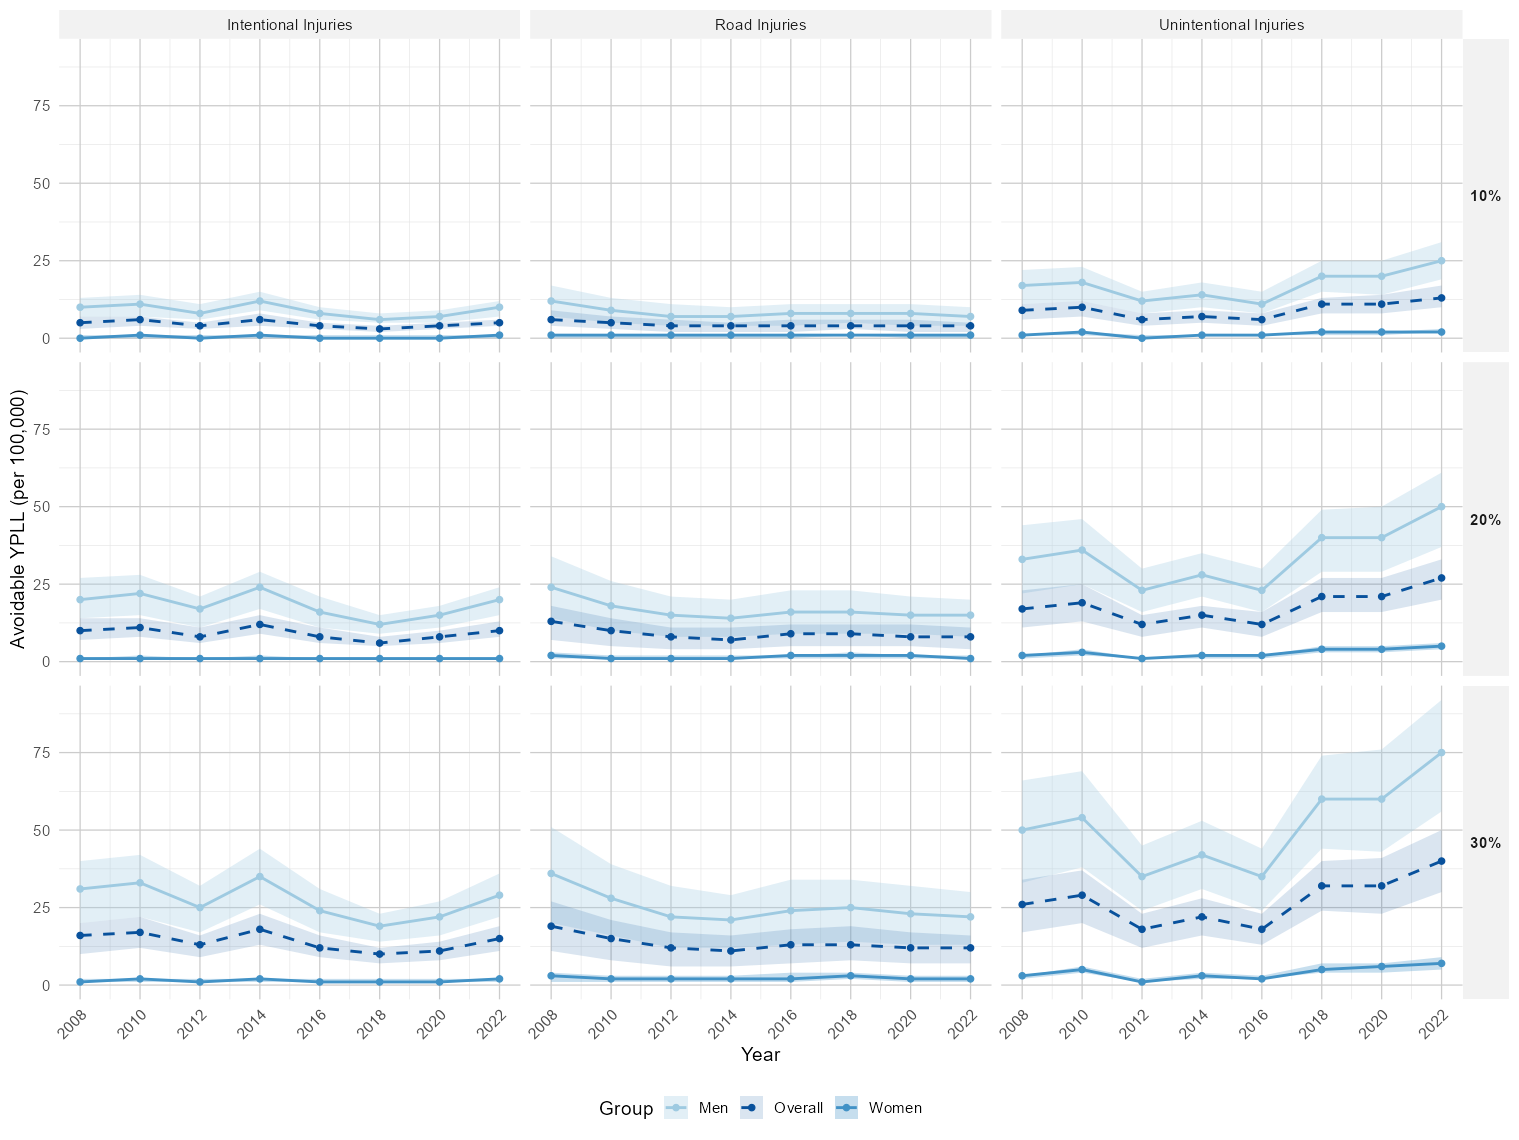

In [370]:
#| label: pot-avoidable-injury-mortality-yp13-avoid-ypll-plot
#| results: "hold"

p_avoid <- ggplot(avoid_ypll, aes(x = year, y = value, group = group)) +
  geom_ribbon(aes(ymin = low, ymax = up, fill = group), colour = NA) +
  geom_line(aes(color = group, linetype = group), linewidth = 0.9) +
  geom_point(aes(color = group), size = 1.6) +
  scale_color_manual(values = col_vals, name = "Group") +
  scale_fill_manual(values  = fill_vals, name = "Group") +
  scale_linetype_manual(values = c(Men = "solid", Women = "solid", Overall = "dashed"),
                        name = "Group") +
  scale_x_continuous(breaks = scales::pretty_breaks(6)) +
  scale_y_continuous(labels = scales::label_number(accuracy = 1)) +
  labs(
    x = "Year",
    y = "Avoidable YPLL (per 100,000)"
  ) +
  facet_grid(rows = vars(shift), cols = vars(disease)) +
  theme_minimal(base_size = 13) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.placement = "outside",
    strip.background = element_rect(fill = "grey95", color = NA),
    strip.text.y.right = element_text(angle = 0, face = "bold"), # â† mueve 10%-20%-30% a la derecha
    panel.background = element_rect(fill = "white", colour = NA),
    panel.grid.major = element_line(color = "grey80", linewidth = 0.4),
    panel.grid.minor = element_line(color = "grey90", linewidth = 0.2)
  )
p_avoid

In [371]:
#| label: pot-avoidable-injury-mortality14-tab2
#| results: "hold"

tab2 <- avoid_ypll %>%
  group_by(year, shift, disease,group) %>%
  summarise(
    value = sum(value, na.rm = TRUE),
    li = median(low),
    ls = median(up),
    .groups = "drop"
  ) %>%
  arrange(shift, group) %>% 
  mutate(valor = paste0(value, "(", li, ",", ls, ")")) %>% 
  dplyr::select(-value, -li, -ls)

tab2 |> 
  dplyr::mutate(group= dplyr::case_when(group=="Men"~ "1Men", group=="Women"~ "2Women", T~ "3Overall")) |>
  dplyr::arrange(year, disease, shift, group) |> 
  dplyr::mutate(group= dplyr::case_when(group=="1Men"~ "Men", group=="2Women"~ "Women", T~ "Overall")) |>
  pivot_wider(
    id_cols     = c(year, disease),
    names_from  = c(shift, group),
    values_from = valor
  ) |> 
  knitr::kable("markdown")



| year|disease                |10%_Men   |10%_Women |10%_Overall |20%_Men   |20%_Women |20%_Overall |30%_Men   |30%_Women |30%_Overall |
|----:|:----------------------|:---------|:---------|:-----------|:---------|:---------|:-----------|:---------|:---------|:-----------|
| 2008|Intentional Injuries   |10(7,13)  |0(0,1)    |5(3,7)      |20(14,27) |1(1,1)    |10(7,14)    |31(20,40) |1(1,2)    |16(10,20)   |
| 2008|Road Injuries          |12(7,17)  |1(0,1)    |6(4,9)      |24(14,34) |2(1,3)    |13(7,18)    |36(20,51) |3(1,4)    |19(11,27)   |
| 2008|Unintentional Injuries |17(11,22) |1(1,1)    |9(6,11)     |33(22,44) |2(1,2)    |17(11,23)   |50(33,66) |3(2,3)    |26(17,34)   |
| 2010|Intentional Injuries   |11(7,14)  |1(0,1)    |6(4,7)      |22(15,28) |1(1,2)    |11(8,14)    |33(22,42) |2(1,2)    |17(12,22)   |
| 2010|Road Injuries          |9(5,13)   |1(0,1)    |5(3,7)      |18(10,26) |1(1,2)    |10(5,14)    |28(16,39) |2(1,3)    |15(8,21)    |
| 2010|Unintentional Injuries |18(12,23

In [372]:
#| label: pot-avoidable-injury-mortality15-tab-s3
#| results: "hold"

tabs3 <- avoid_ypll %>%
  group_by(year, shift, group) %>%
  summarise(
    value = sum(value, na.rm = TRUE),
    li = sum(low, na.rm = TRUE),
    ls = sum(up, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(shift, group) %>% 
  mutate(valor = paste0(value, "(", li, ",", ls, ")")) %>% 
  dplyr::select(-value, -li, -ls)

tabs3 |> 
  dplyr::mutate(group= dplyr::case_when(group=="Men"~ "1Men", group=="Women"~ "2Women", T~ "3Overall")) |>
  dplyr::arrange(year, shift, group) |> 
  dplyr::mutate(group= dplyr::case_when(group=="1Men"~ "Men", group=="2Women"~ "Women", T~ "Overall")) |>
  pivot_wider(
    id_cols     = c(year),
    names_from  = c(shift, group),
    values_from = valor
  ) |> 
  knitr::kable("markdown")



| year|10%_Men   |10%_Women |10%_Overall |20%_Men    |20%_Women |20%_Overall |30%_Men     |30%_Women |30%_Overall |
|----:|:---------|:---------|:-----------|:----------|:---------|:-----------|:-----------|:---------|:-----------|
| 2008|39(25,52) |2(1,3)    |20(13,27)   |77(50,105) |5(3,6)    |40(25,55)   |117(73,157) |7(4,9)    |61(38,81)   |
| 2010|38(24,50) |4(1,4)    |21(14,26)   |76(50,100) |5(4,8)    |40(26,53)   |115(76,150) |9(6,11)   |61(40,80)   |
| 2012|27(18,37) |1(0,3)    |14(9,19)    |55(35,72)  |3(3,4)    |28(18,37)   |82(53,109)  |4(3,7)    |43(27,56)   |
| 2014|33(23,43) |3(1,3)    |17(11,22)   |66(46,84)  |4(3,6)    |34(24,44)   |98(69,126)  |7(4,9)    |51(35,67)   |
| 2016|27(18,36) |2(1,3)    |14(9,19)    |55(36,74)  |5(3,5)    |29(19,39)   |83(54,109)  |5(4,9)    |43(29,57)   |
| 2018|34(25,44) |3(2,4)    |18(13,23)   |68(47,87)  |7(5,9)    |36(26,47)   |104(72,131) |9(7,13)   |55(39,71)   |
| 2020|35(23,45) |3(1,4)    |19(13,25)   |70(49,89)  |7(5,8)    |37(27

## Mortality TRENDS IN CHILE

Took the aggregated Chilean population survey (`data_input`) and by year, sex and age group, get the proportion of heavy episode drinking. Many from Shield et al 2020 [@shield2020supplement].

In [373]:
#| label: mort-trends-age-sex-chile1-survey
#| results: "hold"

rm(list = setdiff(ls(), "data_input"))
gc()

input <- data_input %>% 
  filter(!is.na(cvolaj)) %>% 
  group_by(sexo,year, edad_tramo, cvolaj) %>% 
  summarise(weighted_count = sum(exp, na.rm = TRUE)) %>% 
  mutate(prop = round(weighted_count / sum(weighted_count), 2)) %>% 
  dplyr::select(-weighted_count)

data_hed <- data_input %>% 
  filter(!is.na(hed)) %>% 
  group_by(year, sexo, edad_tramo) %>% 
  count(hed) %>% 
  mutate(prop_hed = n/sum(n))

input_male <- input %>% 
  filter(sexo == "Hombre")
input_female <- input %>% 
  filter(sexo == "Mujer")


`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by sexo, year, edad_tramo, and cvolaj.
ℹ Output is grouped by sexo, year, and edad_tramo.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(sexo, year, edad_tramo, cvolaj))` for ]8;;x-r-help:dplyr::dplyr_byper-operation grouping]8;; instead.


In [374]:
#| label: mort-trends-age-sex-chile1b-survey
#| results: "hold"
data_hed

# A tibble: 128 × 6
# Groups:   year, sexo, edad_tramo [64]
    year sexo   edad_tramo   hed     n prop_hed
   <dbl> <fct>       <dbl> <dbl> <int>    <dbl>
 1  2008 Hombre          1     0  1553   0.736 
 2  2008 Hombre          1     1   557   0.264 
 3  2008 Hombre          2     0  1641   0.748 
 4  2008 Hombre          2     1   553   0.252 
 5  2008 Hombre          3     0  1429   0.809 
 6  2008 Hombre          3     1   338   0.191 
 7  2008 Hombre          4     0   516   0.856 
 8  2008 Hombre          4     1    87   0.144 
 9  2008 Mujer           1     0  2089   0.900 
10  2008 Mujer           1     1   231   0.0996
# ℹ 118 more rows
# ℹ Use `print(n = ...)` to see more rows

In [375]:
#| label: mort-trends-age-sex-chile1c-survey
#| results: "hold"
input_male

# A tibble: 192 × 5
# Groups:   sexo, year, edad_tramo [32]
   sexo    year edad_tramo cvolaj  prop
   <fct>  <dbl>      <dbl> <chr>  <dbl>
 1 Hombre  2008          1 cat1    0.46
 2 Hombre  2008          1 cat2    0.08
 3 Hombre  2008          1 cat3    0.08
 4 Hombre  2008          1 cat4    0.05
 5 Hombre  2008          1 fd      0.17
 6 Hombre  2008          1 ltabs   0.16
 7 Hombre  2008          2 cat1    0.57
 8 Hombre  2008          2 cat2    0.07
 9 Hombre  2008          2 cat3    0.08
10 Hombre  2008          2 cat4    0.04
# ℹ 182 more rows
# ℹ Use `print(n = ...)` to see more rows

They generated a function for the normalized gamma density of current drinkers.

`confint_paf`: It computes the 95% confidence interval for the PAF via Monte Carlo simulation by jointly propagating uncertainty from the fitted gamma distribution, a single relative-risk coefficient, and population proportions through 10,000 iterations of the trapezoidal PAF calculator.

`confint_paf_vcov`: It does the same as `confint_paf`, but simulates multiple correlated relative-risk coefficients simultaneously from their full variance-covariance matrix using a multivariate normal distribution, preserving the correlation structure between parameters.

Kimi: Imagine the gamma distribution as a secret recipe with two ingredients:  
- **Shape**: how “pointy” the curve is.  
- **Rate**: how quickly it flattens out to the right.  

You don’t know the exact recipe, but after tasting the dish you know two things:  
- The average flavor = the mean.  
- How different the flavors are between dishes = the standard deviation.  

The **method of moments** is like a calculator that gives you back the recipe (shape and rate) using just those two numbers.  


In [376]:
#| label: mort-trends-age-sex-chile2-gamma-dist-function
#| results: "hold"

# Function to fit gamma distribution
# Define the x_vals range (adjust as needed)
x_vals <- seq(0.1, 150, length.out = 1500)
if (!exists("x_vals_nhed", inherits = TRUE) || length(x_vals_nhed) < 2L) {
  x_vals_nhed <- x_vals
}
if (!exists("x_vals_hed", inherits = TRUE) || length(x_vals_hed) < 2L) {
  x_vals_hed <- x_vals
}

# TRAPEZOIDAL INTEGRATION FUNCTION
trap_int <- function(x, y, rr, prop_abs, rr_form, prop_form) {
  # Interval width
  dx <- x[2] - x[1]
  # Y es la densidad de la gamma cruda, pero el Ã¡rea debajo no suma 1 (porque `dgamma` devuelve densidades)
  # dependientes de shape/scale, pero la discretizaciÃ³n en el intervalo no garantiza que sumen 1
  # Calcula el Ã¡rea ajo la curva usando trapezoidal rule (contando los cuadraditos debejo de la curva) para saber cuÃ¡nto mide
  ncgamma <- sum(y[-1] + y[-length(x)]) * dx / 2
  # Normalize the gamma function
  # Al dividir y/ncgamma tengo un AUC que suma 1
  # Vemos el patrÃ³n de consumo de los que consumen
  # Pero para el PAF, necesito reflejar toda la poblaciÃ³n
  # Por tanto, pondero por la proporciÃ³n de consumidores (restando abstemios y former drinkers)
  # "CuÃ¡nta gente consume cada cantidad de alcohol" (densidad poblacional)
  normalized_y <- (1 -  (prop_abs+prop_form)) * y/ncgamma
  # Cualquier excedente de 1 (nulo) es un exceso de riesgo
  # Calculate the excess relative risk
  excess_rr <- rr - 1
  # Ponderamos el exceso de riesgo por la cantidad de gente que consume cada cantidad de alcohol
  # Calculate the weighted excess relative risk
  # Por tanto, tenemos "cuÃ¡nto riesgo extra aporta este nivel de consumo, ponderado por cuÃ¡nta gente lo consume" 
  weighted_excess_rr <- normalized_y * excess_rr
  # Apply the trapezoidal rule to calculate the numerator
    # ContribuciÃ³n de ex-bebedores
  numerator <- (rr_form-1)*prop_form + # riesgo extra former drinkers. si rr_form=1, no aportan
    sum((weighted_excess_rr[-1] + weighted_excess_rr[-length(x)]) / 2) * dx #  âˆ« normalized_y(x) Ã— (RR(x) - 1) dx, riesgo consumidores actuales, integrando por todos los niveles de consumo
    #La integral pondera el exces risk de c/nivel consumo por la prop que consume en ese nivel, sumamos todo para tener el riesgo atribuible total
  # Calculate the denominator
  # mÃ¡s riesgo base (RR=1, si nadie consumiera)
  denominator <- numerator + 1
  # Calculate PAF
  paf <- round(numerator / denominator, 3)
  return(paf)
}

# LINEAR RELATIVE RISK FUNCTION
rr_linear <- function(x, b){
  exp(x*b)
}

# Recibe la fx gamma ajustada, el coeficiente beta, varianza, proporciones abstemios y former drinkers, RR former y funciÃ³n de RR (lineal)
# Esto refleja que:
# - La distribuciÃ³n gamma del consumo tiene incertidumbre
# - El coeficiente de riesgo relativo tiene incertidumbre
# - Las proporciones de abstinentes/ex-bebedores tienen incertidumbre
# La simulaciÃ³n "mezcla" todas estas incertidumbres y te dice quÃ© tan estable es tu resultado.
confint_paf <- function(gamma, beta, var_beta, p_abs, rr_form, p_form, rr_function){
  set.seed(145)
  # 10.000 simulaciones
  n_sim <- 10000
  simulated_pafs <- numeric(n_sim)
  for (i in 1:n_sim) {
    # Simula 1.000 consumos de alcohol usando parÃ¡metros de consumo gamma sacados de ENPG
    pca_sim <- rgamma(1000, shape = gamma$estimate["shape"], rate = gamma$estimate["rate"])
    # Calcula el promedio y la desviaciÃ³n simuladas (method of moments MOM), 
    # genera una ditribuciÃ³n gmama ligeramente distinta, reflejando la incertidumbre sobre
    # los parÃ¡metros
    # Calculate the shape and rate parameters from the simulated PCA values
    mean_sim <- mean(pca_sim)
    sd_sim <- sd(pca_sim)
    
    # Calculate shape and rate for the new gamma distribution
    # >=0 flexible, permite colas largas de altos consumos
    # Media = Î± / Î² ; Varianza = Î± / Î²Â²
    # Shape (Î± o k )= nÃºmero de eventos, = 1= distribuciÃ³n exponencial; >1, suaviza cola
    shape_sim <- (mean_sim / sd_sim)^2
    # Rate Î» \lambda (1/Î² o 1/Î¸)= tasa, rapidez con que decrece; grande= eventos mÃ¡s rÃ¡pidos, concentra; pequeÃ±o= mÃ¡s lento, dispersa distribuciÃ³n
    rate_sim <- mean_sim / (sd_sim^2)
    # Espero $\alpha$ eventos, pero obtengo $\beta$ en un tiempo; 

    # Â¿Otra forma de calcularlo? (10.1186/1471-2458-11-265)
    #The Îº parameter of the gamma distribution was generated in accordance with Rehm and colleagues [10], 
    # while the Î¸ parameter was calculated by dividing the generated up-shifted mean daily alcohol consumption by the generated Îº parameter.
    
    # Genera la curva gamma en xvals (0.1 a 150) con los nuevos parÃ¡metros simulados shape y rate
    # Simulate the gamma distribution based on `k_sim` and `theta_sim`
    y_gamma_sim <- dgamma(x_vals, shape = shape_sim, rate = rate_sim)
    
    # Si la curva sale mal (valores NaN), para a la siguiente simulaciÃ³n
    # Skip iteration if y_gamma_sim contains NaN values
    if (any(is.nan(y_gamma_sim))) next
    
    # Simulate beta coefficient
    beta_sim <- rnorm(1, beta, sqrt(var_beta))
    rr_sim <- rr_function(x_vals, beta_sim)
    # Simulate proportions of lifetime abstainers and former drinkers for the current age category
    prop_abs_sim <- max(rnorm(1, mean = p_abs, sd = sqrt(p_abs * (1 - p_abs) / 1000)),0.001)
    prop_form_sim <- max(rnorm(1, mean = p_form, sd = sqrt(p_form * (1 - p_form) / 1000)), 0.001)
    # Con la funciÃ³n trapezoidal y usando todos los valores simulados, calcula el PAF
    # Calculate the PAF using the trapezoidal method
    simulated_pafs[i] <- trap_int(x = x_vals, y = y_gamma_sim, rr = rr_sim, 
                                  prop_abs = prop_abs_sim, rr_form = rr_form, prop_form = prop_form_sim)
  }
  
  # Remove NaN values from simulated PAFs
  simulated_pafs <- simulated_pafs[!is.nan(simulated_pafs)]
  
  # Calculate the 95% confidence interval
  paf_lower <- quantile(simulated_pafs, 0.025)
  paf_upper <- quantile(simulated_pafs, 0.975)
  paf_point_estimate <- mean(simulated_pafs)
  
  return(list(
    Point_Estimate = round(paf_point_estimate,3),
    Lower_CI = paf_lower,
    Upper_CI = paf_upper)
  )
}

#Esta funciÃ³n hace exactamente lo mismo, pero cuando tu modelo 
# de riesgo relativo tiene dos o mÃ¡s betas 
# correlacionados (por ejemplo, una pendiente y un intercepto para HED). 
# Usa la matriz de covarianza completa.
# simula varios betas simultÃ¡neamente con una normal multivariada que conserva su estructura de correlaciÃ³n.
confint_paf_vcov <- function(gamma, betas, cov_matrix, p_abs, p_form, rr_fd, rr_function) {
  set.seed(145)
  n_sim <- 10000
  simulated_pafs <- numeric(n_sim)
  
  for (i in 1:n_sim) {
    # Simula 1000 personas al azar para ver cuÃ¡nto beberÃ­an segÃºn nuestra disrtibuciÃ³n
    # Calcula el promedio y desviaciÃ³n, introduciend incertidumbre a la gamma
    # Simulate PCA mean and SD using the gamma distribution
    pca_sim <- rgamma(1000, shape = gamma$estimate["shape"], rate = gamma$estimate["rate"])
    
    # Calculate the shape and rate parameters from the simulated PCA values
    mean_sim <- mean(pca_sim)
    sd_sim <- sd(pca_sim)
    
    # Calculate shape and rate for the new gamma distribution
    # >=0 flexible, permite colas largas de altos consumos
    # Media = Î± / Î² ; Varianza = Î± / Î²Â²
    # Shape (Î± o k )= nÃºmero de eventos, = 1= distribuciÃ³n exponencial; >1, suaviza cola
    shape_sim <- (mean_sim / sd_sim)^2
    # Rate Î» \lambda (1/Î² o 1/Î¸)= tasa, rapidez con que decrece; grande= eventos mÃ¡s rÃ¡pidos, concentra; pequeÃ±o= mÃ¡s lento, dispersa distribuciÃ³n
    rate_sim <- mean_sim / (sd_sim^2)
    # Espero $\alpha$ eventos, pero obtengo $\beta$ en un tiempo; 

    # Genera la curva gamma en xvals (0.1 a 150) con los nuevos parÃ¡metros simulados shape y rate
    # Simulate the gamma distribution based on `k_sim` and `theta_sim`
    y_gamma_sim <- dgamma(x_vals, shape = shape_sim, rate = rate_sim)
    
    # Si la curva sale mal (valores NaN), para a la siguiente simulaciÃ³n
    # Skip iteration if y_gamma_sim contains NaN values
    if (any(is.nan(y_gamma_sim))) next
    
    # En vez de simular cada beta por separado, usa mvnorm, que respeta la covarianza
    # Simulate the beta coefficients jointly from a multivariate normal distribution
    # mvrnorm usa la matriz VCov de los coeficientes estimados. Esa matriz codifica la covarianza entre los betas, 
    # y por tanto respeta la correlaciÃ³n (covarianza estandarizada) entre los parÃ¡metros de manera implÃ­cita. 
    # No es la matriz de covarianza de los errores/residuales del modelo.
    beta_sim <- MASS::mvrnorm(1, mu = betas, Sigma = cov_matrix)
    
    rr_sim <- rr_function(x_vals, beta_sim)
    
    # Simula las proporciones de abstinentes y former, las que tambiÃ©n tienen incertidumbre, 
    # como si fueran proporcines de una encuesta con 1.000 personas. Evita que valores sean negativos (min= 0.001)
    # Simulate proportions of lifetime abstainers and former drinkers
    prop_abs_sim <- max(rnorm(1, mean = p_abs, sd = sqrt(p_abs * (1 - p_abs) / 1000)), 0.001)
    prop_form_sim <- max(rnorm(1, mean = p_form, sd = sqrt(p_form * (1 - p_form) / 1000)), 0.001)
    
    # Calculate the PAF using the trapezoidal method
    simulated_pafs[i] <- trap_int(x = x_vals, y = y_gamma_sim, rr = rr_sim, 
                                  prop_abs = prop_abs_sim, rr_form = rr_fd, prop_form = prop_form_sim)
  }
  
  # Remove NaN values from simulated PAFs
  # Elimina los PAF que no resultaron
  simulated_pafs <- simulated_pafs[!is.nan(simulated_pafs)]
  
  # Devuelve el promedio y percentiles 2.5 y 97.5
  # Calculate the 95% confidence interval
  paf_lower <- quantile(simulated_pafs, 0.025)
  paf_upper <- quantile(simulated_pafs, 0.975)
  paf_point_estimate <- mean(simulated_pafs)
  
  return(list(point_estimate = paf_point_estimate, lower_ci = paf_lower, upper_ci = paf_upper))
}

# Both functions are stored in their paralleized version here:
source(paste0(getwd(),"/confint_paf_parallel.R"))


In the article, they state that *former drinkers* were those who consumed alcohol in the previous year but not in the previous month, while *current drinkers* were individuals whose average daily alcohol consumption ranged between >0 and 150 g. For ischemic stroke, ischemic heart disease, and injuries, we included the prevalence of current drinkers separately for HED and NHED ($P_{NHED}$).

$$
P_{CD}(RR - 1) = \int_{>0}^{60} P_{NHED}(x) \cdot RR_{NHED}(x) \, dx \;+\; \int_{>0}^{60} P_{HED}(x) \cdot RR_{HED}(x) \, dx \;+\; \int_{60}^{150} P_{HED}(x) \cdot RR_{HED}(x) \, dx
$$

According to Kimi, $x_{60}$ is used for NHED because the gamma distribution of non-binge drinkers is concentrated between 0.1 and 60 g/day; beyond that range there is no relevant probability mass, so integrating up to 150 g would mean computing hundreds of unnecessary points. Severe HED cases, however, require the long tail. Non-HED drinkers do not consume at such high levels, so it makes no sense to extend the integration beyond 60 g — there is simply no one there.

In [377]:
#| label: mort-trends-age-sex-chile3-gamma-dist-function2
#| results: "hold"

# FOR ISCHAEMIC STROKE AND INJURIES WE NEED THE PROPORTION OF CURRENT DRINKERS WHO
# ENGAGE IN HEAVY EPISODIC DRINKING NHED and HED
# En lesiones e isquemia, el consumo de los HED no se modela igual que el de los nHED. 
# Probablemente los HED tienen una distribuciÃ³n gamma diferente y un riesgo relativo diferente. 
# Por eso esta funciÃ³n recibe tres curvas gamma y tres curvas de riesgo:

paf_hed_function <- function(x_60,x_150, y_nhed, y_hed_60, 
                             y_hed_150, rr_nhed, rr_hed_60,
                             rr_hed_150, rr_form,p_abs, 
                             p_form, p_hed) {
  # Inner trapezoidal integrator for one drinking segment (nHED or HED)
  trap_int_hed <- function(x, y, rr, prop_abs, rr_form, prop_form, p_hed) {
    # Step size of the consumption grid //Interval width
    dx <- x[2] - x[1]
    # Y es la densidad de la gamma cruda, pero el Ã¡rea debajo no suma 1 (porque `dgamma` devuelve densidades)
    # dependientes de shape/scale, pero la discretizaciÃ³n en el intervalo no garantiza que sumen 1
    # Calcula el Ã¡rea bajo la curva usando trapezoidal rule (contando los cuadraditos debejo de la curva) para saber cuÃ¡nto mide
    ncgamma <- sum((y[-1] + y[-length(y)]) / 2) * dx
        # Scale density to this subgroup's share in the total population
    # (1 - prop_abs - prop_form) = current drinkers; p_hed = weight of this segment
    #  curvas gamma escaladas a la proporciÃ³n de cada subgrupo en la poblaciÃ³n.
    normalized_y <- ((1 - (prop_abs + prop_form)) * p_hed) * y / ncgamma # por eso el * p_hed aÃ±adido a la porporciÃ³n de consumidores actuales
    # Risk in excess of the abstainer baseline (RR = 1)
    excess_rr <- rr - 1
    # Weight the excess risk by how many people drink at each level
    weighted_excess_rr <- normalized_y * excess_rr
    # Integrate weighted excess risk over all consumption levels
    # and add the contribution of former drinkers 
     # riesgo extra former drinkers. si rr_form=1, no aportan
    numerator <- (rr_form - 1) * prop_form + sum((weighted_excess_rr[-1] + weighted_excess_rr[-length(weighted_excess_rr)]) / 2) * dx #  âˆ« normalized_y(x) Ã— (RR(x) - 1) dx, riesgo consumidores actuales, integrando por todos los niveles de consumo
    # #La integral pondera el exces risk de c/nivel consumo por la prop que consume en ese nivel, sumamos todo para tener el riesgo atribuible total
    # Total population risk = attributable risk + baseline risk of 1
    denominator <- numerator + 1
    # Population Attributable Fraction for this segment
    paf <- round(numerator / denominator, 3)
    
    return(paf)
  }

  # Sumamos las tres integrales (nHED + HED_1 + HED_2)
  int_ri_nhed <- trap_int_hed(
    x = x_60, #y_hed_60 describe la "mitad baja" del consumo HED (0-60g)
    y = y_nhed, # Curva gamma de los NHED
    rr = rr_nhed, # Riesgo relativo de NHED
    prop_abs = p_abs, 
    rr_form = rr_form, 
    prop_form = p_form, 
    p_hed = 1 - p_hed #ProporciÃ³n NHED
  ) #((1 - p_abs - p_form) * (1 - p_hed)) * y / ncgamma # proporciÃ³n de NHED en la poblaciÃ³n total
  
  int_ri_hed1 <- trap_int_hed(
    x = x_60, #y_hed_60 describe la "mitad baja" del consumo HED (0-60g) 
    y = y_hed_60, #Curva gamma de HED (rango 0-60g)
    rr = rr_hed_60, #Riesgo relativo de HED en ese rango
    prop_abs = p_abs, 
    rr_form = rr_form, 
    prop_form = p_form, 
    p_hed = p_hed #Peso: proporciÃ³n de HED total entre consumidores actuales
  )#ProporciÃ³n de HED(0-60) en la poblaciÃ³n total.
  
  int_ri_hed2 <- trap_int_hed(
    x = x_150, #y_hed_150 describe la "mitad alta" del consumo HED (>60-150g)
    y = y_hed_150, 
    rr = rr_hed_150, 
    prop_abs = p_abs, 
    rr_form = rr_form, 
    prop_form = p_form, 
    p_hed = p_hed
  )
  # se integran por separado porque usan diferentes grillas (x_60 vs x_150) y
  # posiblemente diferentes funciones de riesgo relativo (rr_hed_60 vs rr_hed_150).

  #INTERNAMENTE, SE INCLUYE A LOS EX BEBEDORES: cada int_ri_xxx es un PAF parcial que incluye a los ex-bebedores.
  #Pero no importa porque ex-bebedores tienen el mismo riesgo que abstinentes
  #Contribuyen CERO
  num <- (int_ri_nhed + int_ri_hed1 + int_ri_hed2)
  den <- num + 1
  
  paf_ri_fem1 <- num / den
  
  return(paf_ri_fem1)
}  

Esta funciÃ³n calcula el intervalo de confianza del PAF para el modelo completo con nHED + HED, incluyendo todas las fuentes de incertidumbre a la vez. 

In [378]:
#| label: mort-trends-age-sex-chile4-gamma-dist-function-CIs3
#| results: "hold"

#Simula 10,000 escenarios del mundo alternativos, donde en cada uno varÃ­a ligeramente las dos distribuciones gamma (nHED y HED), 
# el coeficiente de riesgo relativo, y las proporciones poblacionales; luego calcula el PAF en cada escenario y resume los 
# 10,000 resultados como un promedio y un intervalo de confianza del 95%.


#Recibe dos gammas (nHED y HED), un beta comÃºn, la varianza del beta, las proporciones poblacionales, y las dos funciones de riesgo relativo.
confint_paf_hed <- function(gammas, beta, cov_matrix, p_abs, p_form, rr_fd, rr_function_nhed,
                            rr_function_hed, p_hed) {
  set.seed(145)
  n_sim <- 10000
  simulated_pafs <- numeric(n_sim)
  
  for (i in 1:n_sim) {
    #Para cada simulaciÃ³n, genera 1,000 consumos ficticios de cada grupo: NHED y HED usando distribuciÃ³n gamma
    # Simulate PCA mean and SD using the gamma distribution
    #"Si la ENPG tuviera 1,000 personas mÃ¡s, Â¿cuÃ¡nto beberÃ­an segÃºn nuestra distribuciÃ³n estimada?"
    pca_sim_nhed <- rgamma(1000, shape = gammas[[1]]$estimate["shape"], 
                           rate = gammas[[1]]$estimate["rate"])
    pca_sim_hed <- rgamma(1000, shape = gammas[[2]]$estimate["shape"], 
                          rate = gammas[[2]]$estimate["rate"])
    
    # Calculate the shape and rate parameters from the simulated PCA values
    #Calcula el promedio y la desviaciÃ³n estÃ¡ndar de esos 1,000 consumos simulados
    mean_sim_nhed <- mean(pca_sim_nhed)
    sd_sim_nhed <- sd(pca_sim_nhed)
    mean_sim_hed <- mean(pca_sim_hed)
    sd_sim_hed <- sd(pca_sim_hed)
    
    shape_sim_nhed <- (mean_sim_nhed / sd_sim_nhed)^2
    rate_sim_nhed <- mean_sim_nhed / (sd_sim_nhed^2)
    shape_sim_hed <- (mean_sim_hed / sd_sim_hed)^2
    rate_sim_hed <- mean_sim_hed / (sd_sim_hed^2)
    
    # Si sabes el promedio y la "dispersiÃ³n" de tus datos, el mÃ©todo de momentos te dice quÃ© parÃ¡metros (shape y rate) debiÃ³ tener 
    # la gamma para producir exactamente ese promedio y esa dispersiÃ³n.
    # Recalcula shape y rate usando esas medias y desviaciones (mÃ©todo de momentos). 
    # Cada simulaciÃ³n produce una gamma ligeramente distinta, reflejando que no conocemos la distribuciÃ³n exacta.
    # El mÃ©todo de momentos es una regla de tres invertida: si sabes cÃ³mo se ven los datos (media y dispersiÃ³n), 
    # te dice quÃ© botones girar (shape y rate) en la gamma para obtener exactamente esos datos.
    y_gamma_sim_nhed <- dgamma(x_vals_nhed, shape = shape_sim_nhed, rate = rate_sim_nhed)
    y_gamma_sim_hed_60 <- dgamma(x_vals_nhed, shape = shape_sim_hed, rate = rate_sim_hed)
    y_gamma_sim_hed_150 <- dgamma(x_vals_hed, shape = shape_sim_hed, rate = rate_sim_hed)
    
    # Simula un beta alternativo de una distribuciÃ³n normal. 
    # Como el beta estimado tiene error estÃ¡ndar, aquÃ­ le das "juego": a veces sale un poco mÃ¡s alto, a veces mÃ¡s bajo.
    # Simulate the beta coefficient from a normal distribution
    # Ojo: aquÃ­ es la varianza de un sÃ³lo beta. Si tuviera varios, usarÃ­amos  `mvnorm`
    beta_sim <- rnorm(1, mean = beta, sd = sqrt(cov_matrix))
    
    # Calcula tres curvas de riesgo relativo: NHED, HED <60 y HED >=60
    # Compute the relative risk based on the simulated beta
    rr_sim_nhed <- rr_function_nhed(x = x_vals_nhed, b = beta_sim) # Adjusted to match definition
    rr_sim_hed_60 <- rr_function_hed(x = x_vals_nhed, beta = beta_sim)
    rr_sim_hed_150 <- rr_function_hed(x = x_vals_hed, beta = beta_sim)
    
    # Simula tres proporciones poblacionales con incertidumbre
    # max evita 0 y negativos
    # Simulate proportions of lifetime abstainers and former drinkers
    # Con n = 1000 y proporciones intermedias, la normal es una buena aproximaciÃ³n y casi nunca se sale de [0,1]
    # Usaron rnorm porque es la aproximaciÃ³n "fÃ¡cil" del error estÃ¡ndar de una proporciÃ³n, pero rbeta o rbinom serÃ­an estadÃ­sticamente mÃ¡s correctas
    prop_abs_sim <- max(rnorm(1, mean = p_abs, sd = sqrt(p_abs * (1 - p_abs) / 1000)), 0.001)
    prop_form_sim <- max(rnorm(1, mean = p_form, sd = sqrt(p_form * (1 - p_form) / 1000)), 0.001)
    prop_hed_sim <- max(rnorm(1, mean = p_hed, sd = sqrt(p_hed * (1 - p_hed) / 1000)), 0.001)
    
    #Con todos los valores simulados (gammas, beta, proporciones), calcula un PAF (10.000 veces)
    # Calculate PAF using the customized function
    simulated_pafs[i] <- paf_hed_function(
      x_60 = x_vals_nhed, 
      x_150 = x_vals_hed, 
      y_nhed = y_gamma_sim_nhed, 
      y_hed_60 = y_gamma_sim_hed_60, 
      y_hed_150 = y_gamma_sim_hed_150, 
      rr_nhed = rr_sim_nhed, 
      rr_hed_60 = rr_sim_hed_60, 
      rr_hed_150 = rr_sim_hed_150,
      rr_form = rr_fd, 
      p_abs = prop_abs_sim, 
      p_form = prop_form_sim, 
      p_hed = prop_hed_sim
    )
  }
  #Resumen final: media percentil 2.5 y 97.5
  simulated_pafs <- simulated_pafs[!is.nan(simulated_pafs)]
  if (length(simulated_pafs) == 0) {
    stop("All simulations resulted in NaN values. Please check your input parameters.")
  }
  
  paf_lower <- quantile(simulated_pafs, 0.025)
  paf_upper <- quantile(simulated_pafs, 0.975)
  paf_point_estimate <- mean(simulated_pafs)
  
  return(list(point_estimate = round(paf_point_estimate, 3), 
              lower_ci = round(paf_lower, 3), 
              upper_ci = round(paf_upper, 3)))
}

# parallelized version is stored in:
source(paste0(getwd(),"/confint_paf_parallel.R"))


They organized the alcohol consumption data by sex, year, and age group for the period 2008 to 2022. First, they extracted the positive values of `volajohdia` for women and men, then fitted gamma distributions by age group and year, both for overall consumption and separately for individuals with and without heavy episodic drinking (`hed` and `nhed`). In addition, they built lists with proportions of abstainers (`ltabs`), former drinkers (`fd`), and prevalence of heavy episodic drinking (`prop_hed`) to be used later in the model calculations.

In [379]:
#| label: mort-trends-age-sex-chile5-creating-list-w-parameters
#| results: "hold"

#---------------------------------#
#------------ 2008 DATA ----------#
#---------------------------------#
cd_fem_list <- list()

# Define the years to process
years <- c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022)

for (year in years) {
  cd_fem_list[[as.character(year)]] <- list()
  
  for (i in 1:4) {  # Iterate over edad_tramo
    cd_fem_list[[as.character(year)]][[i]] <- data_input %>%
      filter(volajohdia > 0, 
             sexo == "Mujer", 
             edad_tramo == i, 
             year == !!year) %>%  # Use the correct value of 'year'
      pull(volajohdia)
  }
}

# numbers represent age group
# 08,10,12,14,16,18,20,22 are years

# Create a list to store gamma fits
g_fem_list <- list()

for (year in names(cd_fem_list)) {
  g_fem_list[[year]] <- lapply(cd_fem_list[[year]], function(data) {
    if (length(data) > 1) {  # Ensure sufficient data to fit
      fitdist(data, "gamma")
    } else {
      NULL  # Handle cases with insufficient data
    }
  })
}

cd_fem_hed_list <- list()

hed_values <- c(0, 1)

# Nested loop to iterate through years, age group, and hed values
for (year in years) {
  cd_fem_hed_list[[as.character(year)]] <- list()
  for (i in 1:4) {
    for (hed_value in hed_values) {
      # Create a descriptive key
      key <- paste0("edad", i, ifelse(hed_value == 0, "_nhed", "_hed"))
      
      # Filter and pull data
      cd_fem_hed_list[[as.character(year)]][[key]] <- data_input %>%
        filter(volajohdia > 0, 
               sexo == "Mujer", 
               edad_tramo == i, 
               hed == !!hed_value, 
               year == !!year) %>%  # Ensure year is correctly interpreted
        pull(volajohdia)
    }
  }
}

# Ensure that gamma fits are organized by "nhed" and "hed"
g_fem_hed_list <- list()

for (year in names(cd_fem_hed_list)) {
  g_fem_hed_list[[year]] <- list()
  
  for (edad_tramo in 1:4) {
    # Extract data for non-heavy drinkers
    nhed_key <- paste0("edad", edad_tramo, "_nhed")
    hed_key <- paste0("edad", edad_tramo, "_hed")
    
    data_nhed_int <- cd_fem_hed_list[[year]][[nhed_key]] #AGS 2026-05-06: cambiamos los nombres del objeto para que no se superponga, aÃ±adiendo sufijo _int
    data_hed_int <- cd_fem_hed_list[[year]][[hed_key]] #AGS 2026-05-06: cambiamos los nombres del objeto para que no se superponga, aÃ±adiendo sufijo _int
    
    # Fit gamma distribution if sufficient data exists
    g_fem_hed_list[[year]][[edad_tramo]] <- list(
      nhed = if (length(data_nhed_int) > 1) fitdist(data_nhed_int, "gamma") else NULL,
      hed = if (length(data_hed_int) > 1) fitdist(data_hed_int, "gamma") else NULL
    )
  }
}

# Filter input_female for rows where cvolaj is "ltabs"
ltabs_fem <- input_female %>%
  filter(cvolaj == "ltabs") %>%
  arrange(year, edad_tramo)

# Create the list for ltabs values by year and age group
p_abs_list_fem <- ltabs_fem %>%
  group_by(year, edad_tramo) %>%
  summarise(prop = list(prop), .groups = "drop") %>%
  split(.$year) %>%
  lapply(function(df) {
    setNames(df$prop, paste0("edad_tramo_", df$edad_tramo))
  })

# Filter input_female for rows where cvolaj is "fd"
fd_fem <- input_female %>%
  filter(cvolaj == "fd") %>%
  arrange(year, edad_tramo)

# Create the list for fd values by year and age group
p_form_list_fem <- fd_fem %>%
  group_by(year, edad_tramo) %>%
  summarise(prop = list(prop), .groups = "drop") %>%
  split(.$year) %>%
  lapply(function(df) {
    setNames(df$prop, paste0("edad_tramo_", df$edad_tramo))
  })

# Filter data for males
# AGS 2026-05-29 (fix asistido por Claude, validado con Codex): p_hed ponderado.
# Antes p_hed salia de data_hed (count(hed) sobre TODA la muestra con hed no-NA, sin
# ponderar por exp), pero el PAF binge espera la fraccion HED ENTRE bebedores actuales.
# Se recomputa desde data_input (unico objeto que sobrevive al rm() de la celda survey):
# volajohdia>0, ponderado por exp, HED/(HED+NHED) por year x edad_tramo, grilla completa.
# Misma logica que build_s_hed_list_weighted (CELL 25, paper injuries/YPLL).
p_hed_list_fem <- data_input %>%
  filter(volajohdia > 0, sexo == "Mujer", year %in% years, edad_tramo %in% 1:4, hed %in% c(0, 1)) %>%
  group_by(year, edad_tramo, hed) %>%
  summarise(w = sum(exp, na.rm = TRUE), .groups = "drop") %>%
  tidyr::complete(year = years, edad_tramo = 1:4, hed = 0:1, fill = list(w = 0)) %>%
  group_by(year, edad_tramo) %>%
  summarise(prop_hed = ifelse(sum(w) > 0, sum(w[hed == 1]) / sum(w), NA_real_), .groups = "drop") %>%
  arrange(edad_tramo, match(year, years)) %>%
  group_by(edad_tramo) %>%
  summarise(prop_hed_values = list(prop_hed), .groups = "drop") %>%
  pull(prop_hed_values)


#------------------------------#
#------------MALES-------------#
#------------------------------#

# Create an empty list to store results by year for males
cd_male_list <- list()

# Loop over each year and age group for males
for (year in years) {
  cd_male_list[[as.character(year)]] <- list()
  for (i in 1:4) {
    cd_male_list[[as.character(year)]][[i]] <- data_input %>%
      filter(volajohdia > 0, sexo == "Hombre", edad_tramo == i, 
             year == !!year) %>%
      pull(volajohdia)
  }
}

# Create a list to store gamma fits for males
g_male_list <- list()

# Loop through each year and fit gamma distributions for each edad_tramo
for (year in names(cd_male_list)) {
  g_male_list[[year]] <- lapply(cd_male_list[[year]], function(data) {
    if (length(data) > 1) { # Ensure there is enough data to fit a distribution
      fitdist(data, "gamma")
    } else {
      NULL # Handle cases with insufficient data
    }
  })
}

# PCA of hed and nhed males
cd_male_hed_list <- list()

# Nested loop to iterate through years, age group, and hed values for males
for (year in years) {
  cd_male_hed_list[[as.character(year)]] <- list()
  for (i in 1:4) {
    for (hed_value in hed_values) {
      # Create a descriptive key
      key <- paste0("edad", i, ifelse(hed_value == 0, "_nhed", "_hed"))
      
      # Filter and pull data
      cd_male_hed_list[[as.character(year)]][[key]] <- data_input %>%
        filter(volajohdia > 0, sexo == "Hombre", edad_tramo == i, hed == !!hed_value, year == !!year) %>%
        pull(volajohdia)
    }
  }
}

cd_male_hed_list <- list()

# Nested loop to iterate through years, age group, and hed values for males
for (year in years) {
  cd_male_hed_list[[as.character(year)]] <- list()
  for (i in 1:4) {
    for (hed_value in hed_values) {
      # Create a descriptive key
      key <- paste0("edad", i, ifelse(hed_value == 0, "_nhed", "_hed"))
      
      # Filter and pull data
      cd_male_hed_list[[as.character(year)]][[key]] <- data_input %>%
        filter(volajohdia > 0, sexo == "Hombre", edad_tramo == i, hed == !!hed_value, year == !!year) %>%
        pull(volajohdia)
    }
  }
}

# Create a list to store gamma fits for hed and nhed for males
g_male_hed_list <- list()

# Loop through each year in cd_male_hed_list
for (year in names(cd_male_hed_list)) {
  g_male_hed_list[[year]] <- list()
  
  # Loop through each edad_tramo and hed value
  for (key in names(cd_male_hed_list[[year]])) {
    data <- cd_male_hed_list[[year]][[key]]
    
    # Fit gamma distribution only if there is enough data
    g_male_hed_list[[year]][[key]] <- if (length(data) > 1) {
      fitdist(data, "gamma")
    } else {
      NULL # Handle cases with insufficient data
    }
  }
}

g_male_hed_list <- list()

for (year in names(cd_male_hed_list)) {
  g_male_hed_list[[year]] <- list()
  
  for (edad_tramo in 1:4) {
    # Extract data for non-heavy drinkers
    nhed_key <- paste0("edad", edad_tramo, "_nhed")
    hed_key <- paste0("edad", edad_tramo, "_hed")
    
    data_nhed_int <- cd_male_hed_list[[year]][[nhed_key]] #AGS 2026-05-06: cambiamos los nombres del objeto para que no se superponga, aÃ±adiendo sufijo _int
    data_hed_int <- cd_male_hed_list[[year]][[hed_key]] #AGS 2026-05-06: cambiamos los nombres del objeto para que no se superponga, aÃ±adiendo sufijo _int
    
    # Fit gamma distribution if sufficient data exists
    g_male_hed_list[[year]][[edad_tramo]] <- list(
      nhed = if (length(data_nhed_int) > 1) fitdist(data_nhed_int, "gamma") else NULL,
      hed = if (length(data_hed_int) > 1) fitdist(data_hed_int, "gamma") else NULL
    )
  }
}
# Filter input_female for rows where cvolaj is "ltabs"
ltabs_male <- input_male %>%
  filter(cvolaj == "ltabs") %>%
  arrange(year, edad_tramo)

# Create the list for ltabs values by year and age group
p_abs_list_male <- ltabs_male %>%
  group_by(year, edad_tramo) %>%
  summarise(prop = list(prop), .groups = "drop") %>%
  split(.$year) %>%
  lapply(function(df) {
    setNames(df$prop, paste0("edad_tramo_", df$edad_tramo))
  })

# Filter input_female for rows where cvolaj is "fd"
fd_male <- input_male %>%
  filter(cvolaj == "fd") %>%
  arrange(year, edad_tramo)

# Create the list for fd values by year and age group
p_form_list_male <- fd_male %>%
  group_by(year, edad_tramo) %>%
  summarise(prop = list(prop), .groups = "drop") %>%
  split(.$year) %>%
  lapply(function(df) {
    setNames(df$prop, paste0("edad_tramo_", df$edad_tramo))
  })

# Filter data for males
# AGS 2026-05-29 (fix asistido por Claude, validado con Codex): idem mujeres - p_hed
# ponderado entre bebedores actuales (volajohdia>0), HED/(HED+NHED) por year x edad_tramo.
p_hed_list_male <- data_input %>%
  filter(volajohdia > 0, sexo == "Hombre", year %in% years, edad_tramo %in% 1:4, hed %in% c(0, 1)) %>%
  group_by(year, edad_tramo, hed) %>%
  summarise(w = sum(exp, na.rm = TRUE), .groups = "drop") %>%
  tidyr::complete(year = years, edad_tramo = 1:4, hed = 0:1, fill = list(w = 0)) %>%
  group_by(year, edad_tramo) %>%
  summarise(prop_hed = ifelse(sum(w) > 0, sum(w[hed == 1]) / sum(w), NA_real_), .groups = "drop") %>%
  arrange(edad_tramo, match(year, years)) %>%
  group_by(edad_tramo) %>%
  summarise(prop_hed_values = list(prop_hed), .groups = "drop") %>%
  pull(prop_hed_values)

CHAT GPT: For injuries, former drinkers usually have **RRFD = 1**, so they do not contribute excess risk.  
For cancers, cirrhosis, diabetes, cardiovascular diseases, etc., former drinkers sometimes have **RRFD > 1**, and therefore they do contribute to the AAF.

| Outcome                           | Current-drinker RR function in code                              | Main source family                                                                                     | Sex-specific current RR?                    | Former drinker RR                                                                                                      | Uncertainty structure in your code                    | Notes                                                                                                                                                                        |
| --------------------------------- | ---------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------ | ------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Colon/rectum cancer               | Men: `exp(0.006806*x)`; women: `exp(0.003020*x)`                 | Bagnardi et al. 2015 via InterMAHP; former RR from Schütze et al. 2011                                 | Yes: different beta by sex                  | Women `1.05`; men `2.19`                                                                                               | Single variance `var_crcan`; no covariance            | InterMAHP explicitly reports sex-specific colorectal functions and former-drinker RRs.                                                                                       |
| Oesophagus cancer                 | `exp(b1*x + b2*x^3)` with `b1=0.0132063596`, `b2=-4.148e-8`      | Looks like Shield et al. 2020 supplementary appendix, not the older InterMAHP oesophageal SCC function | No, combined                                | `1.16`                                                                                                                 | 2×2 matrix, but not symmetric in your pasted code     | Important: InterMAHP/CAMH show a different function: `exp(0.05593*x - 0.00789*x*log(x))`; the exact `0.013206...` value appears in Shield et al. supplement search results.  |
| Other pharyngeal cancer           | `exp(0.02474*x - 0.00004*x^2)`                                   | Bagnardi et al. 2015; former RR from Marron et al.                                                     | No, combined                                | `1.20`                                                                                                                 | 2×2 symmetric, off-diagonal non-zero                  | Same RR curve as oral/pharynx family.                                                                                                                                        |
| Lip/oral cavity cancer            | `exp(0.02474*x - 0.00004*x^2)`                                   | Bagnardi et al. 2015; former RR from Marron et al.                                                     | No, combined                                | `1.20`                                                                                                                 | 2×2 symmetric, off-diagonal non-zero                  | Same as above.                                                                                                                                                               |
| Breast cancer                     | `exp(0.01018*x)`                                                 | Bagnardi et al. 2015; former RR from Schütze et al.                                                    | Women only outcome                          | InterMAHP reports `1.03`; CAMH treats RRFD as `1.00` because `1.03` is inside 0.95–1.05                                | Single variance; no covariance                        | Your code has no explicit `rr_bcan_fd`; decide whether to use `1.00` or `1.03`.                                                                                              |
| Liver cancer                      | `exp(0.00742949*x - 0.0000148593*x^2)`                           | Corrao et al. 2004 via InterMAHP; former RR from Schütze et al.                                        | Current RR combined; former RR sex-specific | Men `1.54`; women `2.28`                                                                                               | 2×2 diagonal matrix; off-diagonal zeros               | Current dose-response does not differ by sex, but former-drinker RR does.                                                                                                    |
| Larynx cancer                     | Intended: `exp(0.01462*x - 0.00002*x^2)`                         | Bagnardi et al. 2015; former RR from Marron et al.                                                     | No, combined                                | `1.18`                                                                                                                 | 2×2 symmetric, off-diagonal non-zero                  | Your code has a likely sign issue if `b2_lxcan <- -0.00002` and the function uses `- x^2 * b2`. That becomes positive.                                                       |
| Epilepsy                          | `exp(beta*(x+0.5)/100)`; equivalent to approx `exp(0.0122861*x)` | Samokhvalov et al. 2010; former RR from Leone/Rehm interpretation                                      | No, combined                                | `1.00`                                                                                                                 | Single variance; no covariance                        | Former drinkers treated as no excess risk.                                                                                                                                   |
| Diabetes mellitus, men            | `exp(0.1763703*(x/100)^2 - 0.0728256*(x/100)^3)`                 | Knott et al. 2015; former RR from Rehm/Baliunas                                                        | Yes: male-specific function                 | Men `1.18`                                                                                                             | 2×2 symmetric, off-diagonal non-zero                  | Make sure scaling by `/100` is preserved; otherwise RR explodes.                                                                                                             |
| HIV/AIDS, women                   | Step function: RR=1 if `x <= 49`; RR=`1.54` if `x > 49`          | Rehm et al. 2017                                                                                       | Yes: threshold differs by sex               | `1.00`                                                                                                                 | Single variance for `log(1.54)`                       | Threshold differs from men.                                                                                                                                                  |
| HIV/AIDS, men                     | Step function: RR=1 if `x <= 61`; RR=`1.54` if `x > 61`          | Rehm et al. 2017                                                                                       | Yes: threshold differs by sex               | `1.00`                                                                                                                 | Same scalar variance as women                         | Same beta, different threshold.                                                                                                                                              |
| Lower respiratory infections      | `exp(0.004764038*x)`                                             | Samokhvalov et al. 2010                                                                                | No, combined                                | `1.00`                                                                                                                 | Single variance; no covariance                        | Former drinkers no excess risk.                                                                                                                                              |
| Liver cirrhosis, men              | `exp(0.02793524*x)`                                              | Rehm et al. 2010; former RR from Roerecke/CAMH                                                         | Yes: male-specific in broader source        | `3.26`                                                                                                                 | Single variance; no covariance                        | Your code only includes male.                                                                                                                                                |
| Hypertensive heart disease, men   | Piecewise spline-like function using `0.0150537`                 | Roerecke et al.; Rehm/CAMH                                                                             | Yes: sex-specific function                  | Your code: `1.03`; CAMH shows men `1.05`; InterMAHP page shows `1.03` in one place                                     | Single variance; no covariance                        | Check which source version your code intended.                                                                                                                               |
| Hypertensive heart disease, women | Piecewise: RR=1 below `18.9517`, then nonlinear, then plateau    | Roerecke et al.; Rehm/CAMH                                                                             | Yes: sex-specific function                  | CAMH treats women as `1.00`; InterMAHP page displays `1.05`                                                            | Single variance; no covariance                        | Your function has a likely bug: below 18.9517 it should be `exp(0)=1`, not `exp(1)`.                                                                                         |
| Ischaemic heart disease, men      | `exp(0.002211*x)`                                                | Zhao et al. 2017 / Roerecke & Rehm via InterMAHP                                                       | Yes: sex-specific                           | `1.25`                                                                                                                 | Single variance; no covariance                        | This is the simplified linear male option.                                                                                                                                   |
| Ischaemic heart disease, women    | `exp(-0.0525288*x + 0.0153856*x*log(x))`                         | Roerecke & Rehm 2012 / 2010 via InterMAHP                                                              | Yes: sex-specific                           | Source RRFD `1.54`                                                                                                     | 2×2 diagonal in your code; off-diagonal zeros         | Function should be checked for sign; corrected form shown here.                                                                                                               |
| Intracerebral haemorrhage, men    | `exp(0.006898937*x)`                                             | Patra et al. 2010; former RR from Larsson et al.                                                       | Yes in broader source                       | `1.36`                                                                                                                 | Single variance; no covariance                        | This approximates the CAMH/InterMAHP haemorrhagic stroke male function.                                                                                                      |
| Ischaemic stroke, men             | `exp(b1*sqrt(x) + b2*sqrt(x)*log(x))`                            | Patra et al. 2010 / Rehm et al. 2016 / Larsson et al.                                                  | Yes: sex-specific                           | Usually treated as `1.00` or source RRFD ≈ `0.97` not modelled                                                         | 2×2 diagonal; off-diagonal zeros                      | Your betas `-0.141950`, `0.039613` are close to, but not exactly, InterMAHP values. Needs source check.                                                                      |
| Ischaemic stroke, women           | `exp(-0.248768*sqrt(x) + 0.03708724*x)`                          | Patra et al. 2010 / Rehm et al. 2016 / Larsson et al.                                                  | Yes: sex-specific                           | Usually treated as `1.00` or source RRFD ≈ `0.97` not modelled                                                         | 2×2 diagonal; off-di

[1]: https://www.drugsandalcohol.ie/28421/1/InterMAHP%20A%20comprehensive_guide_to_%20estimation_of_alcohol-attributable_morbidity-and_mortality.pdf?utm_source=chatgpt.com "A comprehensive guide to the estimation of alcohol- ..."


In [380]:
#| label: mort-trends-age-sex-chile5b-info-betas
#| results: "hold"

table_info_betas <-
  data.frame(
    Beta = c("b1_bcan",
             "b1_locan, b2_locan",
             "b1_opcan, b2_opcan",
             "b1_oescan, b2_oescan",
             "b1_crcan_male",
             "b1_crcan_fem",
             "b1_lican, b2_lican",
             "b1_lxcan, b2_lxcan",
             "b1_epi",
             "b1_dm_fem, b2_dm_fem",
             "b1_dm_male, b2_dm_male",
             "b_tb",
             "b_hiv",
             "b_lri",
             "b_lc_male",
             "b_lc_fem",
             "b1_panc",
             "b1_panc_fem, b2_panc_fem",
             "b1_ri",
             "b1_hhd_fem, b2_hhd_fem",
             "b1_hhd_male",
             "b1_ihd_fem, b2_ihd_fem",
             "b_ihd_male",
             "b1_ich_fem",
             "b1_ich_male",
             "b1_is_female, b2_is_female1",
             "b1_is_male, b2_is_male"),
    
    Cause_group = c("Breast cancer",
                    "Lip / oral cavity",
                    "Other pharyngeal cancer",
                    "Oesophageal cancer",
                    "Colon and rectum, men",
                    "Colon and rectum, women",
                    "Liver cancer",
                    "Laryngeal cancer",
                    "Epilepsy",
                    "Diabetes, women",
                    "Diabetes, men",
                    "Tuberculosis",
                    "HIV",
                    "Lower respiratory infection",
                    "Liver cirrhosis, men",
                    "Liver cirrhosis, women",
                    "Pancreatitis, men",
                    "Pancreatitis, women",
                    "Road injuries, operational block",
                    "Hypertensive heart disease, women",
                    "Hypertensive heart disease, men",
                    "Ischaemic heart disease, women",
                    "Ischaemic heart disease, men",
                    "Intracerebral haemorrhage, women",
                    "Intracerebral haemorrhage, men",
                    "Ischaemic stroke, women",
                    "Ischaemic stroke, men"),
    
    Value_used = c("0.01018",
                   "0.02474, -0.00004",
                   "0.02474, -0.00004",
                   "0.0132063596, -4.148e-8",
                   "0.006806",
                   "0.003020",
                   "0.00742949, 0.0000148593",
                   "0.01462, -0.00002",
                   "1.22861",
                   "-1.3133910, 1.0142390",
                   "0.1763703, -0.0728256",
                   "0.0179695",
                   "log(1.54)",
                   "0.004764038",
                   "0.02793524",
                   "0.32520349",
                   "0.013",
                   "-0.0277886, 0.0611466",
                   "0.00455",
                   "-0.0154196, 0.0217586",
                   "0.0150537",
                   "-0.0525288, 0.0153856",
                   "0.002211",
                   "0.01466406",
                   "0.006898937",
                   "-0.248768, 0.03708724",
                   "-0.141950, 0.039613"),
    
    Beta_source = c("Bagnardi et al. 2015, via InterMAHP",
                    "Bagnardi et al. 2015, via InterMAHP",
                    "Same curve as oral/pharynx",
                    "Shields supplement",
                    "Bagnardi et al. 2015, via InterMAHP",
                    "Bagnardi et al. 2015, via InterMAHP",
                    "Corrao et al. 2004, via InterMAHP",
                    "Bagnardi et al. 2015, via InterMAHP",
                    "Samokhvalov et al. 2010",
                    "Knott et al. 2015",
                    "Knott et al. 2015",
                    "Notebook table",
                    "Rehm et al. 2017",
                    "Samokhvalov et al. 2010",
                    "Rehm et al. 2010 / InterMAHP",
                    "Notebook table / InterMAHP",
                    "Notebook table",
                    "Different source spline",
                    "Inherited comment",
                    "Roerecke/Rehm; adjusted with Shields",
                    "Roerecke/Rehm / CAMH-InterMAHP",
                    "InterMAHP (Roerecke & Rehm)",
                    "PUC study (JRT)",
                    "Notebook table / InterMAHP",
                    "Patra et al. 2010 / InterMAHP",
                    "Patra/Rehm/Larsson; close to InterMAHP",
                    "Patra/Rehm/Larsson; close to InterMAHP"),
    
    Status = c("Fairly clear",
               "Fairly clear",
               "Clear in definition, but your code reuses locan",
               "Likely, but it would be better to cite Shields directly",
               "Fairly clear",
               "Fairly clear",
               "Fairly clear",
               "Beta is clear; the sign deserves review",
               "Clear",
               "Clear in the notebook",
               "Confirmed by InterMAHP",
               "Detailed traceability pending",
               "Clear",
               "Clear",
               "Fairly clear",
               "To review",
               "To review",
               "To review",
               "Doubtful",
               "Fairly clear, worth documenting",
               "Fairly clear",
               "Confirmed",
               "Local source",
               "To review",
               "Fairly clear",
               "Fairly clear",
               "To review"),
    
    Adam_beta = c("0.0095, -0.0087",
                  "0.02474, -0.00004",
                  "0.02474, -0.00004",
                  "0.0132063596, -4.1480197e-08",
                  "0.006765865",
                  "0.006765865",
                  "0.003922071",
                  "0.01462, -0.00002",
                  "1.22861",
                  "-0.03892253, 0.20524216, -0.34804082",
                  "0.00113662",
                  "0.0179695",
                  "log(1.54)",
                  "0.4764038",
                  "1.687111, 1.106413",
                  "2.351821, 0.9002139",
                  "0.0173451",
                  "-0.0272886, 0.0611466",
                  "0.002995509",
                  "0.005826891, 0.005362277, 0.005605865",
                  "0.013976194, 0.00689349, 0.002942025",
                  "1.832441, 1.111874, 1.538557, 0.01 (15-34); 1.832441, 1.035623, 1.538557, 0.0093 (35-64); 1.832441, 0.757104, 1.538557, 0.0068 (65+)",
                  "-0.4870068, 1.111874, 1.550984, 0.012 (15-34); -0.4870068, 1.035623, 1.550984, 0.012 (35-64); -0.4870068, 0.757104, 1.550984, 0.012 (65+)",
                  "1.466406",
                  "0.6898937",
                  "-2.48768, 3.708724, 1.111874 (15-34); -2.48768, 3.708724, 1.035623 (35-64); -2.48768, 3.708724, 0.757104 (65+)",
                  "0.4030081, 0.3877538, 1.111874 (15-34); 0.4030081, 0.3877538, 1.035623 (35-64); 0.4030081, 0.3877538, 0.757104 (65+)"),
    
    Adam_former_drinker_RR = c("1",
                               "1.2",
                               "1.2",
                               "1.16",
                               "2.19",
                               "1.05",
                               "2.23 (m), 2.68 (f)",
                               "1.18",
                               "1",
                               "1.14",
                               "1.18",
                               "1",
                               "1",
                               "1",
                               "3.26",
                               "3.26",
                               "2.2",
                               "2.2",
                               "1",
                               "1",
                               "1.05",
                               "1.54",
                               "1.25",
                               "1.36",
                               "1.36",
                               "1",
                               "1"),
    
    Adam_HED_binge_beta = c("NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "0.002995509, 0.9593502",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA",
                            "NA")
  )

table_info_betas |>
  knitr::kable("markdown", caption = "Information about betas")



Table: Information about betas

|Beta                        |Cause_group                       |Value_used               |Beta_source                            |Status                                                  |Adam_beta                                                                                                                                 |Adam_former_drinker_RR |Adam_HED_binge_beta    |
|:---------------------------|:---------------------------------|:------------------------|:--------------------------------------|:-------------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------|:----------------------|:----------------------|
|b1_bcan                     |Breast cancer                     |0.01018                  |Bagnardi et al. 2015, via InterMAHP    |Fairly clear                                            |0.0095, -0.0087           

This code estimates alcohol-attributable fractions (AAFs) for multiple causes of death/disease, stratified by sex, year, and age group. It uses gamma distributions of alcohol consumption, proportions of abstainers/former drinkers, and disease-specific relative risk functions to calculate a point estimate and confidence interval. It then consolidates the results into final datasets for women and men and exports them to Excel.

Many prevous AAFs were obtained from PUC's study [@pucsenda2018estudio] (https://docs.google.com/spreadsheets/d/1whX3M5lVQyQi3_8cIlmRkL9AKf4aY4_zV-kooyKglTc/edit?gid=75852076#gid=75852076).

### AAFs

This code implements the final Adam/WHO relative-risk override used to estimate alcohol-attributable fractions (AAFs). It loads and validates Adam's RR registry for six cause groups: cancer, hypertensive heart disease, general chronic conditions, ischaemic heart disease, ischaemic stroke, and injuries. For each scope, the code recalculates the AAF tables using the corresponding Adam/WHO relative-risk objects, the sex-specific alcohol consumption distributions, abstainer and former-drinker proportions, and the relevant age-group mappings.

The resulting Adam-based AAF tables overwrite the previous pipeline disease-specific tables before the final `bind_rows()` step. This means that the final female and male AAF datasets use Adam's updated RR assumptions while preserving the original output object names expected by the rest of the pipeline.

The code also stores audit metadata and error records for each RR scope. These audit tables document which source objects, disease endpoints, sex groups, age mappings, and uncertainty assumptions were used. Former-drinker variance is recorded but not used in the current version, whereas injury HED/binge uncertainty is recorded and used for the current-drinker injury confidence intervals.

Finally, the code validates the overwritten AAF tables by checking for unexpected missing values, ensuring that all AAF estimates and confidence intervals remain within the `[-Inf, 1]` range, and confirming that lower, point, and upper estimates are correctly ordered. It also creates diagnostic tables identifying any upper confidence limits equal to 1, which may occur after bounded AAF confidence intervals are clipped.

## Adam RR source to pipeline disease map

Left side = Adam RR source object / endpoint.
Right side = disease label kept in our AAF/final tables.
Names do not always match.
This is normal.

The punchline: `Oral_Cavity_and_Pharynx_Cancer` is an RR source name, not a final table row. Your final table keeps the paper/mortality labels. “GENERAL_chronic_RR_2024_08_23.R also includes two versions of esophagus (Oesophagus_Cancer and Oesophagus_SCC_Cancer) — the notebook uses only the first one, which corresponds both to the Paper and to the AAF CALCULATION CANCER-ACC script.

| Adam RR source object | Sex / age note | Pipeline output disease |
|---|---|---|
| `oralcancer_male`, `oralcancer_female` | male/female — locan, ICD C000–C099 | `Oral Cavity and Pharynx Cancer` |
| `oralcancer_male`, `oralcancer_female` | male/female — opcan, ICD C100–C149 | `Other Pharyngeal Cancer` |
| `oesophaguscancer_male`, `oesophaguscancer_female` | male/female | `Oesophagus Cancer` |
| `colorectalcancer_male`, `colorectalcancer_female` | male/female | `Colon and rectum Cancer` |
| `Livercancer_male`, `Livercancer_female` | male/female | `Liver Cancer` |
| `Larynxcancer_male`, `Larynxcancer_female` | male/female | `Larynx Cancer` |
| `Breastcancer_female` | female only | `Breast Cancer` |
| `Stomachcancer_male`, `Stomachcancer_female` | male/female — ICD C160–C169 | `Stomach Cancer` |
| `Pancreascancer_male`, `Pancreascancer_female` | male/female — ICD C250–C259 | `Pancreatic Cancer` |
| `hypertension_male`, `hypertension_female` | male/female — ICD I10–I15 | `Hypertensive Heart Disease` |
| `IHDmaleMORT_1/2/3`, `IHDfemaleMORT_1/2/3` | age bands 15–34, 35–64, 65+ mapped to pipeline age groups | `Ischaemic Heart Disease` |
| `ischemicstrokemale_1/2/3`, `ischemicstrokefemale_1/2/3` | age bands 15–34, 35–64, 65+ mapped to pipeline age groups | `Ischaemic Stroke` |
| `epilepsymale`, `epilepsyfemale` | male/female | `Epilepsy` |
| `diabetesmale`, `diabetesfemale` | male/female | `DM2` |
| `tuberculosismale`, `tuberculosisfemale` | male/female | `Tuberculosis` |
| `HIVmale`, `HIVfemale` | male/female | `HIV` |
| `lowerrespmale`, `lowerrespfemale` | male/female | `Lower Respiratory Infection` |
| `livercirrhosismale`, `livercirrhosisfemale` | male/female | `Liver Cirrhosis` |
| `pancreatitismale`, `pancreatitisfemale` | male/female — ICD K85 (Acute Pancreatitis) | `Acute Pancreatitis` |
| `hemorrhagicstrokemale`, `hemorrhagicstrokefemale` | male/female | `Intracerebral Haemorrhage` |
| `injuries_MVA` | NHED + HED/binge; male/female shared RR | `Road Injuries` |
| `injuries_other_unit` | NHED + HED/binge; male/female shared RR | `Unintentional Injuries` |
| `injuries_other_int` | NHED + HED/binge; male/female shared RR | `Intentional Injuries` |

ICD-10 classifies esophageal cancer by anatomical location (C15.0–C15.9), not by histologic subtype. Both squamous cell carcinoma (SCC) and adenocarcinoma map to the same C15x. Without pathology data linked to the mortality registry, it is impossible to isolate deaths due to SCC. Therefore, the combined RR **Oesophagus_Cancer** for all C15 is used, which is the standard practice in AAF estimates based on mortality records.

2026-05-27= During validation of the Adam/WHO injury RR override, we found that the HED/binge component was not implemented as a mutually exclusive partition of current drinkers. The calculation currently includes NHED plus two HED terms. With the current defaults (*x_vals_nhed = x_vals_hed = 0.1-150 g/day*), the HED distribution is integrated twice and both terms are multiplied by the full HED prevalence. This violates the intended structure: current drinkers should be split into NHED and HED only once. We also found that `p_hed` is recalculated in the mortality-trends path over all individuals with non-missing HED status, including abstainers, instead of among current drinkers and using survey weights, even when the model expected the fraction of HED in actual drinkers.

In [381]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs
#| results: "hold"

# ============================================================
# Adam/WHO RR Full Override — all 6 scopes
# Overwrites pipeline AAF disease tables before final bind_rows()
# ============================================================

adam_rr_registry_path <- file.path("__andres_control", "rr_registry_adam.R")
if (!file.exists(adam_rr_registry_path)) {
  adam_rr_registry_path <- "rr_registry_adam.R"
}
source(adam_rr_registry_path)

load_adam_ci_functions()

# ---- Load all 6 scope registries ----
adam_rr_registry_cancer <- load_adam_rr_registry(scope = "cancer")
validate_adam_rr_registry(adam_rr_registry_cancer)
adam_rr_registry_cancer_metadata <- adam_rr_registry_metadata(adam_rr_registry_cancer)

adam_rr_registry_hhd <- load_adam_rr_registry(scope = "hhd")
validate_adam_rr_registry(adam_rr_registry_hhd)
adam_rr_registry_hhd_metadata <- adam_rr_registry_metadata(adam_rr_registry_hhd)

adam_rr_registry_general <- load_adam_rr_registry(scope = "general")
validate_adam_rr_registry(adam_rr_registry_general)
adam_rr_registry_general_metadata <- adam_rr_registry_metadata(adam_rr_registry_general)

adam_rr_registry_ihd <- load_adam_rr_registry(scope = "ihd")
validate_adam_rr_registry(adam_rr_registry_ihd)
adam_rr_registry_ihd_metadata <- adam_rr_registry_metadata(adam_rr_registry_ihd)

adam_rr_registry_is <- load_adam_rr_registry(scope = "is")
validate_adam_rr_registry(adam_rr_registry_is)
adam_rr_registry_is_metadata <- adam_rr_registry_metadata(adam_rr_registry_is)

adam_rr_registry_injuries <- load_adam_rr_registry(scope = "injuries")
validate_adam_rr_registry(adam_rr_registry_injuries)
adam_rr_registry_injuries_metadata <- adam_rr_registry_metadata(adam_rr_registry_injuries)

# ---- Define target output tables ----
adam_updated_cancer_tables <- c(
  "locan_female", "locan_male", "opcan_female", "opcan_male",
  "oescan_female", "oescan_male", "crcan_female", "crcan_male",
  "lican_female", "lican_male", "lxcan_female", "lxcan_male", "bcan_female",
  "stomcan_female", "stomcan_male",
  "panccan_female", "panccan_male"
)

adam_updated_hhd_tables <- c("hhd_female", "hhd_male")
adam_updated_general_tables <- adam_general_rr_targets()$output_name
adam_updated_ihd_tables <- c("ihd_female", "ihd_male")
adam_updated_is_tables <- c("is_female", "is_male")
adam_updated_injury_tables <- adam_injury_rr_targets()$output_name

adam_updated_rr_tables <- c(
  adam_updated_cancer_tables,
  adam_updated_hhd_tables,
  adam_updated_general_tables,
  adam_updated_ihd_tables,
  adam_updated_is_tables,
  adam_updated_injury_tables
)

# ---- Compute AAFs for all 6 scopes ----
adam_rr_n_cores <- if (exists("n_cores")) {
  max(1L, as.integer(n_cores))
} else if (exists("n_cores_hed")) {
  max(1L, as.integer(n_cores_hed))
} else {
  detected <- parallel::detectCores(logical = TRUE)
  if (is.na(detected)) 1L else max(1L, detected - 1L)
}
adam_rr_n_sim <- if (exists("adam_rr_n_sim")) max(1L, as.integer(adam_rr_n_sim)) else 10000L
adam_rr_n_pca <- if (exists("adam_rr_n_pca")) max(2L, as.integer(adam_rr_n_pca)) else 1000L
message("Adam RR AAF settings: n_cores=", adam_rr_n_cores, ", n_sim=", adam_rr_n_sim, ", n_pca=", adam_rr_n_pca)

# Cancer
adam_cancer_aaf <- compute_cancer_aaf_from_registry(
  registry = adam_rr_registry_cancer,
  g_fem_list = g_fem_list,
  g_male_list = g_male_list,
  p_abs_list_fem = p_abs_list_fem,
  p_abs_list_male = p_abs_list_male,
  p_form_list_fem = p_form_list_fem,
  p_form_list_male = p_form_list_male,
  x_vals = x_vals,
  n_sim = adam_rr_n_sim,
  n_pca = adam_rr_n_pca,
  seed = 2125,
  n_cores = adam_rr_n_cores,
  target_output_names = adam_updated_cancer_tables,
  use_parallel = TRUE,
  stop_on_error = FALSE
)

# HHD
adam_hhd_aaf <- compute_hhd_aaf_from_registry(
  registry = adam_rr_registry_hhd,
  g_fem_list = g_fem_list,
  g_male_list = g_male_list,
  p_abs_list_fem = p_abs_list_fem,
  p_abs_list_male = p_abs_list_male,
  p_form_list_fem = p_form_list_fem,
  p_form_list_male = p_form_list_male,
  x_vals = x_vals,
  n_sim = adam_rr_n_sim,
  n_pca = adam_rr_n_pca,
  seed = 2125,
  n_cores = adam_rr_n_cores,
  target_output_names = adam_updated_hhd_tables,
  use_parallel = TRUE,
  stop_on_error = FALSE
)

# General chronic
adam_general_aaf <- compute_general_aaf_from_registry(
  registry = adam_rr_registry_general,
  g_fem_list = g_fem_list,
  g_male_list = g_male_list,
  p_abs_list_fem = p_abs_list_fem,
  p_abs_list_male = p_abs_list_male,
  p_form_list_fem = p_form_list_fem,
  p_form_list_male = p_form_list_male,
  x_vals = x_vals,
  n_sim = adam_rr_n_sim,
  n_pca = adam_rr_n_pca,
  seed = 2125,
  n_cores = adam_rr_n_cores,
  target_output_names = adam_updated_general_tables,
  use_parallel = TRUE,
  stop_on_error = FALSE
)

# IHD
adam_ihd_aaf <- compute_ihd_aaf_from_registry(
  registry = adam_rr_registry_ihd,
  g_fem_list = g_fem_list,
  g_male_list = g_male_list,
  p_abs_list_fem = p_abs_list_fem,
  p_abs_list_male = p_abs_list_male,
  p_form_list_fem = p_form_list_fem,
  p_form_list_male = p_form_list_male,
  x_vals = x_vals,
  n_sim = adam_rr_n_sim,
  n_pca = adam_rr_n_pca,
  seed = 2125,
  n_cores = adam_rr_n_cores,
  target_output_names = adam_updated_ihd_tables,
  use_parallel = TRUE,
  stop_on_error = FALSE
)

# Ischaemic Stroke
adam_is_aaf <- compute_is_aaf_from_registry(
  registry = adam_rr_registry_is,
  g_fem_list = g_fem_list,
  g_male_list = g_male_list,
  p_abs_list_fem = p_abs_list_fem,
  p_abs_list_male = p_abs_list_male,
  p_form_list_fem = p_form_list_fem,
  p_form_list_male = p_form_list_male,
  x_vals = x_vals,
  n_sim = adam_rr_n_sim,
  n_pca = adam_rr_n_pca,
  seed = 2125,
  n_cores = adam_rr_n_cores,
  target_output_names = adam_updated_is_tables,
  use_parallel = TRUE,
  stop_on_error = FALSE
)

# Injuries (HED/binge-aware)
adam_injury_aaf <- compute_injury_aaf_from_registry(
  registry = adam_rr_registry_injuries,
  g_fem_hed_list = g_fem_hed_list,
  g_male_hed_list = g_male_hed_list,
  p_abs_list_fem = p_abs_list_fem,
  p_abs_list_male = p_abs_list_male,
  p_form_list_fem = p_form_list_fem,
  p_form_list_male = p_form_list_male,
  p_hed_list_fem = p_hed_list_fem,
  p_hed_list_male = p_hed_list_male,
  x_vals_nhed = x_vals_nhed,
  x_vals_hed = x_vals_hed,
  n_sim = adam_rr_n_sim,
  n_pca = adam_rr_n_pca,
  seed = 2125,
  n_cores = adam_rr_n_cores,
  target_output_names = adam_updated_injury_tables,
  use_parallel = TRUE,
  stop_on_error = FALSE
)

# ---- Overwrite pipeline tables ----
list2env(adam_cancer_aaf$tables, envir = .GlobalEnv)
list2env(adam_hhd_aaf$tables, envir = .GlobalEnv)
list2env(adam_general_aaf$tables, envir = .GlobalEnv)
list2env(adam_ihd_aaf$tables, envir = .GlobalEnv)
list2env(adam_is_aaf$tables, envir = .GlobalEnv)
list2env(adam_injury_aaf$tables, envir = .GlobalEnv)

# ---- Collect audit and error records ----
aaf_cancer_rr_audit <- adam_cancer_aaf$audit
aaf_cancer_rr_errors <- adam_cancer_aaf$errors
aaf_hhd_rr_audit <- adam_hhd_aaf$audit
aaf_hhd_rr_errors <- adam_hhd_aaf$errors
aaf_general_rr_audit <- adam_general_aaf$audit
aaf_general_rr_errors <- adam_general_aaf$errors
aaf_ihd_rr_audit <- adam_ihd_aaf$audit
aaf_ihd_rr_errors <- adam_ihd_aaf$errors
aaf_is_rr_audit <- adam_is_aaf$audit
aaf_is_rr_errors <- adam_is_aaf$errors
aaf_injury_rr_audit <- adam_injury_aaf$audit
aaf_injury_rr_errors <- adam_injury_aaf$errors

aaf_adam_rr_audit <- dplyr::bind_rows(
  aaf_cancer_rr_audit,
  aaf_hhd_rr_audit,
  aaf_general_rr_audit,
  aaf_ihd_rr_audit,
  aaf_is_rr_audit,
  aaf_injury_rr_audit
)

aaf_adam_rr_errors <- dplyr::bind_rows(
  aaf_cancer_rr_errors,
  aaf_hhd_rr_errors,
  aaf_general_rr_errors,
  aaf_ihd_rr_errors,
  aaf_is_rr_errors,
  aaf_injury_rr_errors
)

# ---- Validate output tables ----
adam_validate_aaf_table <- function(df, label) {
  value_cols <- setdiff(names(df), c("Year", "disease"))
  if (anyNA(df[value_cols])) {
    stop("Unexpected NA in Adam RR AAF table: ", label)
  }
  point_cols <- grep("_point$", value_cols, value = TRUE)
  for (point_col in point_cols) {
    stem <- sub("_point$", "", point_col)
    lower_col <- paste0(stem, "_lower")
    upper_col <- paste0(stem, "_upper")
    vals <- c(df[[lower_col]], df[[point_col]], df[[upper_col]])
    if (any(vals > 1, na.rm = TRUE)) {
      stop("AAF values outside [0, 1] in Adam RR AAF table: ", label)
    }
    if (any(df[[lower_col]] > df[[point_col]] | df[[point_col]] > df[[upper_col]], na.rm = TRUE)) {
      stop("CI ordering failure in Adam RR AAF table: ", label)
    }
  }
  invisible(TRUE)
}
invisible(lapply(
  adam_updated_rr_tables,
  function(name) adam_validate_aaf_table(get(name), name)
))

# ---- Diagnose upper == 1 values ----
adam_upper_one_list <- lapply(adam_updated_rr_tables, function(name) {
  df <- get(name)
  upper_cols <- grep("_upper$", names(df), value = TRUE)
  hits <- which(as.matrix(df[upper_cols]) == 1, arr.ind = TRUE)
  if (!nrow(hits)) {
    return(NULL)
  }
  data.frame(
    table = name,
    Year = df$Year[hits[, "row"]],
    column = upper_cols[hits[, "col"]],
    disease = df$disease[hits[, "row"]],
    stringsAsFactors = FALSE
  )
})

adam_upper_one_list <- adam_upper_one_list[
  !vapply(adam_upper_one_list, is.null, logical(1))
]
adam_rr_upper_eq_1 <- if (length(adam_upper_one_list)) {
  do.call(rbind, adam_upper_one_list)
} else {
  data.frame()
}
adam_cancer_upper_eq_1 <- adam_rr_upper_eq_1[
  adam_rr_upper_eq_1$table %in% adam_updated_cancer_tables,
  ,
  drop = FALSE
]
adam_hhd_upper_eq_1 <- adam_rr_upper_eq_1[
  adam_rr_upper_eq_1$table %in% adam_updated_hhd_tables,
  ,
  drop = FALSE
]
adam_general_upper_eq_1 <- adam_rr_upper_eq_1[
  adam_rr_upper_eq_1$table %in% adam_updated_general_tables,
  ,
  drop = FALSE
]
adam_ihd_upper_eq_1 <- adam_rr_upper_eq_1[
  adam_rr_upper_eq_1$table %in% adam_updated_ihd_tables,
  ,
  drop = FALSE
]
adam_is_upper_eq_1 <- adam_rr_upper_eq_1[
  adam_rr_upper_eq_1$table %in% adam_updated_is_tables,
  ,
  drop = FALSE
]
adam_injury_upper_eq_1 <- adam_rr_upper_eq_1[
  adam_rr_upper_eq_1$table %in% adam_updated_injury_tables,
  ,
  drop = FALSE
]

if (nrow(adam_rr_upper_eq_1)) {
  print(adam_rr_upper_eq_1)
}

Adam RR AAF settings: n_cores=31, n_sim=10000, n_pca=1000


In [382]:
warnings()

Warning message:
Missing `trust` will be set to FALSE by default for RDS in 2.0.0.

In [ ]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-binge
# Adam/WHO RR Full Override — all 6 scopes

# 2026-05-29, IHD and IS capping at 1 for binge drinking
# included also the FD RR
.cv_path <- file.path(getwd(), "ihd_is_binge_aaf.R")
if (!file.exists(.cv_path)) .cv_path <- file.path(getwd(), "__andres_control", "ihd_is_binge_aaf.R")
if (!file.exists(.cv_path)) .cv_path <- "__andres_control/ihd_is_binge_aaf.R"

source(.cv_path)

cv_binge <- compute_cv_binge_tables(
  n_sim = adam_rr_n_sim,
  n_pca = adam_rr_n_pca,
  seed = 2125,
  n_cores = adam_rr_n_cores,
  use_parallel = TRUE
)

list2env(cv_binge, envir = .GlobalEnv) # crea/sobrescribe ihd_male, ihd_female, is_male, is_female

<environment: R_GlobalEnv>

#### Correction provided by Adam

All final AAF disease tables listed in `adam_updated_rr_tables` were overwritten with Adam/WHO RR records before the final `bind_rows()` step. This is a final-table override only; PIF injury scenario outputs were not changed.

Former-drinker uncertainty is recorded as `lnRRFormer`, `rr_form_used`, and `varLnRRFormer_recorded`, but `varLnRRFormer_used = FALSE` in this version. Injury HED/binge uncertainty is recorded in the binge fields, and the Adam injury helper uses the current-drinker binge beta uncertainty in the current CI.

Age mapping for IHD and Ischaemic Stroke: `15-29 -> 15-34`, `30-44 -> 35-64`, `45-59 -> 35-64`, and `60+ -> 65+`. Atrial fibrillation and conduction disorders were not added because they do not exist in the current records.

| Cause group | Output objects | Adam source | Change type | Age mapping | Former variance | HED/binge variance | Nuance |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Cancer | `locan_*`, `opcan_*`, `oescan_*`, `crcan_*`, `lican_*`, `lxcan_*`, `bcan_female` | `GENERAL_chronic_RR_2024_08_23.R` | Full RR override | Pipeline 4 groups | Recorded, not used | Not applicable | `locan` and `opcan` stay separate but share Adam oral/pharynx RR. |
| HHD | `hhd_female`, `hhd_male` | `hypertension_female`, `hypertension_male` | Full RR override | Pipeline 4 groups | Recorded, not used | Not applicable | Hypertension RR endpoint applied to HHD (`I10-I15`). |
| General chronic | `epi_*`, `dm_*`, `tb_*`, `hiv_*`, `lri_*`, `lc_*`, `panc_*`, `ich_*` | `GENERAL_chronic_RR_2024_08_23.R` | Full RR override | Pipeline 4 groups | Recorded, not used | Not applicable | Includes corrected Adam objects for diabetes, liver cirrhosis, pancreatitis, ICH, etc. |
| IHD mortality(*) | `ihd_female`, `ihd_male` | `GENERAL_ihd_RR_2018_03_16.R` | Full age-banded RR override | Adam 3 bands mapped to pipeline 4 groups | Recorded, not used | Not applicable | `30-44` and `45-59` both use Adam `35-64`. |
| Ischaemic Stroke mortality(*) | `is_female`, `is_male` | `GENERAL_IS_RR_2018_03_16.R` | Full age-banded RR override | Adam 3 bands mapped to pipeline 4 groups | Recorded, not used | Not applicable | `30-44` and `45-59` both use Adam `35-64`. |
| Injuries | `ri_*`, `injuries_*`, `violence_*` | `GENERAL_injuries_RR_2018_03_16.R` | Full NHED/HED RR override | Pipeline 4 groups | Recorded, not used | Recorded and current beta uncertainty used | Uses Adam `RRCurrent` and `RRCurrent_binge`; no PIF scenario changes. |
| Excluded | None | Atrial/conduction records | Not added | Not applicable | Not applicable | Not applicable | User said these do not exist in current records. |

*(\*) We implemented a J-curve that considered binge drinking, by capping at exp(0) whose drinking patterns show binge drinking (2026-05-29).*

`GENERAL_chronic_RR_2024_08_23.R` also includes two versions of esophagus (Oesophagus_Cancer and Oesophagus_SCC_Cancer) — the notebook uses only the first one, which corresponds both to the Paper and to the ACC

In [384]:
#| label: mort-trends-age-sex-chile6b-build-AAF-wide-no-overwrite
#| results: "hold"

if (exists("aaf_male_adam", inherits = FALSE) || exists("aaf_fem_adam", inherits = FALSE)) {
  stop("aaf_male_adam or aaf_fem_adam already exists. Remove/rename first if you want to rebuild.")
}

local({
  wide_one <- function(table_name, prefix) {
    if (!exists(table_name, inherits = TRUE)) {
      stop("Missing Adam AAF table: ", table_name)
    }

    df <- get(table_name, inherits = TRUE)

    out <- data.frame(Year = df$Year, check.names = FALSE)

    for (ag in 1:4) {
      out[[paste0("AAF_ag", ag)]] <- df[[paste0(prefix, ag, "_point")]]
      out[[paste0("LL_ag", ag)]]  <- df[[paste0(prefix, ag, "_lower")]]
      out[[paste0("UL_ag", ag)]]  <- df[[paste0(prefix, ag, "_upper")]]
    }

    out$disease <- df$disease
    out
  }

  bind_wide <- function(table_names, prefix) {
    dplyr::bind_rows(lapply(table_names, wide_one, prefix = prefix))
  }

  male_order <- c(
    "lican_male", "locan_male", "lxcan_male",
    "oescan_male", "opcan_male", "crcan_male",
    "stomcan_male", "panccan_male",
    "is_male", "ich_male", "hhd_male", "ihd_male",
    "violence_male", "ri_male", "injuries_male",
    "panc_male", "lc_male", "lri_male", "hiv_male",
    "dm_male", "tb_male", "epi_male"
  )

  fem_order <- c(
    "lican_female", "locan_female", "bcan_female", "lxcan_female",
    "oescan_female", "opcan_female", "crcan_female",
    "stomcan_female", "panccan_female",
    "is_female", "ich_female", "hhd_female", "ihd_female",
    "violence_fem", "ri_fem", "injuries_fem",
    "panc_fem", "lc_fem", "lri_female", "hiv_female",
    "dm_fem", "tb_female", "epi_female"
  )

  assign("aaf_male_adam", bind_wide(male_order, "Male"), envir = .GlobalEnv)
  assign("aaf_fem_adam",  bind_wide(fem_order, "Fem"),   envir = .GlobalEnv)
})

In [385]:
library(htmltools)

html <- paste0(
  '<div style="max-height:350px; overflow-y:auto; overflow-x:auto; border:1px solid #ddd;">',
  paste(knitr::kable(aaf_male_adam, format = "html", caption = "Adam AAF for males, cause and year"), collapse = "\n"),
  '</div>'
)

browsable(HTML(html))

Year,AAF_ag1,LL_ag1,UL_ag1,AAF_ag2,LL_ag2,UL_ag2,AAF_ag3,LL_ag3,UL_ag3,AAF_ag4,LL_ag4,UL_ag4,disease
2008,0.2370000,0.201000,0.273000,0.2350000,0.196000,0.273000,0.2740000,0.240000,0.309000,0.2760000,0.240000,0.312000,Liver Cancer
2010,0.2190000,0.183000,0.255000,0.2380000,0.200000,0.275000,0.2600000,0.228000,0.292000,0.2870000,0.261975,0.313000,Liver Cancer
2012,0.2090000,0.173000,0.244000,0.2180000,0.182000,0.252000,0.2330000,0.198000,0.269000,0.2050000,0.172000,0.241000,Liver Cancer
2014,0.2280000,0.195000,0.260000,0.2310000,0.193000,0.268000,0.2310000,0.193000,0.269000,0.2040000,0.167000,0.242000,Liver Cancer
2016,0.2390000,0.205000,0.273000,0.2660000,0.235000,0.298000,0.2550000,0.220000,0.289000,0.2410000,0.210000,0.273000,Liver Cancer
2018,0.2380000,0.204000,0.271000,0.2450000,0.209000,0.280000,0.2500000,0.214000,0.284000,0.2640000,0.230000,0.298000,Liver Cancer
2020,0.2320000,0.198000,0.266000,0.2510000,0.213000,0.291000,0.2250000,0.186000,0.265000,0.2380000,0.201000,0.275000,Liver Cancer
2022,0.2400000,0.210000,0.272000,0.2480000,0.207000,0.289000,0.2400000,0.202000,0.279000,0.2400000,0.205000,0.276000,Liver Cancer
2008,0.5412157,0.483000,0.599000,0.5613603,0.503000,0.618000,0.5694364,0.509000,0.626000,0.5806888,0.521000,0.639000,Oral Cavity and Pharynx Cancer
2010,0.5367413,0.475000,0.597000,0.5514662,0.491000,0.612000,0.5336816,0.471975,0.594000,0.4760356,0.414975,0.538000,Oral Cavity and Pharynx Cancer


In [386]:
html <- paste0(
  '<div style="max-height:350px; overflow-y:auto; overflow-x:auto; border:1px solid #ddd;">',
  paste(knitr::kable(aaf_fem_adam, format = "html", caption = "Adam AAF for females, cause and year"), collapse = "\n"),
  '</div>'
)

htmltools::browsable(htmltools::HTML(html))

Year,AAF_ag1,LL_ag1,UL_ag1,AAF_ag2,LL_ag2,UL_ag2,AAF_ag3,LL_ag3,UL_ag3,AAF_ag4,LL_ag4,UL_ag4,disease
2008,0.3240000,0.301000,0.345000,0.3160000,0.294000,0.337000,0.3530000,0.332000,0.373000,0.2890000,0.267000,0.312000,Liver Cancer
2010,0.2890000,0.266000,0.312000,0.3160000,0.294000,0.337000,0.3060000,0.284000,0.327000,0.2530000,0.229000,0.274000,Liver Cancer
2012,0.2970000,0.274000,0.319000,0.2980000,0.276000,0.319000,0.2540000,0.231000,0.276000,0.2120000,0.188000,0.234000,Liver Cancer
2014,0.2760000,0.251000,0.300025,0.2890000,0.265000,0.312000,0.2500000,0.226000,0.273000,0.2350000,0.211000,0.258000,Liver Cancer
2016,0.3100000,0.286000,0.333025,0.3270000,0.304000,0.348000,0.3230000,0.301000,0.344000,0.2710000,0.248000,0.293000,Liver Cancer
2018,0.3080000,0.285000,0.331000,0.3210000,0.299000,0.343000,0.3390000,0.318000,0.359000,0.3050000,0.283000,0.326000,Liver Cancer
2020,0.3040000,0.279000,0.328000,0.2590000,0.233975,0.283000,0.2890000,0.264000,0.312000,0.2730000,0.251000,0.296000,Liver Cancer
2022,0.3120000,0.288000,0.334000,0.2870000,0.261000,0.311000,0.2780000,0.254000,0.300000,0.2640000,0.241000,0.286000,Liver Cancer
2008,0.3046982,0.264000,0.349000,0.2046955,0.179000,0.232000,0.2148530,0.189000,0.244000,0.1817090,0.157000,0.209000,Oral Cavity and Pharynx Cancer
2010,0.2926633,0.250000,0.338000,0.2163720,0.187000,0.249000,0.1871767,0.163000,0.214000,0.1715974,0.145000,0.201000,Oral Cavity and Pharynx Cancer


In [387]:
#| label: mort-trends-age-sex-chile6d-generate-AAF-table-who2024
#| results: "hold"

# Genera tabla APA de AAFs WHO 2024 en múltiples formatos
# Requiere: aaf_male_adam, aaf_fem_adam (de chile6b)
# Outputs: .md, .html, .csv, .tsv, .xlsx en el directorio raíz del proyecto

library(writexl)

# ---- helpers ----------------------------------------------------------------

format_num <- function(x) {
  if (is.na(x)) return("-")
  y <- sign(x) * floor(abs(x) * 100 + 0.5 + 1e-10) / 100
  if (identical(y, -0) || abs(y) < 0.005) y <- 0
  sprintf("%.2f", y)
}

format_ci <- function(point, lower, upper) {
  if (is.na(point) || is.na(lower) || is.na(upper)) return("-")
  paste0(format_num(point), " (", format_num(lower), ", ", format_num(upper), ")")
}

normalize_disease <- function(x) {
  x <- trimws(x)
  x[x == "Lip and Oral Cavity Cancer"]  <- "Oral Cavity and Pharynx Cancer"
  x[x == "Other Pharingeal Cancer"]     <- "Other Pharyngeal Cancer"
  x
}

# ---- use in-memory tables directly ------------------------------------------

male   <- aaf_male_adam
female <- aaf_fem_adam
male$disease   <- normalize_disease(male$disease)
female$disease <- normalize_disease(female$disease)

years  <- sort(unique(c(female$Year, male$Year)))
causes <- unique(c(female$disease, male$disease))

make_lookup <- function(df, cause, year) {
  row <- df[df$disease == cause & df$Year == year, , drop = FALSE]
  if (!nrow(row)) return(rep("-", 4))
  c(
    format_ci(row$AAF_ag1, row$LL_ag1, row$UL_ag1),
    format_ci(row$AAF_ag2, row$LL_ag2, row$UL_ag2),
    format_ci(row$AAF_ag3, row$LL_ag3, row$UL_ag3),
    format_ci(row$AAF_ag4, row$LL_ag4, row$UL_ag4)
  )
}

# ---- build wide table -------------------------------------------------------

wide_rows <- vector("list", length(causes) * length(years))
idx <- 1L
for (cause in causes) {
  for (year in years) {
    w <- make_lookup(female, cause, year)
    m <- make_lookup(male,   cause, year)
    wide_rows[[idx]] <- data.frame(
      Cause        = cause,
      Year         = year,
      `Women 15-29` = w[1], `Women 30-44` = w[2],
      `Women 45-59` = w[3], `Women 60+`   = w[4],
      `Men 15-29`   = m[1], `Men 30-44`   = m[2],
      `Men 45-59`   = m[3], `Men 60+`     = m[4],
      check.names = FALSE
    )
    idx <- idx + 1L
  }
}
wide <- do.call(rbind, wide_rows)

# ---- output paths -----------------------------------------------------------

root      <- normalizePath(file.path(getwd()), winslash = "/")
base_name <- "tabla_aaf_who2024_sexo_causa_ano"

md_path   <- file.path(root, paste0(base_name, ".md"))
html_path <- file.path(root, paste0(base_name, ".html"))
csv_path  <- file.path(root, paste0(base_name, ".csv"))
tsv_path  <- file.path(root, paste0(base_name, ".tsv"))
xlsx_path <- file.path(root, paste0(base_name, ".xlsx"))

title <- "Alcohol attributable fraction by sex, cause and year, WHO 2024 relative risk functions"
note  <- paste0(
  "Note. Values are AAF (95% CI lower, upper). AAF = alcohol-attributable fraction. ",
  "Values rounded to two decimals. Negative AAFs indicate net protective effect at the observed ",
  "population drinking distribution (IHD, IS). A dash indicates not applicable or unavailable."
)

# ---- write markdown ---------------------------------------------------------

md <- c(
  "**Table 1**", "",
  paste0("*", title, "*"), "",
  paste0("| ", paste(names(wide), collapse = " | "), " |"),
  paste0("|", paste(c("---", "---:", rep("---:", ncol(wide) - 2L)), collapse = "|"), "|"),
  apply(wide, 1, function(r) paste0("| ", paste(r, collapse = " | "), " |")),
  "", paste0("*", note, "*")
)
writeLines(md, md_path, useBytes = TRUE)

# ---- write csv / tsv --------------------------------------------------------

write.csv(wide, csv_path, row.names = FALSE, fileEncoding = "UTF-8")
print(paste0("Saved in: ",csv_path))

[1] "Saved in: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tabla_aaf_who2024_sexo_causa_ano.csv"


In [388]:
#| label: mort-trends-age-sex-chile7a-print-AAF-errors
#| results: "hold"

aaf_failure_template <- tibble::tibble(
  cause = character(),
  sex = character(),
  year = integer(),
  group = integer(),
  status = character(),
  error = character(),
  out_object = character()
)

collect_aaf_failures <- function(out_name) {
  out <- get(out_name, inherits = TRUE)
  if (!is.list(out) || !length(out)) return(aaf_failure_template)
  df_name <- sub("_out$", "", out_name)
  cause <- df_name
  if (exists(df_name, inherits = TRUE)) {
    df_obj <- get(df_name, inherits = TRUE)
    if (is.data.frame(df_obj) && "disease" %in% names(df_obj)) {
      disease_value <- unique(stats::na.omit(df_obj$disease))
      if (length(disease_value)) {
        cause <- as.character(disease_value[1])
      }
    }
  }
  sex <- dplyr::case_when(
    grepl("female|_fem", out_name, ignore.case = TRUE) ~ "Female",
    grepl("male", out_name, ignore.case = TRUE) ~ "Male",
    TRUE ~ NA_character_
  )
  failures <- dplyr::bind_rows(lapply(out, function(item) {
    result <- item$result
    has_point_estimate <-
      is.list(result) &&
      (!is.null(result$point_estimate) || !is.null(result$Point_Estimate))
    has_explicit_error <-
      is.list(result) &&
      !is.null(result$error)
    failed <-
      is.null(result) ||
      has_explicit_error ||
      !has_point_estimate
    if (!failed) return(NULL)
    tibble::tibble(
      cause = cause,
      sex = sex,
      year = item$year,
      group = item$j,
      status = if (has_explicit_error) "error" else "calculation_failed",
      error = if (has_explicit_error) as.character(result$error) else NA_character_,
      out_object = out_name
    )
  }))
  if (!nrow(failures)) aaf_failure_template else failures
}
aaf_failed_tasks <- dplyr::bind_rows(
  c(list(aaf_failure_template), lapply(ls(pattern = "_out$"), collect_aaf_failures))
) %>%
  dplyr::arrange(cause, sex, year, group)

aaf_failed_tasks %>%
  dplyr::count(cause, sex, status, sort = TRUE) |> 
  knitr::kable("markdown", caption= "Debug of errors calculating AAF by cause and sex")



Table: Debug of errors calculating AAF by cause and sex

|cause |sex |status |  n|
|:-----|:---|:------|--:|

Consider that Lip/Oral vs Other Pharyngeal and Road Injuries with Unintentional Injuries are identical pairs. We maintain them because deaths may not be equal.

### Deaths

#### Partially attributable

Import the dataset.

The same procedure is applied to other specific diseases:
- `deg_nerv = 1` if DIAG1 is G312 (nervous degeneration)  
- `polineu = 1` if DIAG1 is G621 (polyneuropathy)  
- `cardiomio = 1` if DIAG1 is I426 (cardiomyopathy)  
- `pancreati_oh = 1` if DIAG1 is K860 (pancreatitis)  
- `gastrit = 1` if DIAG1 is K292 (gastritis)  

Then the second diagnosis (DIAG2) is reviewed for intoxications:
- `enven_acc = 1` if X450–X459 (accidental poisoning)  
- `enven_int = 1` if X650–X659 (intentional poisoning)  
- `enven_indet = 1` if Y150–Y159 (poisoning of undetermined intent) 

In [389]:
#| label: mort-trends-age-sex-chile10-mortalidad
#| results: "hold"
#C:\Users\nDP\Desktop\ACC1240138_private\Mortalidad\Data
print(paste0(gsub("/__andres_control","",getwd()),"/Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/", "data_mortality.rds"))
def <- read_rds(paste0(gsub("/__andres_control","",getwd()),"/Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/", "data_mortality.rds"))


[1] "c:/Users/nDP/Desktop/ACC1240138_private/Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/data_mortality.rds"


In [390]:
#| label: mort-trends-age-sex-chile11-mortalidad-etiqueta
#| results: "hold"

#Helper: take ICD-10 in rangess
icd_codes <- function(letter, numbers, suffix = 0:9) {
  as.vector(outer(
    sprintf("%s%02d", letter, numbers),
    suffix,
    paste0
  ))
}
###########
# AFF = 1 #
###########

# polineu      # polineuropatí­a alcohólica
# cardiomio    # cardiomiopatí­a alcohólica
# pancreati_oh # pancreatitis inducida por alcohol
# gastrit      # gastritis alcohólica
# enven_acc    # intoxicación accidental por alcohol
# enven_int    # intoxicación intencional por alcohol
# enven_indet  # intoxicación por alcohol de intención indeterminada

def <- def %>%
  mutate(des_men = as.integer(DIAG1 %in% c("F100", "F101", "F102", "F103", "F104", "F105", "F106", "F107", "F108", "F109")), #Mental and behavioral disorders due to alcohol
         deg_nerv = ifelse(DIAG1 == "G312",1,0),
         polineu = ifelse(DIAG1 == "G621",1,0),
         cardiomio = ifelse(DIAG1 == "I426",1,0),
         pancreati_oh = ifelse(DIAG1 == "K860",1,0),
         gastrit = ifelse(DIAG1 == "K292",1,0),
         enven_acc = as.integer(DIAG2 %in% paste0("X45", 0:9)),
         enven_int = as.integer(DIAG2 %in% paste0("X65", 0:9)),
         enven_indet = as.integer(DIAG2 %in% paste0("Y15", 0:9)))

# Avoid hard-coding by position in sum
def <- def %>%
  dplyr::mutate(
    aaf1 = rowSums(
      dplyr::across(c(
        des_men, deg_nerv, polineu, cardiomio, pancreati_oh,
        gastrit, enven_acc, enven_int, enven_indet
      )),
      na.rm = TRUE
    )
  )

################################
# PARTIALLY ATTRIBUTABLE TO OH #
################################

# NEUROPSYCHIATRIC
# Epilepsy
# 2026-07-27: Epilepsy codes are G40-41 instead of C40-41 (Malignant neoplasm of bone and articular cartilage of limbs)
epilepsy_codes <- c(paste0("G40", 0:9), paste0("G41", 0:9))

# CARDIOVASCULAR
# Hypertensive disease
hhd_codes <- c(paste0("I10", 0:9), paste0("I11", 0:9), paste0("I12", 0:9),
               paste0("I13", 0:9), paste0("I14", 0:9), paste0("I15", 0:9))
# Ischemic heart disease
ihd_codes <- c(paste0("I20", 0:9), paste0("I21", 0:9), paste0("I22", 0:9),
               paste0("I23", 0:9),paste0("I24", 0:9), paste0("I25", 0:9))
# Hemorrhagic stroke
ich_codes <- c(paste0("I60", 0:9), paste0("I61", 0:9), paste0("I62", 0:9))
# Ischemic stroke
is_codes <- c(paste0("I63", 0:9), paste0("I64", 0:9), paste0("I65", 0:9),
              paste0("I66", 0:9))

# CANCER
# Mouth, oropharynx and laryngeal cancer
# 2026-05-27: opcan_codes fixed. Split into locan (C000-C099) and opcan (C100-C149)
# locan = Lip and Oral Cavity (C00-C09); opcan = Other Pharyngeal (C10-C14)
# Both use same RR (oralcancer_male/female); kept separate to preserve mortality counts by anatomical site
# Reference label: "Oral Cavity and Pharynx Cancer" (matches AAF CALCULATION CANCER-ACC.R Table 2)
locan_codes <- icd_codes("C", 0:9)    # C000-C099: lip, tongue, mouth, salivary glands
opcan_codes <- icd_codes("C", 10:14)  # C100-C149: oropharynx, nasopharynx, hypopharynx
#opcan_codes <- paste0("C0", sprintf("%02d", 0:140))  # original bug: only captured C000-C099
# Esophageal cancer
oescan_codes <- paste0("C15", 0:9)
# Colon and rectum cancer
# 2026-05-14= Had an error with the selection of causes:
# crcan_codes <- c(paste0("C18, 0:9"), "C19X", "C20X")
crcan_codes <- c(paste0("C18", 0:9), "C19X", "C20X")
# Liver cancer
lican_codes <- paste0("C22", 0:9)
# Laryngeal cancer
lxcan_codes <- paste0("C32", 0:9)
# Breast cancer
brcan_codes <- paste0("C50", 0:9)

# Other causes attributable to alcohol
# Diabetes
dm2_codes <- paste0("E11", 0:9)
# Tuberculosis
tb_codes <- paste0("A", sprintf("%02d", rep(15:19, each = 10)), 0:9)
# HIV/Aids
hiv_codes <- c(
  paste0("B20", 0:9), paste0("B21", 0:9), paste0("B22", 0:9), paste0("B23", 0:9), paste0("B24", 0:9)
)
# Lower respiratory infection
lri_codes <- c(paste0("J12", 0:9),paste0("J13", 0:9), paste0("J14", 0:9),
               paste0("J15", 0:9), paste0("J16", 0:9), paste0("J17", 0:9),
               paste0("J18", 0:9))
# Liver cirrhosis
lc_codes <- c(paste0("K70", 0:9),paste0("K74", 0:9))
#Acute pancreatitis
panc_codes <- c(paste0("K85", 0:9), "K861")
# Stomach cancer
stom_codes <- paste0("C16", 0:9)         # C160-C169
# Pancreatic cancer (note: panc_codes above = K85 Acute Pancreatitis, different disease)
panccan_codes <- paste0("C25", 0:9)      # C250-C259

# MOTOR VEHICLE
v_codes <- function(prefix, suffix) {
  g <- expand.grid(suffix = suffix, prefix = prefix)
  sprintf("V%02d%d", g$prefix, g$suffix)
}
ri_codes <- c(
  v_codes(2:4, 1:9),
  v_codes(9, 2:3),
  v_codes(12:14, 3:9),
  v_codes(19, 4:6),
  v_codes(20:28, 3:9),
  v_codes(29, 4:9),
  v_codes(30:79, 4:9),
  v_codes(80, 3:5),
  v_codes(81, 1),
  v_codes(82, 1),
  v_codes(83:86, 0:3),
  v_codes(87, 0:8),
  v_codes(89, 2)
)

unint_inj_codes <- c(
  icd_codes("W", 0:99), icd_codes("X", c(0:40, 46:59)), icd_codes("Y", c(40:86, 88:89))
)

int_inj_codes <- c(paste0("Y35", 0:9), paste0("X85", 0:9), paste0("X86", 0:9), paste0("X87", 0:9), paste0("X88", 0:9), paste0("X89", 0:9),
                   paste0("X90", 0:9), paste0("X91", 0:9), paste0("X92", 0:9), paste0("X93", 0:9), paste0("X94", 0:9),
                   paste0("X95", 0:9), paste0("X96", 0:9), paste0("X97", 0:9), paste0("X98", 0:9), paste0("X99", 0:9),
                   paste0("Y00", 0:9), paste0("Y01", 0:9), paste0("Y02", 0:9), paste0("Y03", 0:9), paste0("Y04", 0:9),
                   paste0("Y05", 0:9), paste0("Y06", 0:9), paste0("Y07", 0:9), paste0("Y08", 0:9), paste0("Y09", 0:9),
                   "Y87.1",paste0("Y35", 0:9))

def <- def %>% 
  dplyr::mutate(
    epi = dplyr::if_else(DIAG1 %in% epilepsy_codes, 1, 0),
    ich = dplyr::if_else(DIAG1 %in% ich_codes, 1, 0),
    is = dplyr::if_else(DIAG1 %in% is_codes, 1, 0),
    hhd = dplyr::if_else(DIAG1 %in% hhd_codes, 1, 0),
    bcan = dplyr::if_else(DIAG1 %in% brcan_codes, 1, 0),
    crcan = dplyr::if_else(DIAG1 %in% crcan_codes, 1, 0),
    lxcan = dplyr::if_else(DIAG1 %in% lxcan_codes, 1, 0),
    lican = dplyr::if_else(DIAG1 %in% lican_codes, 1, 0),
    oescan = dplyr::if_else(DIAG1 %in% oescan_codes, 1, 0),
    locan = dplyr::if_else(DIAG1 %in% locan_codes, 1, 0),  # Lip and Oral Cavity C000-C099
    opcan = dplyr::if_else(DIAG1 %in% opcan_codes, 1, 0),  # Other Pharyngeal C100-C149
    stomcan = dplyr::if_else(DIAG1 %in% stom_codes, 1, 0),
    panccan = dplyr::if_else(DIAG1 %in% panccan_codes, 1, 0),  # C25; distinct from panc (K85 = Acute Pancreatitis)
    dm2 = dplyr::if_else(DIAG1 %in% dm2_codes, 1, 0),
    ihd = dplyr::if_else(DIAG1 %in% ihd_codes, 1, 0),
    lri = dplyr::if_else(DIAG1 %in% lri_codes, 1, 0),
    tb = dplyr::if_else(DIAG1 %in% tb_codes, 1, 0),
    panc = dplyr::if_else(DIAG1 %in% panc_codes, 1, 0),
    lc = dplyr::if_else(DIAG1 %in% lc_codes, 1, 0),
    unint_inj = dplyr::if_else(DIAG2 %in% unint_inj_codes | DIAG1 %in% unint_inj_codes, 1, 0),
    ri_inj = dplyr::if_else(DIAG1 %in% ri_codes | DIAG2 %in% ri_codes, 1, 0),
    int_inj = dplyr::if_else(DIAG1 %in% int_inj_codes | DIAG2 %in% int_inj_codes, 1, 0),
    hiv = dplyr::if_else(DIAG1 %in% hiv_codes, 1, 0)
  )

def <- def %>% 
  dplyr::mutate(age_group = dplyr::case_when(between(age, 15, 29)~1,
                                between(age, 30,44)~2,
                                between(age,45,59)~3,
                                age >= 60~4)) %>% 
  dplyr::filter(age >= 15)

dplyr::glimpse(def)

Rows: 1,575,066
Columns: 44
$ year         <int> 2011, 2009, 2016, 2008, 2011, 2008, 2012, 2019, 2015, 2012, 2012, 2013, 2012, 2015, 2015, 2011, 2019, 2016, 2019, 2015, 2019, 2016, 2015, 2016, 2019, 2019, 2019, 2010, 2019, 2019, 2012, 2017, 2…
$ gender       <chr> "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer", "Hombre", "Homb…
$ age          <int> 29, 17, 20, 22, 29, 26, 19, 18, 19, 35, 43, 59, 19, 18, 19, 16, 27, 19, 16, 18, 21, 18, 28, 20, 19, 21, 17, 16, 17, 24, 17, 24, 18, 21, 21, 15, 16, 19, 20, 17, 21, 35, 28, 21, 19, 15, 20, 16, 2…
$ DIAG1        <chr> "S279", "S219", "T751", "T751", "T71X", "T07X", "T07X", "S069", "T068", "T068", "T751", "T751", "S269", "T07X", "T068", "T71X", "T319", "S069", "S299", "T07X", "T71X", "T71X", "S069", "S269", "…
$ capd1        <chr> "S00-T98", "S00-T98", "S00-T98", "S00-T98", "S00-T98", "S00-T98", "S00-T98", "S00-T98",

In [391]:
#| label: mort-trends-age-sex-chile12-long-format
#| results: "hold"

# Add gender column during transformation
aaf_fem_long <- aaf_fem_adam %>%
  tidyr::pivot_longer(
    cols = starts_with("AAF_ag"),
    names_to = "age_group",
    names_prefix = "AAF_ag",
    values_to = "point"
  ) %>%
  dplyr::mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Mujer" # Explicitly add gender column
  ) %>%
  dplyr::select(year = Year, age_group, gender, point, lower, upper, disease)

aaf_male_long <- aaf_male_adam %>%
  tidyr::pivot_longer(
    cols = starts_with("AAF_ag"),
    names_to = "age_group",
    names_prefix = "AAF_ag",
    values_to = "point"
  ) %>%
  dplyr::mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Hombre" # Explicitly add gender column
  ) %>%
  dplyr::select(year = Year, age_group, gender, point, lower, upper, disease)

# Combine male and female long-form data into one
aaf_long <- bind_rows(aaf_fem_long, aaf_male_long)

#check whether the AAF table itself has duplicate/conflicting keys:
aaf_long |>
  dplyr::group_by(year, age_group, gender, disease) |>
  dplyr::summarise(
    n_rows = dplyr::n(),
    n_value_sets = dplyr::n_distinct(paste(point, lower, upper)),
    .groups = "drop"
  ) |>
  dplyr::filter(n_rows == 1 | n_value_sets == 1)


# A tibble: 1,440 × 6
    year age_group gender disease                    n_rows n_value_sets
   <dbl>     <int> <chr>  <chr>                       <int>        <int>
 1  2008         1 Hombre Acute Pancreatitis              1            1
 2  2008         1 Hombre Colon and rectum Cancer         1            1
 3  2008         1 Hombre DM2                             1            1
 4  2008         1 Hombre Epilepsy                        1            1
 5  2008         1 Hombre HIV                             1            1
 6  2008         1 Hombre Hypertensive Heart Disease      1            1
 7  2008         1 Hombre Intentional Injuries            1            1
 8  2008         1 Hombre Intracerebral Haemorrhage       1            1
 9  2008         1 Hombre Ischaemic Heart Disease         1            1
10  2008         1 Hombre Ischaemic Stroke                1            1
# ℹ 1,430 more rows
# ℹ Use `print(n = ...)` to see more rows

Now we join the AAFs with mortality. The problem that we noticed is that the grouping was BY gender (it did not stratified in the subset), so the resultant mortality was twice for each outcome, age group and calendar year. Also we corrected the coding of colorrectal and colon cancer, which might have been difficult to capture for codes C180 a C189 in the mortality database.

In [392]:
#| label: mort-trends-age-sex-chile12-join-aaf-w-mortality
#| results: "hold"

# Define all diseases with their filters and genders
disease_filters <- list(
  "Breast Cancer" = list(filter_col = "bcan", genders = c("Mujer")),
  "Liver Cancer" = list(filter_col = "lican", genders = c("Mujer", "Hombre")),
  "Larynx Cancer" = list(filter_col = "lxcan", genders = c("Mujer", "Hombre")),
  "Oesophagus Cancer" = list(filter_col = "oescan", genders = c("Mujer", "Hombre")),
  "Oral Cavity and Pharynx Cancer" = list(filter_col = "locan", genders = c("Mujer", "Hombre")),  # C000-C099; locan_* AAF
  "Other Pharyngeal Cancer" = list(filter_col = "opcan", genders = c("Mujer", "Hombre")),              # C100-C149; opcan_* AAF
  "Colon and rectum Cancer" = list(filter_col = "crcan", genders = c("Mujer", "Hombre")),
  "Stomach Cancer" = list(filter_col = "stomcan", genders = c("Mujer", "Hombre")),
  "Pancreatic Cancer" = list(filter_col = "panccan", genders = c("Mujer", "Hombre")),
  "Acute Pancreatitis" = list(filter_col = "panc", genders = c("Mujer", "Hombre")),
  "Epilepsy" = list(filter_col = "epi", genders = c("Mujer", "Hombre")),
  "DM2" = list(filter_col = "dm2", genders = c("Mujer", "Hombre")),
  "HIV" = list(filter_col = "hiv", genders = c("Mujer", "Hombre")),
  "Hypertensive Heart Disease" = list(filter_col = "hhd", genders = c("Mujer", "Hombre")),
  "Intracerebral Haemorrhage" = list(filter_col = "ich", genders = c("Mujer", "Hombre")),
  "Ischaemic Heart Disease" = list(filter_col = "ihd", genders = c("Mujer", "Hombre")),
  "Ischaemic Stroke" = list(filter_col = "is", genders = c("Mujer", "Hombre")),
  "Liver Cirrhosis" = list(filter_col = "lc", genders = c("Mujer", "Hombre")),
  "Lower Respiratory Infection" = list(filter_col = "lri", genders = c("Mujer", "Hombre")),
  "Road Injuries" = list(filter_col = "ri_inj", genders = c("Mujer", "Hombre")),
  "Tuberculosis" = list(filter_col = "tb", genders = c("Mujer", "Hombre")),
  "Unintentional Injuries" = list(filter_col = "unint_inj", genders = c("Mujer", "Hombre")),
  "Intentional Injuries" = list(filter_col = "int_inj", genders = c("Mujer", "Hombre"))
)

# 2026-05-14= Tu código dice â€œvoy a calcular por sexo, pero dentro del cálculo no usa ese sexo para filtrar. 
# Entonces en cada vuelta calcula Mujeres y Hombres juntos. Resultado: muchas filas se repiten.

# # Initialize an empty list to store the results for each disease
# all_mortality_results <- list()

# # Iterate over each disease in `disease_filters`
# for (disease_name in names(disease_filters)) {
#   # Extract filter column and genders for the current disease
#   filter_info <- disease_filters[[disease_name]]
#   filter_col <- filter_info$filter_col
#   genders <- filter_info$genders

#   # Loop through each gender specified for the disease
#   for (gender in genders) {
#     # Apply the filter and calculate mortality
#     mortality_result <- def %>%
#       dplyr::group_by(year, gender, age_group) %>%
#       dplyr::count(.data[[filter_col]]) %>% 
#       dplyr::filter(.data[[filter_col]] == 1) %>% 
#       dplyr::left_join(
#         aaf_long[aaf_long$disease == disease_name, ], 
#         by = c("year", "age_group", "gender")
#       ) %>%
#       dplyr::mutate(
#         mort = point * n,
#         ll_mort = lower * n,
#         up_mort = upper * n,
#         disease = disease_name
#       ) %>%
#       dplyr::select(year, age_group, gender, disease, mort, ll_mort, up_mort)
    
#     # Append results to the list
#     all_mortality_results[[paste(disease_name, gender, sep = "_")]] <- mortality_result
#   }
# }

# # Combine all results into a single data frame
# mortality_results <- dplyr::bind_rows(all_mortality_results) %>% 
#   dplyr::filter(!is.na(mort))

mortality_results <- purrr::imap_dfr(disease_filters, function(filter_info, disease_name) {
  filter_col <- filter_info$filter_col

  purrr::map_dfr(filter_info$genders, function(gender_i) {
    def |>
      dplyr::filter(
        gender == gender_i,
        year %in% unique(aaf_long$year)
      ) |>
      dplyr::group_by(year, gender, age_group) |>
      dplyr::summarise(
        n = sum(.data[[filter_col]] == 1, na.rm = TRUE),
        .groups = "drop"
      ) |>
      dplyr::filter(n > 0) |>
      dplyr::left_join(
        aaf_long |>
          dplyr::filter(disease == disease_name, gender == gender_i) |>
          dplyr::distinct(year, age_group, gender, disease, .keep_all = TRUE),
        by = c("year", "age_group", "gender")
      ) |>
      dplyr::mutate(
        mort = point * n,
        ll_mort = lower * n,
        up_mort = upper * n,
        disease = disease_name
      ) |>
      dplyr::select(year, age_group, gender, disease, mort, ll_mort, up_mort)
  })
})

mortality_results  |>
  dplyr::filter(!is.na(mort)) |> 
  dplyr::arrange(disease, year, age_group, gender) |> 
  knitr::kable("markdown", caption= "Mortality estimates")
mortality_results  |>
rio::export(paste0(getwd(),"/Mortality Estimates WHO 2024.xlsx"))

Given that the risk function was not available in Sield's work, we simulated a database to show its behavior.

[1] "Percentil del valor 36: 69.1558958815997"


Warning messages:
1: Removed 544 rows containing non-finite outside the scale range (`stat_align()`). 
2: In max(ids, na.rm = TRUE) :
  no non-missing arguments to max; returning -Inf
3: Removed 544 rows containing non-finite outside the scale range (`stat_align()`). 
4: In max(ids, na.rm = TRUE) :
  no non-missing arguments to max; returning -Inf


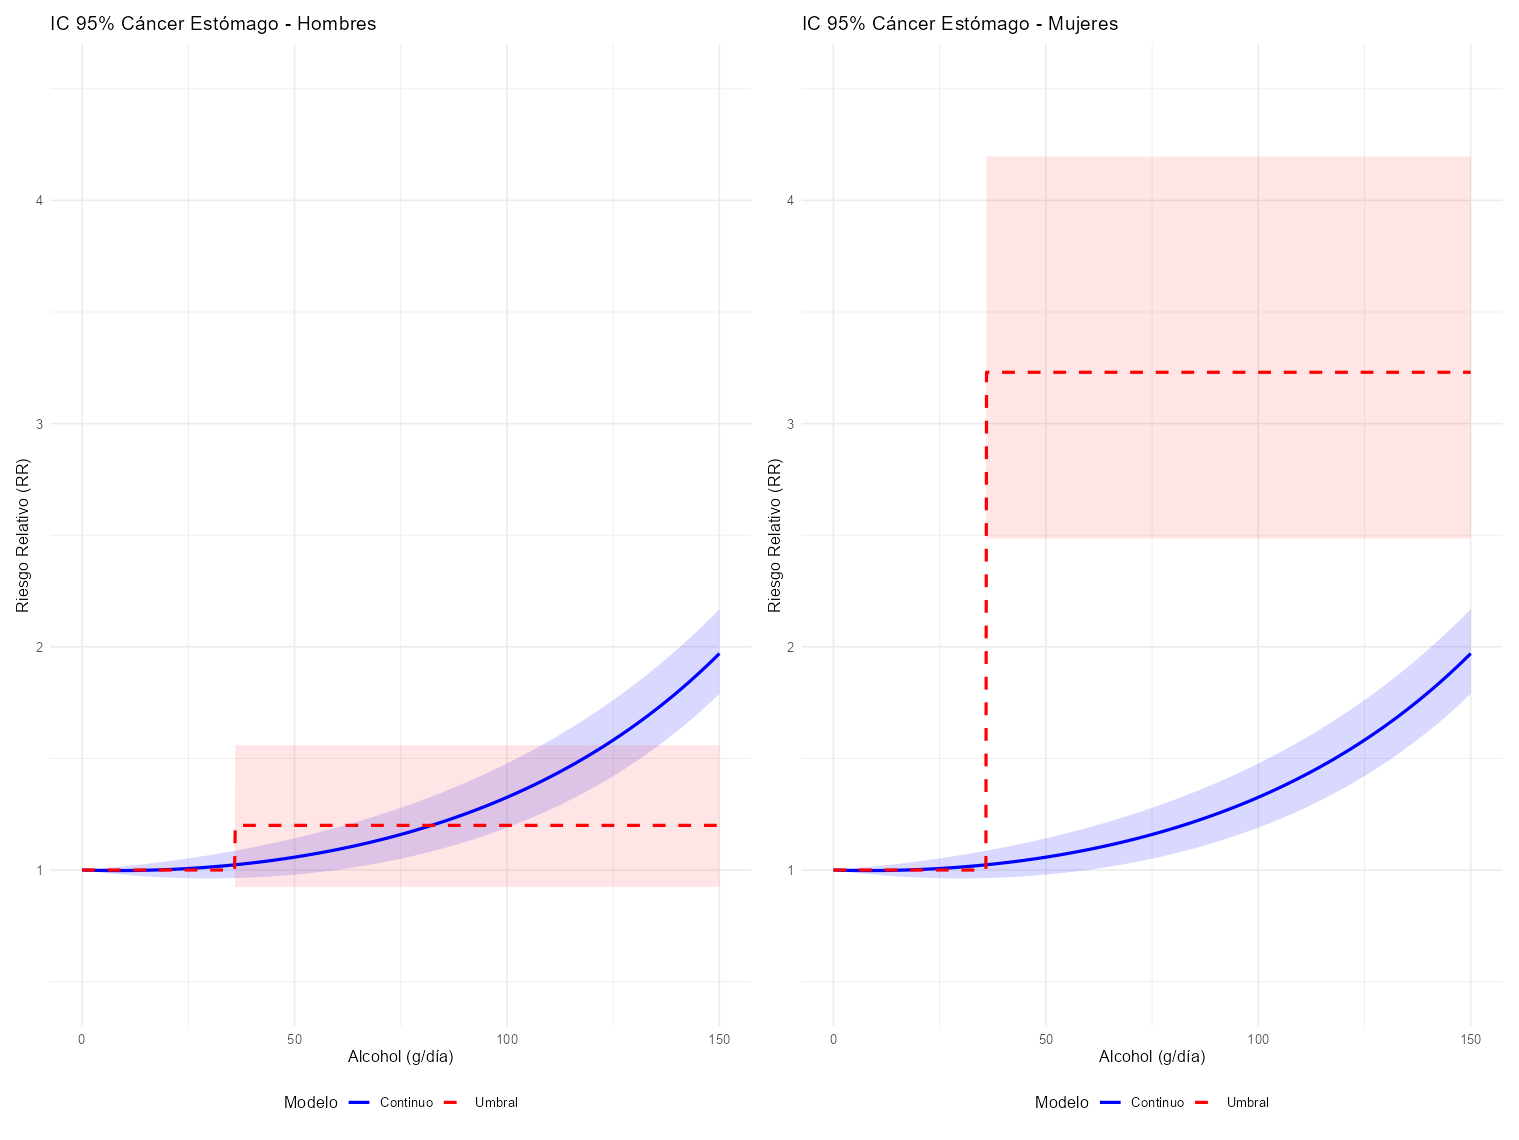

In [393]:
#| label: mort-trends-age-sex-chile27
#| results: "hold"

source(paste0(getwd(),"/stomach_stomach_diffs.R"))

plot_male + plot_female

### Comparison with older versions

In [394]:
#| label: mort-trends-age-sex-chile13-comparison-me-jrt
#| results: "hold"

#mortality_results
mort_est_jrt <- rio::import(paste0(gsub("/__andres_control","",getwd()),"/","Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/Mortality Estimates.xlsx"))
keys <- c("year", "age_group", "gender", "disease")
vals <- c("mort", "ll_mort", "up_mort")
# Optional cleaning
clean_mort <- function(x) {
  x |>
    dplyr::mutate(
      gender = stringr::str_squish(gender),
      disease = stringr::str_squish(disease)
    )
}
mine_raw <- clean_mort(mortality_results)
jrt_raw  <- clean_mort(mort_est_jrt)
# Check whether duplicated keys have conflicting estimates
mine_conflicts <- mine_raw |>
  dplyr::group_by(across(all_of(keys))) |>
  dplyr::summarise(
    n_rows = n(),
    n_value_sets = n_distinct(paste(mort, ll_mort, up_mort)),
    .groups = "drop"
  ) |>
  dplyr::filter(n_value_sets > 1)

mine_conflicts


# A tibble: 0 × 6
# ℹ 6 variables: year <dbl>, age_group <dbl>, gender <chr>, disease <chr>, n_rows <int>, n_value_sets <int>

In [395]:
#| label: mort-trends-age-sex-chile14-comparison-me-jrt2
#| results: "hold"

mine <- mine_raw |>
  distinct(across(all_of(keys)), .keep_all = TRUE)
jrt <- jrt_raw |>
  distinct(across(all_of(keys)), .keep_all = TRUE)
tol <- 1e-6

mortality_results_fixed <- purrr::imap_dfr(disease_filters, function(filter_info, disease_name) {
  filter_col <- filter_info$filter_col

  purrr::map_dfr(filter_info$genders, function(gender_i) {
    def |>
      dplyr::filter(gender == gender_i) |>
      dplyr::group_by(year, gender, age_group) |>
      dplyr::summarise(
        n = sum(.data[[filter_col]] == 1, na.rm = TRUE),
        .groups = "drop"
      ) |>
      dplyr::filter(n > 0) |>
      dplyr::left_join(
        aaf_long |>
          dplyr::filter(disease == disease_name, gender == gender_i) |>
          dplyr::distinct(year, age_group, gender, disease, .keep_all = TRUE),
        by = c("year", "age_group", "gender")
      ) |>
      dplyr::mutate(
        mort = point * n,
        ll_mort = lower * n,
        up_mort = upper * n,
        disease = disease_name
      ) |>
      dplyr::select(year, age_group, gender, disease, mort, ll_mort, up_mort)
  })
})
comparison <- full_join(
  mine |> rename(
    mort_who24 = mort,
    ll_mort_who24 = ll_mort,
    up_mort_who24 = up_mort
  ),
  jrt |> rename(
    mort_jrt = mort,
    ll_mort_jrt = ll_mort,
    up_mort_jrt = up_mort
  ),
  by = keys
) |>
  mutate(
    diff_mort = mort_who24 - mort_jrt,
    diff_ll_mort = ll_mort_who24 - ll_mort_jrt,
    diff_up_mort = up_mort_who24 - up_mort_jrt,
    pct_diff_mort = if_else(mort_jrt != 0, 100 * diff_mort / mort_jrt, NA_real_),
    status = case_when(
      is.na(mort_who24) ~ "only_in_jrt",
      is.na(mort_jrt) ~ "only_in_who24",
      abs(diff_mort) <= tol &
        abs(diff_ll_mort) <= tol &
        abs(diff_up_mort) <= tol ~ "same",
      TRUE ~ "different"
    )
  )
comparison |> count(status)


# A tibble: 4 × 2
  status            n
  <chr>         <int>
1 different      1120
2 only_in_jrt      53
3 only_in_who24   235
4 same              1

In [396]:
#| label: mort-trends-age-sex-chile14-comparison-me-jrt3
#| results: "hold"

comparison |>
  dplyr::filter(status == "different") |>
  dplyr::arrange(desc(abs(diff_mort))) |>
  dplyr::select(
    year, age_group, gender, disease,
    mort_who24, mort_jrt, diff_mort, pct_diff_mort,
    ll_mort_who24, ll_mort_jrt, diff_ll_mort,
    up_mort_who24, up_mort_jrt, diff_up_mort
  ) |>
  print(n = 50)


# A tibble: 1,120 × 14
    year age_group gender disease                    mort_who24 mort_jrt diff_mort pct_diff_mort ll_mort_who24 ll_mort_jrt diff_ll_mort up_mort_who24 up_mort_jrt diff_up_mort
   <dbl>     <dbl> <chr>  <chr>                           <dbl>    <dbl>     <dbl>         <dbl>         <dbl>       <dbl>        <dbl>         <dbl>       <dbl>        <dbl>
 1  2014         4 Mujer  Hypertensive Heart Disease      62.9     643.     -580.          -90.2         28.0        595.        -567.           97.9       689.        -591. 
 2  2016         4 Mujer  Hypertensive Heart Disease      56.9     588.     -531.          -90.3         26.6        533.        -507.           89.9       644.        -554. 
 3  2020         4 Mujer  Hypertensive Heart Disease      72.2     554.     -482.          -87.0         34.2        498.        -464.          111.        610.        -498. 
 4  2022         4 Hombre Ischaemic Heart Disease        116.      588.     -472.          -80.2      

In [397]:
#| label: mort-trends-age-sex-chile15-comparison-me-jrt4
#| results: "hold"

comparison |>
  filter(status == "different") |>
  group_by(disease) |>
  summarise(
    n_diff = n(),
    mean_abs_diff = mean(abs(diff_mort), na.rm = TRUE),
    max_abs_diff = max(abs(diff_mort), na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(max_abs_diff))


# A tibble: 19 × 4
   disease                     n_diff mean_abs_diff max_abs_diff
   <chr>                        <int>         <dbl>        <dbl>
 1 Hypertensive Heart Disease      61        77.0         580.  
 2 Ischaemic Heart Disease         64        98.6         472.  
 3 Colon and rectum Cancer         61        34.2         223.  
 4 Oesophagus Cancer               42        17.3         119.  
 5 Unintentional Injuries          64        17.9         114.  
 6 Lower Respiratory Infection     63         7.64         76.8 
 7 Road Injuries                   64        28.0          69.0 
 8 Liver Cirrhosis                 63        14.0          61.5 
 9 Liver Cancer                    62        11.3          60.7 
10 DM2                             60         6.50         50.9 
11 Intracerebral Haemorrhage       64         6.51         46.7 
12 Epilepsy                        60         5.00         22.6 
13 Acute Pancreatitis              63         3.64         22.3 
14 Bre

Epilepsy, Ischaemic Stroke, HIV, Lip and Oral Cavity Cancer, Tuberculosis and Intentional Injuries had minor differences. Possibly, having changed the formula for HHD for women and changed exp(1) to exp(0) may have changed the results. Also, in IHD in women, change the sign in the function of RRs, and changed the classification in malignant neoplasms (colon and rectum) may also have changed the results.  This is an example: 

In [398]:
#| label: mort-trends-age-sex-chile16-comparison-me-jrt5
#| results: "hold"

comparison |>
  dplyr::filter(disease == "Ischaemic Heart Disease", gender == "Mujer", age_group == 4) |>
  dplyr::arrange(year) |> 
  knitr::kable("markdown", caption= "Example of IHD for women")



Table: Example of IHD for women

| year| age_group|gender |disease                 | mort_who24| ll_mort_who24| up_mort_who24| mort_jrt| ll_mort_jrt| up_mort_jrt| diff_mort| diff_ll_mort| diff_up_mort| pct_diff_mort|status    |
|----:|---------:|:------|:-----------------------|----------:|-------------:|-------------:|--------:|-----------:|-----------:|---------:|------------:|------------:|-------------:|:---------|
| 2008|         4|Mujer  |Ischaemic Heart Disease |   251.8659|       92.6497|      389.6178| 464.3746|    426.5690|     502.645| -212.5087|    -333.9193|    -113.0272|     -45.76234|different |
| 2010|         4|Mujer  |Ischaemic Heart Disease |   223.9648|       67.8768|      347.4032| 428.8123|    383.7760|     469.696| -204.8475|    -315.8992|    -122.2928|     -47.77090|different |
| 2012|         4|Mujer  |Ischaemic Heart Disease |   169.1898|       21.2550|      287.6510| 405.0848|    362.7520|     442.104| -235.8950|    -341.4970|    -154.4530|     -58.23349|di

### Results

We replicate the results of JRT [@ruiztagle2026sex] but with WHO 2024's AAFs [@who2025alcohol]. We also compared them with Sherk's 2016 report on cancer [@sherk2017intermahp].

#### Pop est

In [399]:
#| label: mort-trends-age-sex-chile16-std-pop
#| results: "hold"

ine_proj <- rio::import((paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ine_proyecciones.xlsx")), sheet=1)
ine_proj2 <- rio::import((paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ine_proyecciones.xlsx")), sheet=2)

# 2026-06-01= spw_male y spw_fem: se calcula pop = sum(tot) antes de filter(age_group > 0), así que el pop incluye a los 
# menores de 15 → los pesos de los 4 grupos adultos suman ~0.74. spw_tot: se hace bind_rows de spw_male/spw_fem 
# que ya vienen filtrados >0, luego pop = sum(tot) → los pesos suman 1. Por tanto, se corrige

prep_pop_age <- function(dat) {
  dat |>
    dplyr::mutate(
      edad = as.numeric(ifelse(edad == "100+", 100, edad)),
      age_group = dplyr::case_when(
        edad < 15 ~ 0L,
        dplyr::between(edad, 15, 29) ~ 1L,
        dplyr::between(edad, 30, 44) ~ 2L,
        dplyr::between(edad, 45, 59) ~ 3L,
        edad >= 60 ~ 4L
      )
    ) |>
    tidyr::pivot_longer(
      cols = tidyselect::starts_with("ano_"),
      names_to = "year",
      values_to = "value"
    ) |>
    dplyr::mutate(year = as.numeric(gsub("ano_", "", year))) |>
    dplyr::group_by(year, age_group) |>
    dplyr::summarise(tot = sum(value, na.rm = TRUE), .groups = "drop")
}

pop_male <- prep_pop_age(ine_proj)
pop_fem <- prep_pop_age(ine_proj2)

pop_tot <- dplyr::bind_rows(pop_male, pop_fem) |>
  dplyr::group_by(year, age_group) |>
  dplyr::summarise(tot = sum(tot, na.rm = TRUE), .groups = "drop")

make_chile2018_std <- function(pop_tot, adult_denominator = TRUE) {
  std0 <- pop_tot |> dplyr::filter(year == 2018)

  denom <- if (adult_denominator) {
    std0 |> dplyr::filter(age_group > 0) |> dplyr::summarise(n = sum(tot)) |> dplyr::pull(n)
  } else {
    std0 |> dplyr::summarise(n = sum(tot)) |> dplyr::pull(n)
  }

  std0 |>
    dplyr::filter(age_group > 0) |>
    dplyr::transmute(age_group, spw = tot / denom)
}

std_chile2018_15plus <- make_chile2018_std(pop_tot, adult_denominator = TRUE)
std_chile2018_all_age <- make_chile2018_std(pop_tot, adult_denominator = FALSE)

std_who_world_all_age <- tibble::tribble(
  ~age_group, ~spw,
  1L, (8.47 + 8.22 + 7.93) / 100,
  2L, (7.61 + 7.15 + 6.59) / 100,
  3L, (6.04 + 5.37 + 4.55) / 100,
  4L, (3.72 + 2.96 + 2.21 + 1.52 + 0.91 + 0.44 + 0.15 + 0.04 + 0.005) / 100
)


# STANDARD POPULATION
# Elige UNO:
std_age <- std_chile2018_15plus      # reporte 15+
# std_age <- std_chile2018_all_age   # reporte all-ages Chile 2018
# std_age <- std_who_world_all_age   # comparacion WHO GHO all-ages


spw_male <- pop_male |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")

spw_fem <- pop_fem |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")

spw_tot <- pop_tot |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")


# 2026-06-02= Version completa de GPT (con IC + guard de NA). Dejala tal cual.
make_std_rate <- function(dat, pop_df, group_label) {
  joined <- dat |>
    dplyr::group_by(year, age_group) |>
    dplyr::summarise(
      mort = sum(mort, na.rm = TRUE),
      ll_mort = sum(ll_mort, na.rm = TRUE),
      up_mort = sum(up_mort, na.rm = TRUE),
      .groups = "drop"
    ) |>
    dplyr::left_join(
      pop_df |> dplyr::ungroup() |> dplyr::select(year, age_group, tot, spw),
      by = c("year", "age_group")
    )

  if (any(is.na(joined$tot)) || any(is.na(joined$spw)))
    stop("Missing tot/spw after join for group: ", group_label)

  joined |>
    dplyr::mutate(
      mort_rate    = mort    / tot * 100000,
      ll_mort_rate = ll_mort / tot * 100000,
      up_mort_rate = up_mort / tot * 100000
    ) |>
    dplyr::group_by(year) |>
    dplyr::summarise(
      std_mort_rate    = sum(mort_rate * spw),
      ll_std_mort_rate = sum(ll_mort_rate * spw),
      up_std_mort_rate = sum(up_mort_rate * spw),
      .groups = "drop"
    ) |>
    dplyr::mutate(gender = group_label)   # 'gender' para que calce con la Figura 1
}

# OJO con las etiquetas: tu Figura 1 keyea en "Male"/"Female"/"Total".
# El filtro entra en español (gender de mortality_results = "Hombre"/"Mujer"),
# pero la ETIQUETA de salida debe ser inglesa para que matcheen las escalas.
std_rates <- dplyr::bind_rows(
  make_std_rate(mortality_results,                                    spw_tot,  "Total"),
  make_std_rate(mortality_results |> dplyr::filter(gender == "Hombre"), spw_male, "Male"),
  make_std_rate(mortality_results |> dplyr::filter(gender == "Mujer"),  spw_fem,  "Female")
)

# alias para no tocar la Figura 1: usa el mismo nombre que ya espera
combined_results <- std_rates

combined_results |> 
knitr::kable("markdown", caption= "Standardized population")



Table: Standardized population

| year| std_mort_rate| ll_std_mort_rate| up_std_mort_rate|gender |
|----:|-------------:|----------------:|----------------:|:------|
| 2008|      57.53995|        39.055175|         75.96528|Total  |
| 2010|      49.53230|        34.935404|         64.80111|Total  |
| 2012|      40.93530|        26.521829|         55.69167|Total  |
| 2014|      40.25805|        23.894582|         56.31092|Total  |
| 2016|      41.14782|        27.225905|         55.17971|Total  |
| 2018|      41.99194|        28.385432|         55.80907|Total  |
| 2020|      39.00279|        25.393640|         52.54180|Total  |
| 2022|      39.03174|        25.551931|         52.89222|Total  |
| 2008|      94.71767|        64.007847|        125.01705|Male   |
| 2010|      81.46642|        58.446000|        105.59619|Male   |
| 2012|      68.63550|        44.699689|         93.22014|Male   |
| 2014|      67.31164|        41.440537|         93.14944|Male   |
| 2016|      66.71705|      

In [400]:
#| label: mort-trends-age-sex-chile16b-std-pop
#| results: "hold"
dplyr::bind_rows(
  spw_tot |> dplyr::group_by(year) |> dplyr::summarise(group = "Total", sum_spw = sum(spw), .groups = "drop"),
  spw_male |> dplyr::group_by(year) |> dplyr::summarise(group = "Hombre", sum_spw = sum(spw), .groups = "drop"),
  spw_fem |> dplyr::group_by(year) |> dplyr::summarise(group = "Mujer", sum_spw = sum(spw), .groups = "drop")
) |>
  dplyr::group_by(group) |>
  dplyr::summarise(min_sum = min(sum_spw), max_sum = max(sum_spw), .groups = "drop")

# --- VALIDACION del estandar (no solo min==max: afirmar el valor esperado) ---
expected_sum <- 1.0   # std_chile2018_15plus suma 1.0 sobre 15+
                      # (si algun dia cambias a all-ages/WHO, pon 0.73885)

check_spw <- dplyr::bind_rows(
  spw_tot  |> dplyr::group_by(year) |> dplyr::summarise(group = "Total",  sum_spw = sum(spw), .groups = "drop"),
  spw_male |> dplyr::group_by(year) |> dplyr::summarise(group = "Hombre", sum_spw = sum(spw), .groups = "drop"),
  spw_fem  |> dplyr::group_by(year) |> dplyr::summarise(group = "Mujer",  sum_spw = sum(spw), .groups = "drop")
)

# 1) ningun NA (el left_join(std_age) no falló y no falta age_group)
if (any(is.na(check_spw$sum_spw)))
  stop("spw with NA: left_join(std_age) failed or an age group was missing in pop_* database.")

# 2) los 3 grupos, TODOS los años, suman EXACTAMENTE el estandar elegido
if (!all(abs(check_spw$sum_spw - expected_sum) < 1e-6))
  stop(sprintf("spw does not sum %.5f in an age.group (observed range [%.5f, %.5f]). Check std_age.",
               expected_sum, min(check_spw$sum_spw), max(check_spw$sum_spw)))

# 3) confirmar que std_age es el que crees
if (abs(sum(std_age$spw) - expected_sum) >= 1e-6)
  stop(sprintf("std_age sums %.5f, and expected %.5f. Did you take std_chile2018_15plus?",
               sum(std_age$spw), expected_sum))

cat(sprintf("OK standardization: spw = %.4f in %d age group (std_age = std_chile2018_15plus).\n",
            expected_sum, nrow(check_spw)))


OK standardization: spw = 1.0000 in 26 age group (std_age = std_chile2018_15plus).


#### Figure 1

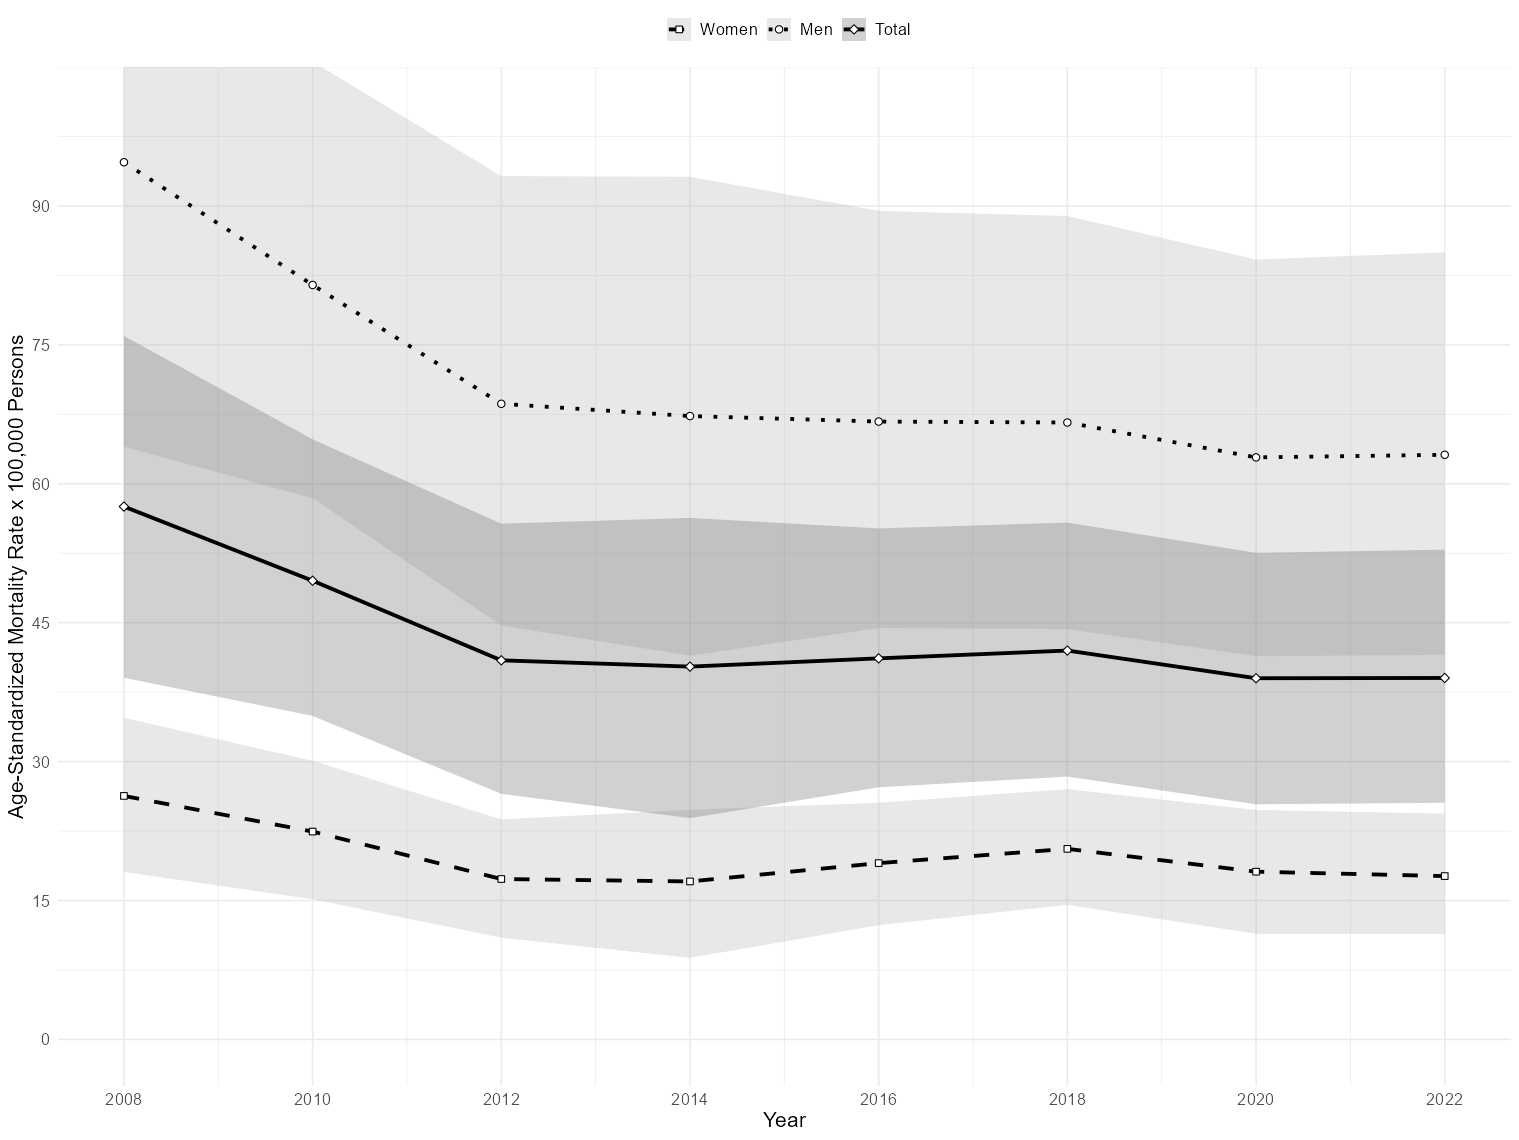

In [401]:
#| label: mort-trends-age-sex-chile17-fig1
#| results: "hold"

# Plot the unified figure
ggplot(combined_results, aes(x = year, y = std_mort_rate, linetype = gender, fill = gender)) +
  # Confidence interval ribbons
  geom_ribbon(
    aes(ymin = ll_std_mort_rate, ymax = up_std_mort_rate, fill = gender),
    alpha = 0.3, color = NA
  ) +
  # Lines for age-standardized mortality
  geom_line(
    aes(linetype = gender),
    linewidth = 1.2, color = "black"
  ) +
  # Points for age-standardized mortality
  geom_point(
    aes(shape = gender),
    size = 2, color = "black", fill = "white"
  ) +
  # Customize scales and labels
  scale_x_continuous(
    breaks = c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022),
    labels = c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022)
  ) +
  scale_y_continuous(breaks = seq(0, 100, 15)) +
  coord_cartesian(ylim = c(0, 100)) +
  labs(
    x = "Year",
    y = "Age-Standardized Mortality Rate x 100,000 Persons",
    linetype = "",
    fill = "",
    shape = ""
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top",
    legend.key = element_blank()  # Remove background in legend
  ) +
  # Customize linetypes, fill colors, and shapes for Total and genders
  scale_linetype_manual(
    values = c("Male" = "dotted", "Female" = "dashed", "Total" = "solid"),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Male" = "gray70", "Female" = "gray70", "Total" = "gray40"),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Male" = 21, "Female" = 22, "Total" = 23),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  )



fig1 <- ggplot(combined_results, aes(x = year, group = gender)) +
  geom_ribbon(
    aes(ymin = ll_std_mort_rate, ymax = up_std_mort_rate, fill = gender),
    alpha = 0.38,
    color = NA
  ) +
  geom_line(
    aes(y = std_mort_rate, linetype = gender),
    linewidth = 1.15,
    color = "black"
  ) +
  geom_point(
    aes(y = std_mort_rate, shape = gender),
    size = 2.6,
    color = "black",
    fill = "white",
    stroke = 0.85
  ) +
  scale_x_continuous(
    breaks = seq(2008, 2022, 2),
    expand = expansion(mult = c(0.01, 0.03))
  ) +
  scale_y_continuous(
    breaks = seq(0, 100, 15),
    expand = expansion(mult = c(0.01, 0.04))
  ) +
  coord_cartesian(ylim = c(0, 100)) +
  scale_linetype_manual(
    values = c("Female" = "dashed", "Male" = "dotted", "Total" = "solid"),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Female" = 22, "Male" = 21, "Total" = 23),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Female" = "grey82", "Male" = "grey82", "Total" = "grey55"),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  labs(
    x = "Year",
    y = "Age-Standardized Mortality Rate x 100,000 Persons",
    linetype = NULL,
    shape = NULL,
    fill = NULL
  ) +
  guides(
    fill = "none",
    linetype = guide_legend(nrow = 1),
    shape = guide_legend(nrow = 1)
  ) +
  theme_minimal(base_size = 17) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.text = element_text(size = 16),
    legend.key = element_rect(fill = "grey82", color = NA),
    legend.key.width = unit(0.95, "cm"),
    legend.spacing.x = unit(0.25, "cm"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 15),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3),
    plot.margin = margin(8, 12, 8, 12)
  )

ggsave(
  filename = "__andres_control/Figure 1.png",
  plot = fig1,
  width = 5.52,
  height = 7.11,
  units = "in",
  dpi = 300,
  bg = "white"
)

In [402]:
#| label: mort-trends-age-sex-chile18-fig2-pre
#| results: "hold"

death_sex <- def %>%
  group_by(year, gender) %>%
  summarise(n = n(), .groups = "drop")

tot_death <- def %>%
  group_by(year) %>%
  summarise(n = n(), .groups = "drop")

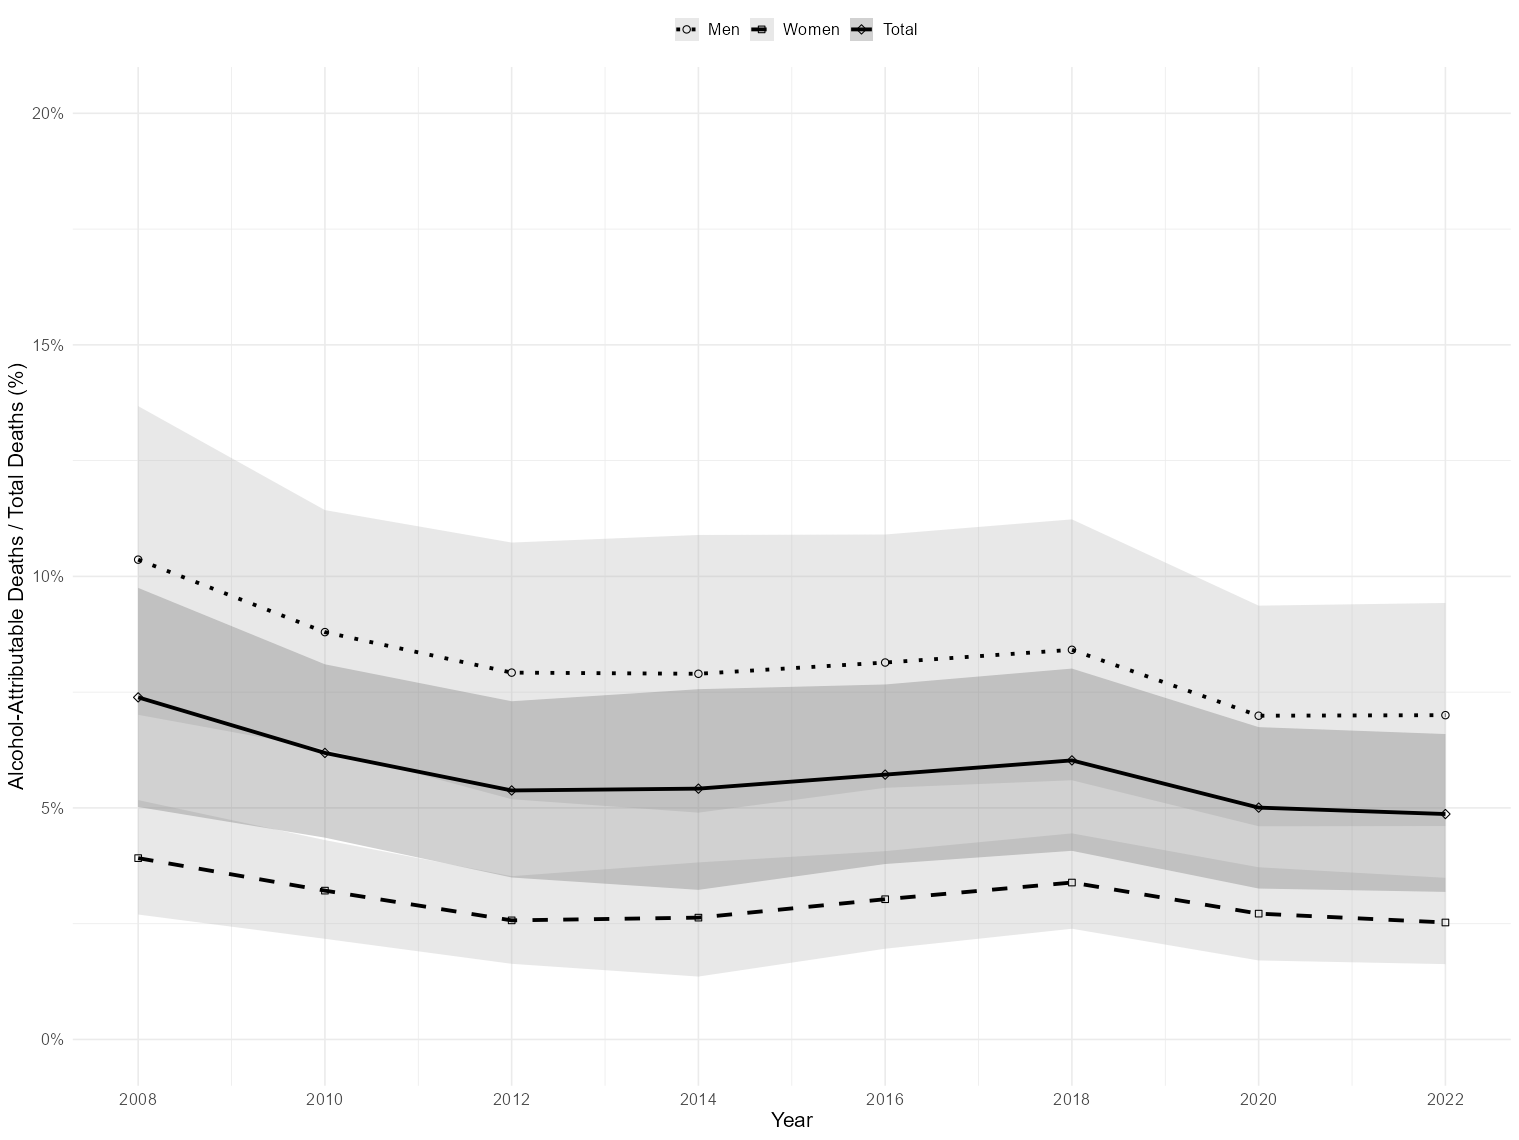

In [403]:
#| label: mort-trends-age-sex-chile18-fig2
#| results: "hold"

# 1. Ajustar los cálculos para convertir a porcentaje (multiplicar por 100)
gender_data <- mortality_results %>% 
  group_by(year, gender) %>% 
  summarise(
    mort = sum(mort),
    ll_mort = sum(ll_mort),
    up_mort = sum(up_mort),
    .groups = "drop"
  ) %>% 
  left_join(death_sex, by = c("year", "gender")) %>% 
  mutate(
    prop = (mort / n) * 100,      # Multiplicado por 100
    ll_prop = (ll_mort / n) * 100,
    up_prop = (up_mort / n) * 100
  )

total_data <- mortality_results %>% 
  group_by(year) %>% 
  summarise(
    mort = sum(mort),
    ll_mort = sum(ll_mort),
    up_mort = sum(up_mort),
    .groups = "drop"
  ) %>% 
  left_join(tot_death, by = "year") %>% 
  mutate(
    prop = (mort / n) * 100,      # Multiplicado por 100
    ll_prop = (ll_mort / n) * 100,
    up_prop = (up_mort / n) * 100
  ) %>% 
  mutate(gender = "Total")

combined_data <- bind_rows(gender_data, total_data)

# 2. Ajustar el gráfico
ggplot(combined_data) +
  geom_ribbon(
    aes(x = year, ymin = ll_prop, ymax = up_prop, fill = gender),
    alpha = 0.3, color = NA
  ) +
  geom_line(
    aes(x = year, y = prop, linetype = gender),
    color = "black", linewidth = 1.2 # Se recomienda usar linewidth en versiones recientes
  ) +
  geom_point(
    aes(x = year, y = prop, shape = gender),
    color = "black", size = 2
  ) +
  scale_x_continuous(
    breaks = seq(2008, 2022, 2)
  ) +
  # Ajustar escala Y de 0 a 20 (que representa 0% a 20%)
  scale_y_continuous(
    breaks = seq(0, 20, 5),
    labels = function(x) paste0(x, "%")
  ) +
  coord_cartesian(ylim = c(0, 20)) +
  labs(
    x = "Year",
    y = "Alcohol-Attributable Deaths / Total Deaths (%)",
    linetype = "",
    shape = "",
    fill = ""
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top"
  ) +
  scale_linetype_manual(
    values = c("Hombre" = "dotted", "Mujer" = "dashed", "Total" = "solid"),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Hombre" = "gray70", "Mujer" = "gray70", "Total" = "gray40"),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Hombre" = 21, "Mujer" = 22, "Total" = 23),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  )

combined_data <- bind_rows(gender_data, total_data) %>%
  mutate(gender = factor(gender, levels = c("Mujer", "Hombre", "Total")))

fig2 <- ggplot(combined_data, aes(x = year, group = gender)) +
  geom_ribbon(
    aes(ymin = ll_prop, ymax = up_prop, fill = gender),
    alpha = 0.38,
    color = NA
  ) +
  geom_line(
    aes(y = prop, linetype = gender),
    color = "black",
    linewidth = 1.15
  ) +
  geom_point(
    aes(y = prop, shape = gender),
    color = "black",
    fill = "white",
    size = 2.6,
    stroke = 0.85
  ) +
  scale_x_continuous(
    breaks = seq(2008, 2022, 2),
    expand = expansion(mult = c(0.01, 0.03))
  ) +
  scale_y_continuous(
    breaks = seq(5, 25, 5),
    labels = function(x) paste0(x, "%"),
    expand = expansion(mult = c(0.01, 0.04))
  ) +
  #coord_cartesian(ylim = c(5, 25.8)) +
  scale_linetype_manual(
    values = c("Mujer" = "dashed", "Hombre" = "dotted", "Total" = "solid"),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Mujer" = 22, "Hombre" = 21, "Total" = 23),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Mujer" = "grey82", "Hombre" = "grey82", "Total" = "grey55"),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  labs(
    x = "Year",
    y = "Alcohol-Attributable Deaths / Total Deaths",
    linetype = NULL,
    shape = NULL,
    fill = NULL
  ) +
  guides(
    fill = "none",
    linetype = guide_legend(nrow = 1),
    shape = guide_legend(nrow = 1)
  ) +
  theme_minimal(base_size = 17) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.text = element_text(size = 16),
    legend.key = element_rect(fill = "grey82", color = NA),
    legend.key.width = unit(0.95, "cm"),
    legend.spacing.x = unit(0.25, "cm"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 15),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3),
    plot.margin = margin(8, 12, 8, 12)
  )

ggsave(
  filename = "__andres_control/Figure 2.png",
  plot = fig2,
  width = 5.52,
  height = 7.11,
  units = "in",
  dpi = 300,
  bg = "white"
)


#### Figure 3

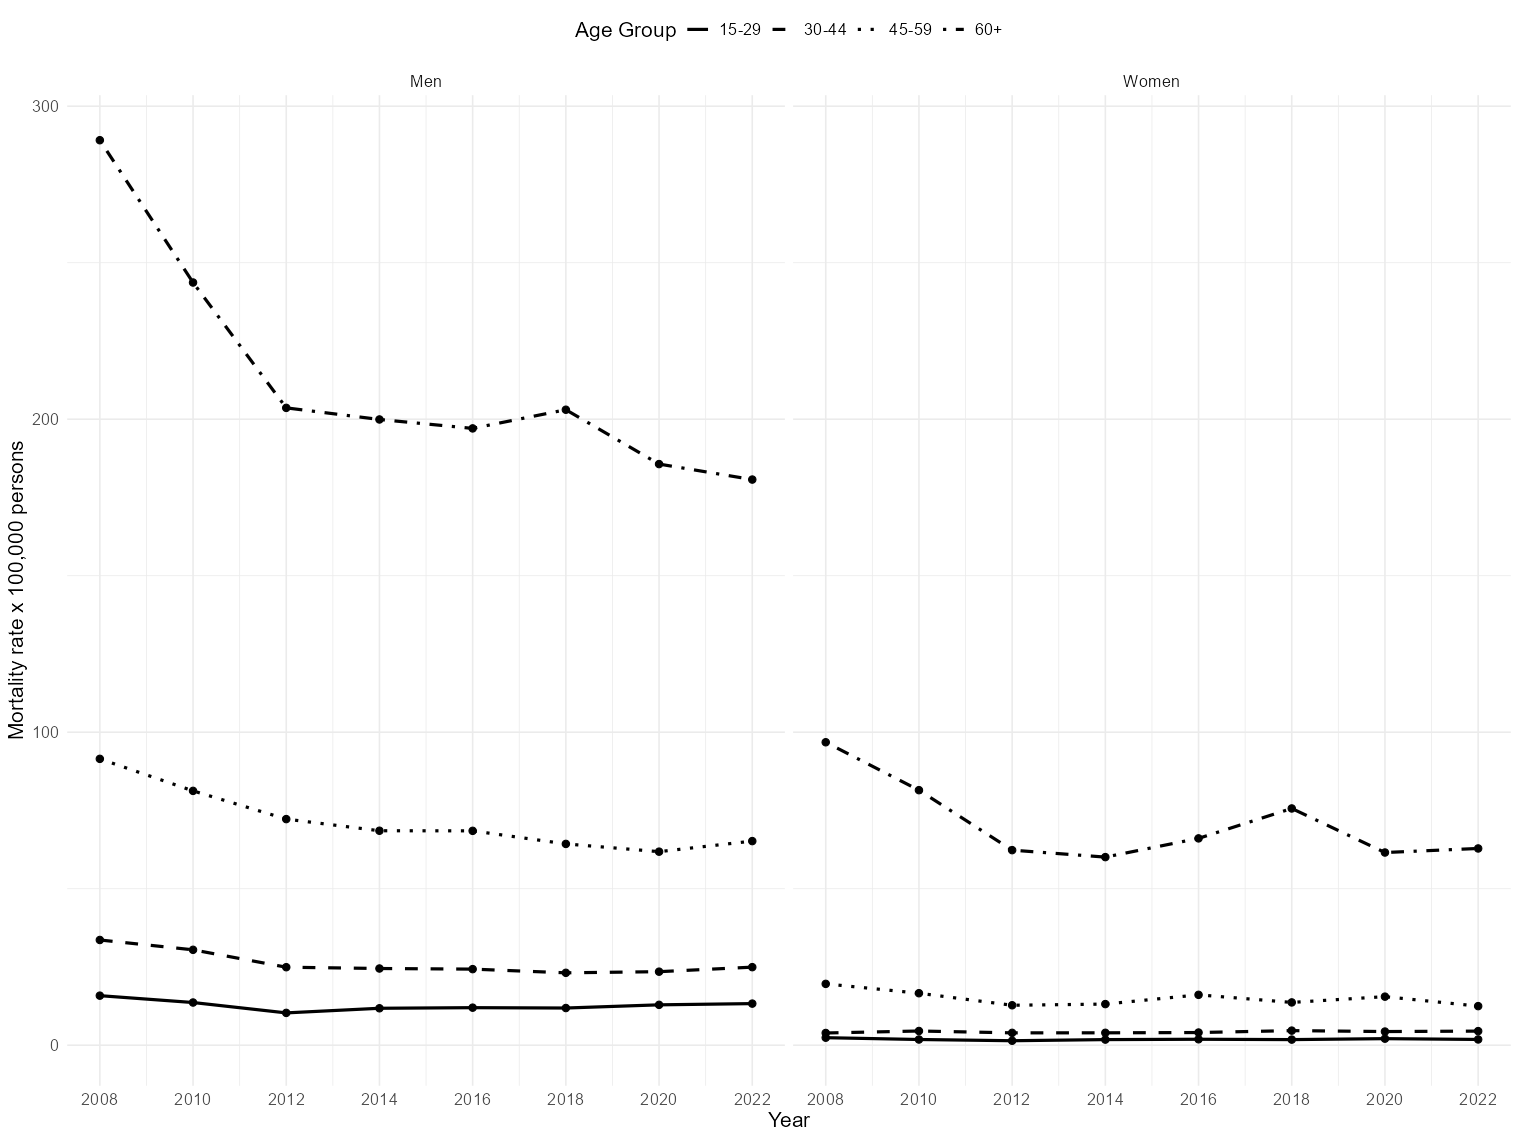

In [404]:
#| label: mort-trends-age-sex-chile19-fig3
#| results: "hold"

# 2026-06-02: stop dividing deaths by sex by the total population
spw_by_sex <- dplyr::bind_rows(
  spw_male |> dplyr::mutate(gender = "Hombre"),
  spw_fem  |> dplyr::mutate(gender = "Mujer")
) |> dplyr::select(year, age_group, gender, tot, spw)


mortality_results %>% 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group) # Se eliminó .groups
  ) %>% 
  # 2026-06-02: divide deaths by sex by the total population
    left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>%
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000
  ) %>% 
  ggplot(aes(x = year, y = mort_rate, linetype = factor(age_group))) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = seq(2008, 2022, 2)
  ) +
  scale_linetype_manual(
    values = c("1" = "solid", "2" = "dashed", "3" = "dotted", "4" = "dotdash"),
    labels = c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+")
  ) +
  facet_wrap(~ gender, labeller = as_labeller(c("Mujer" = "Women", "Hombre" = "Men"))) +
  labs(
    x = "Year",
    y = "Mortality rate x 100,000 persons",
    linetype = "Age Group"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top"
  )

fig3 <- mortality_results %>% 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group)
  ) %>% 
  # 2026-06-02: divide deaths by sex by the total population
  left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>%
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000,
    gender = factor(gender, levels = c("Hombre", "Mujer")),
    age_group = factor(age_group, levels = c("1", "2", "3", "4"))
  ) %>% 
  ggplot(aes(x = year, y = mort_rate, linetype = age_group)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.4, color = "black") +
  scale_x_continuous(breaks = seq(2008, 2022, 2)) +
  scale_y_continuous(
    breaks = c(0, 200, 400),
    limits = c(0, 600)
  ) +
  scale_linetype_manual(
    values = c("1" = "solid", "2" = "dashed", "3" = "dotted", "4" = "dotdash"),
    labels = c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+")
  ) +
  facet_wrap(
    ~ gender,
    labeller = as_labeller(c("Hombre" = "Men", "Mujer" = "Women"))
  ) +
  labs(
    x = "Year",
    y = "Mortality rate x 100,000 persons",
    linetype = "Age Group"
  ) +
  guides(
    linetype = guide_legend(
      title.position = "left",
      nrow = 1
    )
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.title = element_text(size = 18),
    legend.text = element_text(size = 14),
    legend.key.width = unit(1.2, "cm"),
    strip.text = element_text(size = 14),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 13),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = "__andres_control/Figure 3.png",
  plot = fig3,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

In [405]:
mortality_results |> 
  filter(grepl("Injuries",disease)) |> 
  group_by(disease) |> 
  summarise(mean= mean(mort))

# A tibble: 3 × 2
  disease                 mean
  <chr>                  <dbl>
1 Intentional Injuries    15.5
2 Road Injuries           61.8
3 Unintentional Injuries  61.5

In [406]:
mort_est_jrt |> 
 filter(grepl("Injuries",disease)) |> 
  group_by(disease) |> 
  summarise(mean= mean(mort))

# A tibble: 3 × 2
  disease                 mean
  <chr>                  <dbl>
1 Intentional Injuries    17.2
2 Road Injuries           34.0
3 Unintentional Injuries  47.6

In [407]:
#| label: mort-trends-age-sex-chile19b-fig3-2022
#| results: "hold"

mortality_results %>% 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group)
  ) %>% 
  left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>% 
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000,
    gender = factor(gender, levels = c("Hombre", "Mujer")),
    age_group = factor(age_group, levels = c("1", "2", "3", "4"))
  ) |> 
  dplyr::filter(year==2022)

# A tibble: 8 × 11
   year gender age_group   mort ll_mort up_mort     tot   spw mort_rate ll_mort_rate up_mort_rate
  <dbl> <fct>  <fct>      <dbl>   <dbl>   <dbl>   <dbl> <dbl>     <dbl>        <dbl>        <dbl>
1  2022 Mujer  1           38.2    19.9    61.5 2070056 0.287      1.85        0.963         2.97
2  2022 Mujer  2          102.     65.7   144.  2254953 0.273      4.51        2.91          6.37
3  2022 Mujer  3          236.    169.    314.  1891977 0.234     12.5         8.95         16.6 
4  2022 Mujer  4         1253.    794.   1732.  1993360 0.206     62.9        39.9          86.9 
5  2022 Hombre 1          284.    146.    434.  2135507 0.287     13.3         6.84         20.3 
6  2022 Hombre 2          575.    355.    791.  2304896 0.273     24.9        15.4          34.3 
7  2022 Hombre 3         1196.    874.   1516.  1833254 0.234     65.2        47.7          82.7 
8  2022 Hombre 4         2901.   1885.   3928.  1605194 0.206    181.        117.          245.  

In [408]:
#| label: mort-trends-age-sex-chile19b-fig3-2022-group1
#| results: "hold"

att_15_29_2022 <- mortality_results |>
  dplyr::filter(year == 2022, age_group == 1) |>
  dplyr::summarise(att = sum(mort, na.rm = TRUE))

den_15_29_2022 <- def |>
  dplyr::filter(year == 2022, age_group == 1) |>
  dplyr::summarise(deaths = dplyr::n())

print(paste0("Percentage of in 15-29 yrs. :", att_15_29_2022$att / den_15_29_2022$deaths * 100))

[1] "Percentage of in 15-29 yrs. :10.9455713829426"


In [409]:
att_60_2022 <- mortality_results |>
  dplyr::filter(year == 2022, age_group == 4) |>
  dplyr::summarise(att = sum(mort, na.rm = TRUE))

den_60_2022 <- def |>
  dplyr::filter(year == 2022, age_group == 4) |>
  dplyr::summarise(deaths = dplyr::n())

att_60_2022$att / den_60_2022$deaths * 100

[1] 3.703831

In [410]:
path <- paste0(gsub("/__andres_control","/",getwd()),"Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/Mortality Estimates.xlsx") 
print(path)
mort_est_prev<- rio::import(path)

[1] "c:/Users/nDP/Desktop/ACC1240138_private/Sex-and-age-differences-in-alcohol-attributable-mortality-in-Chile-between-2008-and-2022-main/Mortality Estimates.xlsx"


In [411]:
mort_est_prev |>
  dplyr::filter(year == 2022, age_group == 4) |>
  dplyr::summarise(att = sum(mort, na.rm = TRUE))

       att
1 9100.725

#### Figure 5

Check missing categories

In [412]:
cats_106 <- c("Breast Cancer","Colon and rectum Cancer","Larynx Cancer",
  "Oral Cavity and Pharynx Cancer","Other Pharyngeal Cancer","Liver Cancer",
  "Oesophagus Cancer","Stomach Cancer","Pancreatic Cancer",
  "Intentional Injuries","Road Injuries","Unintentional Injuries",
  "Hypertensive Heart Disease","Intracerebral Haemorrhage","Ischaemic Heart Disease",
  "Ischaemic Stroke","DM2","Liver Cirrhosis","Lower Respiratory Infection",
  "Tuberculosis","Acute Pancreatitis","HIV","Epilepsy")
setdiff(unique(mortality_results$disease), cats_106)   # lo que cae en NA en Fig 4/5

character(0)

In [413]:
# 2026-06-02= Many categories bad defined or twice. Check consistency
mortality_results_cat <- mortality_results %>%
  mutate(category = case_when(
    disease %in% c("Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
                   "Lip and Oral Cavity Cancer", "Liver Cancer", "Oesophagus Cancer",
                   "Other Pharyngeal Cancer", "Oral Cavity and Pharynx Cancer", 
                   # 2026-06-02= added Stomach and Pancreatic cancer
                   "Stomach Cancer", "Pancreatic Cancer", "Lip and Oral Cavity Cancer") ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage", 
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection", 
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    TRUE ~ "Uncategorized" # Esto te mostrará si algo se escapó
  ))

table(mortality_results_cat$category, mortality_results_cat$disease) |>  
  knitr::kable("markdown", caption= "Categories and groupings")



Table: Categories and groupings

|                 | Acute Pancreatitis| Breast Cancer| Colon and rectum Cancer| DM2| Epilepsy| HIV| Hypertensive Heart Disease| Intentional Injuries| Intracerebral Haemorrhage| Ischaemic Heart Disease| Ischaemic Stroke| Larynx Cancer| Liver Cancer| Liver Cirrhosis| Lower Respiratory Infection| Oesophagus Cancer| Oral Cavity and Pharynx Cancer| Other Pharyngeal Cancer| Pancreatic Cancer| Road Injuries| Stomach Cancer| Tuberculosis| Unintentional Injuries|
|:----------------|------------------:|-------------:|-----------------------:|---:|--------:|---:|--------------------------:|--------------------:|-------------------------:|-----------------------:|----------------:|-------------:|------------:|---------------:|---------------------------:|-----------------:|------------------------------:|-----------------------:|-----------------:|-------------:|--------------:|------------:|----------------------:|
|Cancer           |                  0|        

There are some cero deaths by calendar year, age group and sex:

| Disease                   | Rows | Missing | Probable Explanation                                      |
|----------------------------|------|---------|-----------------------------------------------------------|
| Breast Cancer              | 32   | 32      | Only women                                                |
| Larynx Cancer              | 42   | 22      | Very rare in young women, zeros in 15–29 and 30–44 groups |
| Other Pharyngeal Cancer    | 50   | 14      | Rare, zeros in young groups and/or women                  |
| Oesophagus Cancer          | 49   | 15      | Same as above                                             |
| Oral Cavity & Pharynx Ca.  | 53   | 11      | Zeros in young groups                                     |
| Pancreatic Cancer          | 55   | 9       | New, zeros in young groups                                |
| Hypertensive Heart Disease | 61   | 3       | Almost complete — 3 cells without deaths                  |
| DM2                        | 60   | 4       | Same                                                      |
| Acute Pancreatitis         | 63   | 1       | Only 1 empty cell                                         |

Warning message:
No shared levels found between `names(values)` of the manual scale and the data's colour values. 


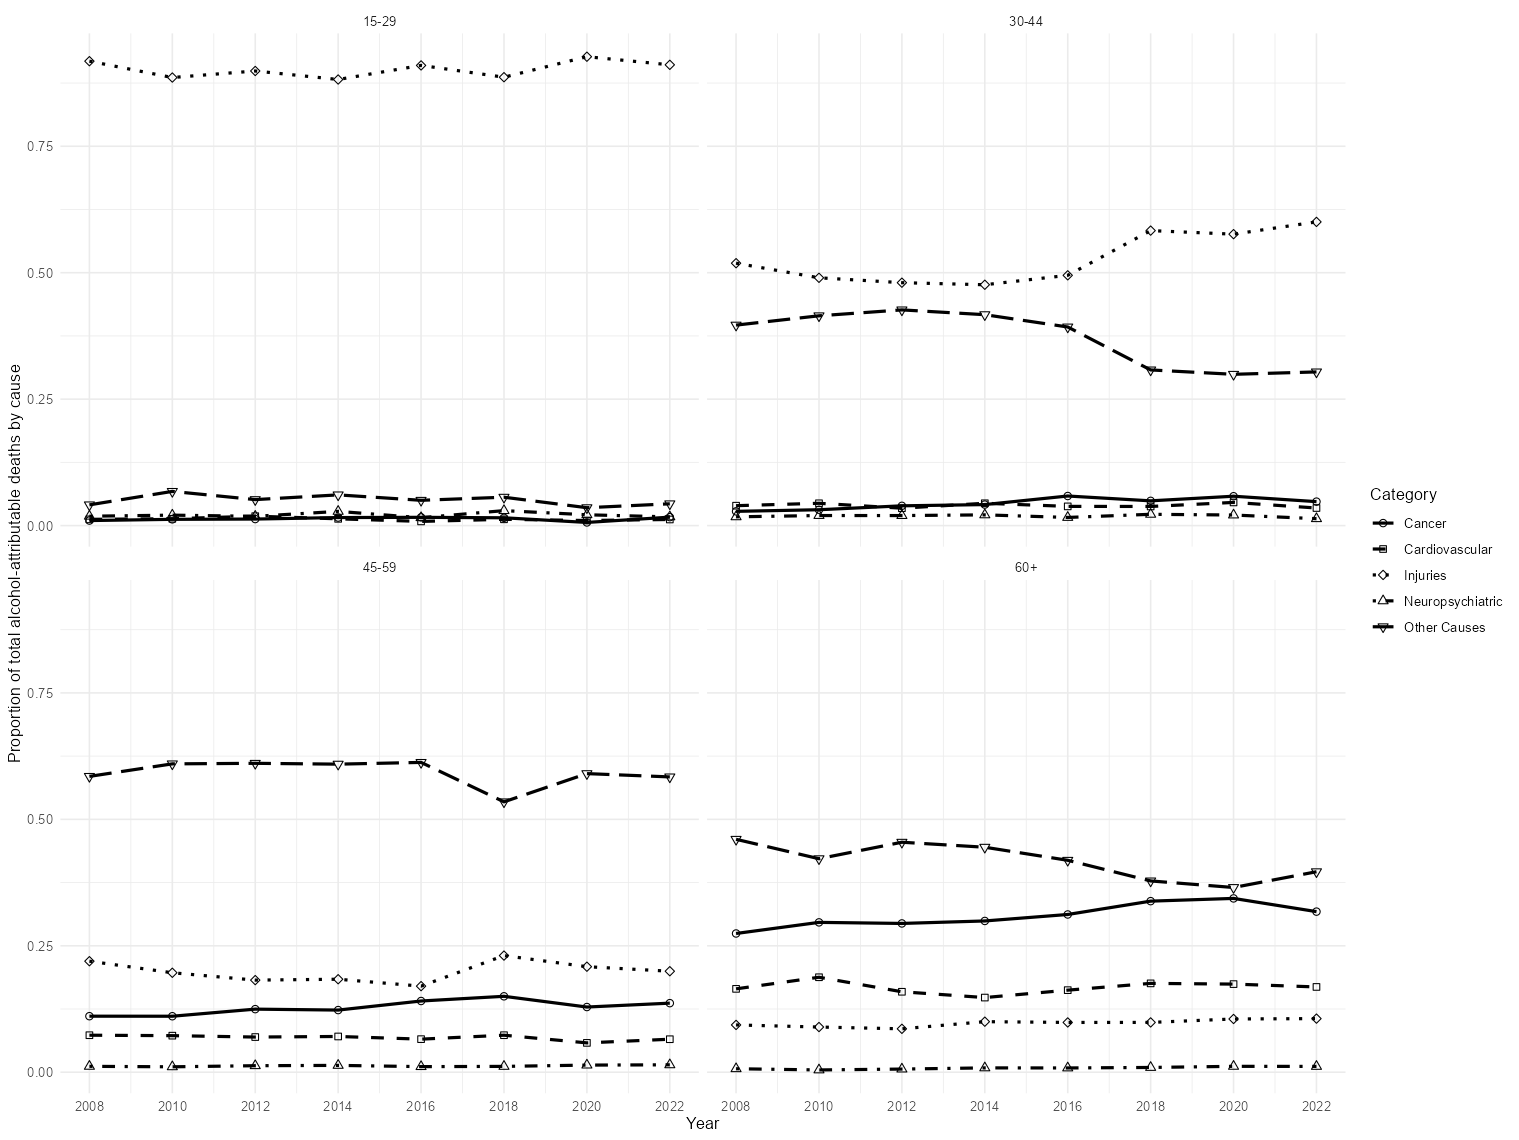

In [414]:
#| label: mort-trends-age-sex-chile20-fig5
#| results: "hold"

mortality_results_cat %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category, col = category)) +  # Map shape to category
  geom_line(size = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022),
    labels = c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022)
  ) +
  scale_color_manual(
    values = c(
      "Cancer" = "black", 
      "Cardiovascular" = "darkgray", 
      "Injuries" = "gray", 
      "Neuropsychiatric" = "lightgray", 
      "Other Causes" = "dimgray"
    )
  ) +
  scale_shape_manual(
    values = c(
      "Cancer" = 21,  # Circle
      "Cardiovascular" = 22,  # Square
      "Injuries" = 23,  # Diamond
      "Neuropsychiatric" = 24,  # Triangle-up
      "Other Causes" = 25  # Triangle-down
    )
  ) +
  scale_linetype_manual(
    values = c(
      "Cancer" = "solid", 
      "Cardiovascular" = "dashed", 
      "Injuries" = "dotted", 
      "Neuropsychiatric" = "dotdash", 
      "Other Causes" = "longdash"
    )
  ) +
  facet_wrap(~ age_group, labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"  # Add shape legend title
  ) +
  theme_minimal()

fig4 <- mortality_results_cat %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2008, 2022, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.2, 0.4, 0.6, 0.8),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = "__andres_control/Figure 5.png",
  plot = fig4,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

[1] "Without pancreatic and stomach cancer, men"


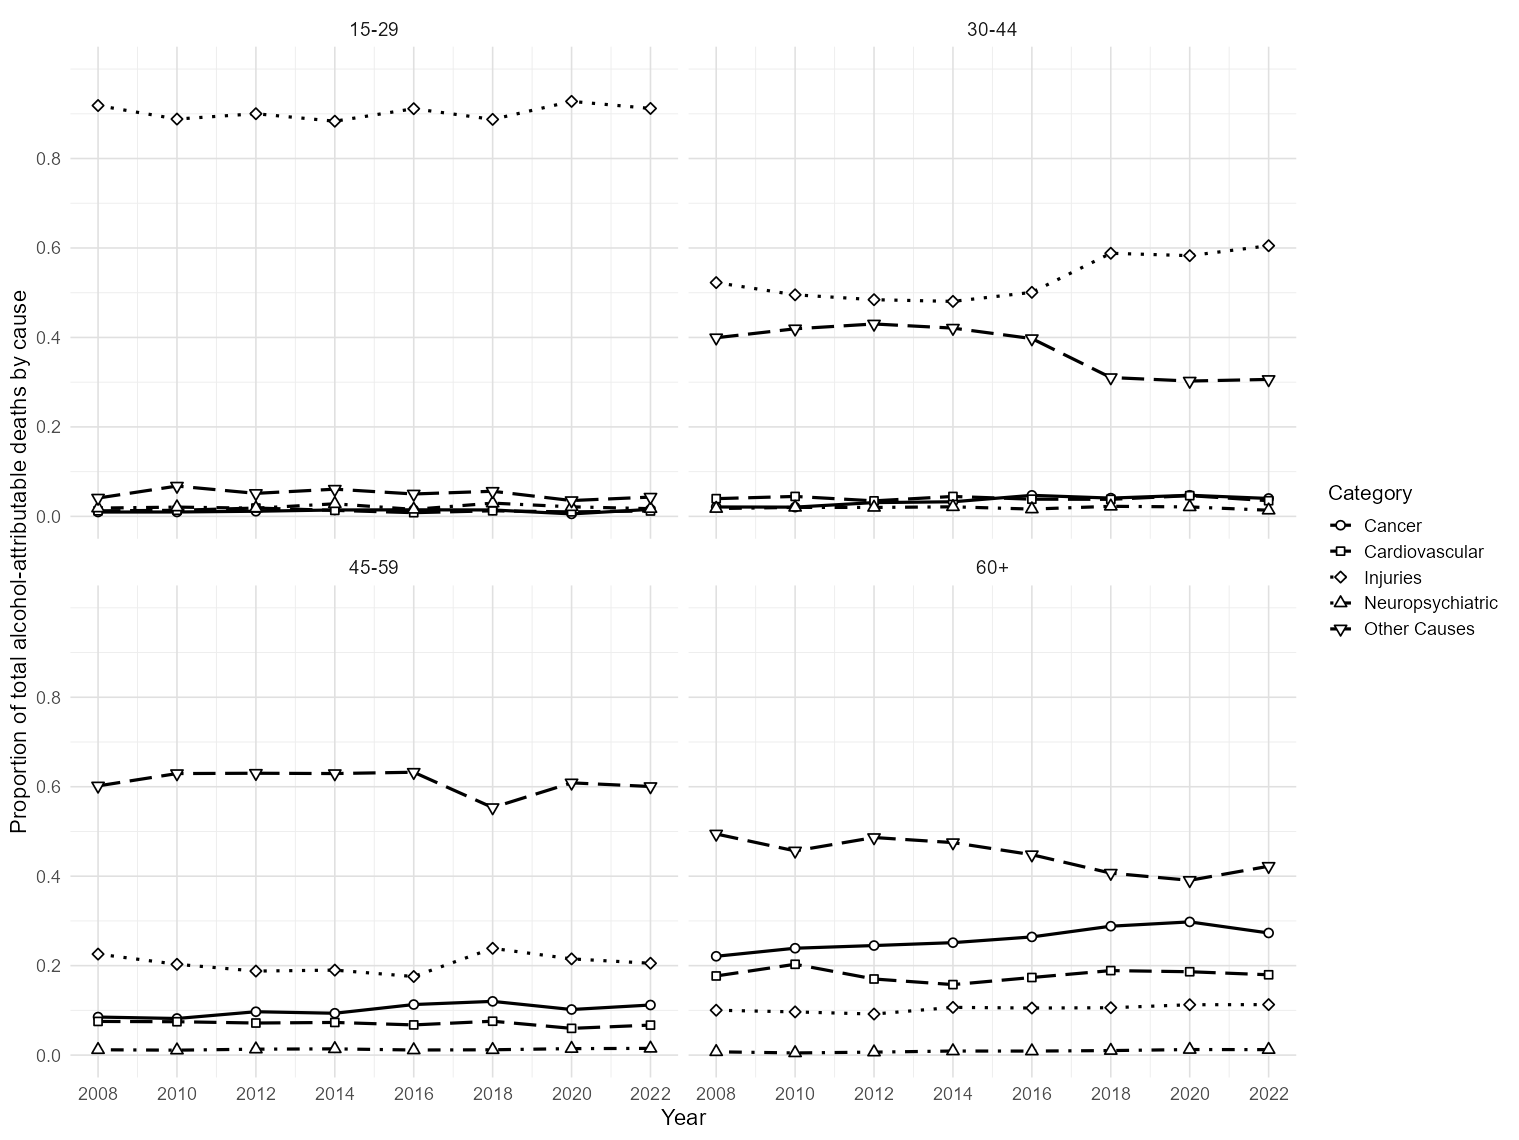

In [415]:
#| label: mort-trends-age-sex-chile20b-fig5
#| results: "hold"

print("Without pancreatic and stomach cancer, men")

mortality_results_cat_not_stomach_pancreas_cancer <- mortality_results %>%
  dplyr::filter(!disease %in% c("Stomach Cancer", "Pancreatic Cancer")) %>%   # <- scope IARC
  dplyr::mutate(category = dplyr::case_when(
    disease %in% c(
      "Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
      "Oral Cavity and Pharynx Cancer", "Other Pharyngeal Cancer",
      "Liver Cancer", "Oesophagus Cancer"
      # Stomach/Pancreatic ya quedaron fuera por el filter de arriba
    ) ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage",
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection",
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    TRUE ~ "Uncategorized"   # red de seguridad
  ))

 mortality_results_cat_not_stomach_pancreas_cancer %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2008, 2022, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.2, 0.4, 0.6, 0.8),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = "__andres_control/Figure 5_not_panc_stomach.png",
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

### Comparison with published article

In [ ]:
#| label: mort-trends-age-sex-chile20-post0
#| results: "hold"

mortality_results_cat_jrt <- mort_est_prev %>%
  mutate(category = case_when(
    disease %in% c("Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
                   "Lip and Oral Cavity Cancer", "Liver Cancer", "Oesophagus Cancer",
                   "Other Pharyngeal Cancer", "Oral Cavity and Pharynx Cancer", 
                   # 2026-06-02= added Stomach and Pancreatic cancer
                   "Stomach Cancer", "Pancreatic Cancer", "Lip and Oral Cavity Cancer") ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage", 
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection", 
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    TRUE ~ "Uncategorized" # Esto te mostrará si algo se escapó
  ))
mortality_results_cat_jrt %>%
  filter(gender == "Hombre") %>%
  group_by(age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup()

# A tibble: 20 × 6
   age_group category            mort ll_mort up_mort prop_mort
       <dbl> <chr>              <dbl>   <dbl>   <dbl>     <dbl>
 1         1 Cancer              19.4    17.5    21.3   0.00569
 2         1 Cardiovascular      92.1    50.3   137.    0.0270 
 3         1 Injuries          3001.   2004.   3990.    0.881  
 4         1 Neuropsychiatric    61.6    22.8   104.    0.0181 
 5         1 Other Causes       233.    147.    325.    0.0683 
 6         2 Cancer             132.    118.    146.    0.0180 
 7         2 Cardiovascular     659.    335.   1006.    0.0899 
 8         2 Injuries          3397.   2274.   4485.    0.463  
 9         2 Neuropsychiatric    32.0    12.0    53.2   0.00437
10         2 Other Causes      3116.   2419.   3811.    0.425  
11         3 Cancer             896.    795.   1002.    0.0512 
12         3 Cardiovascular    3062.   1609.   4682.    0.175  
13         3 Injuries          2552.   1596.   3514.    0.146  
14         3 Neuropsy

In [ ]:
#| label: mort-trends-age-sex-chile20-post1
#| results: "hold"

mortality_results_cat_jrt_yr_cause_men<- 
mortality_results_cat_jrt %>%
  filter(gender == "Hombre") %>%
  group_by(age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup()


# A tibble: 20 × 4
   age_group category         prop_mort.x prop_mort.y
       <dbl> <chr>                  <dbl>       <dbl>
 1         1 Cancer               0.0130      0.00569
 2         1 Cardiovascular       0.0124      0.0270 
 3         1 Injuries             0.903       0.881  
 4         1 Neuropsychiatric     0.0211      0.0181 
 5         1 Other Causes         0.0503      0.0683 
 6         2 Cancer               0.0435      0.0180 
 7         2 Cardiovascular       0.0398      0.0899 
 8         2 Injuries             0.529       0.463  
 9         2 Neuropsychiatric     0.0187      0.00437
10         2 Other Causes         0.369       0.425  
11         3 Cancer               0.128       0.0512 
12         3 Cardiovascular       0.0685      0.175  
13         3 Injuries             0.199       0.146  
14         3 Neuropsychiatric     0.0125      0.00348
15         3 Other Causes         0.592       0.625  
16         4 Cancer               0.311       0.116  
17       

In [ ]:
#| label: mort-trends-age-sex-chile20-post3
#| results: "hold"

mortality_results_cat_jrt <- mort_est_prev %>%
  mutate(category = case_when(
    disease %in% c("Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
                   "Lip and Oral Cavity Cancer", "Liver Cancer", "Oesophagus Cancer",
                   "Other Pharyngeal Cancer", "Oral Cavity and Pharynx Cancer", 
                   # 2026-06-02= added Stomach and Pancreatic cancer
                   "Stomach Cancer", "Pancreatic Cancer", "Lip and Oral Cavity Cancer") ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage", 
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection", 
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    TRUE ~ "Uncategorized" # Esto te mostrará si algo se escapó
  ))
mortality_results_cat_jrt_yr_cause_men<- 
mortality_results_cat_jrt %>%
  filter(gender == "Hombre") %>%
  group_by(age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup()

mortality_results_cat %>%
  filter(gender == "Hombre") %>%
  group_by(age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() |> 
  left_join(mortality_results_cat_jrt_yr_cause_men, by=c("age_group", "category")) |> 
  dplyr::select(age_group, category, prop_mort.x, prop_mort.y) |> 
  knitr::kable("markdown", caption= "Comparison between published and OMS-informed mortality burden my men",
col.names= c("Age group", "Diseases", "Prop", "Prop (published)"), digits=3)



Table: Comparison between published and OMS-informed mortality burden my men

| Age group|Diseases         |  Prop| Prop (published)|
|---------:|:----------------|-----:|----------------:|
|         1|Cancer           | 0.013|            0.006|
|         1|Cardiovascular   | 0.012|            0.027|
|         1|Injuries         | 0.903|            0.881|
|         1|Neuropsychiatric | 0.021|            0.018|
|         1|Other Causes     | 0.050|            0.068|
|         2|Cancer           | 0.044|            0.018|
|         2|Cardiovascular   | 0.040|            0.090|
|         2|Injuries         | 0.529|            0.463|
|         2|Neuropsychiatric | 0.019|            0.004|
|         2|Other Causes     | 0.369|            0.425|
|         3|Cancer           | 0.128|            0.051|
|         3|Cardiovascular   | 0.069|            0.175|
|         3|Injuries         | 0.199|            0.146|
|         3|Neuropsychiatric | 0.012|            0.003|
|         3|Other Causes

In [ ]:
#| label: mort-trends-age-sex-chile20-post4
#| results: "hold"

mortality_results_cat_jrt_yr_cause_men_more18<- 
mortality_results_cat_jrt %>%
  filter(gender == "Hombre") %>%
  mutate(more18= ifelse(year>=2018,1,0)) |> 
  group_by(age_group, more18, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, more18) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup()

mortality_results_cat %>%
  filter(gender == "Hombre") %>%
  mutate(more18= ifelse(year>=2018,1,0)) |> 
  group_by(age_group, more18, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, more18) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() |> 
  left_join(mortality_results_cat_jrt_yr_cause_men_more18, by=c("age_group", "category", "more18")) |> 
  filter(age_group==4)|> 
  dplyr::select(age_group, more18, category, prop_mort.x, prop_mort.y) #|> 

# A tibble: 10 × 5
   age_group more18 category         prop_mort.x prop_mort.y
       <dbl>  <dbl> <chr>                  <dbl>       <dbl>
 1         4      0 Cancer               0.295       0.106  
 2         4      0 Cardiovascular       0.164       0.391  
 3         4      0 Injuries             0.0935      0.0566 
 4         4      0 Neuropsychiatric     0.00693     0.00375
 5         4      0 Other Causes         0.440       0.443  
 6         4      1 Cancer               0.333       0.130  
 7         4      1 Cardiovascular       0.173       0.408  
 8         4      1 Injuries             0.103       0.0741 
 9         4      1 Neuropsychiatric     0.0109      0.00355
10         4      1 Other Causes         0.380       0.385  

#### Figure 4

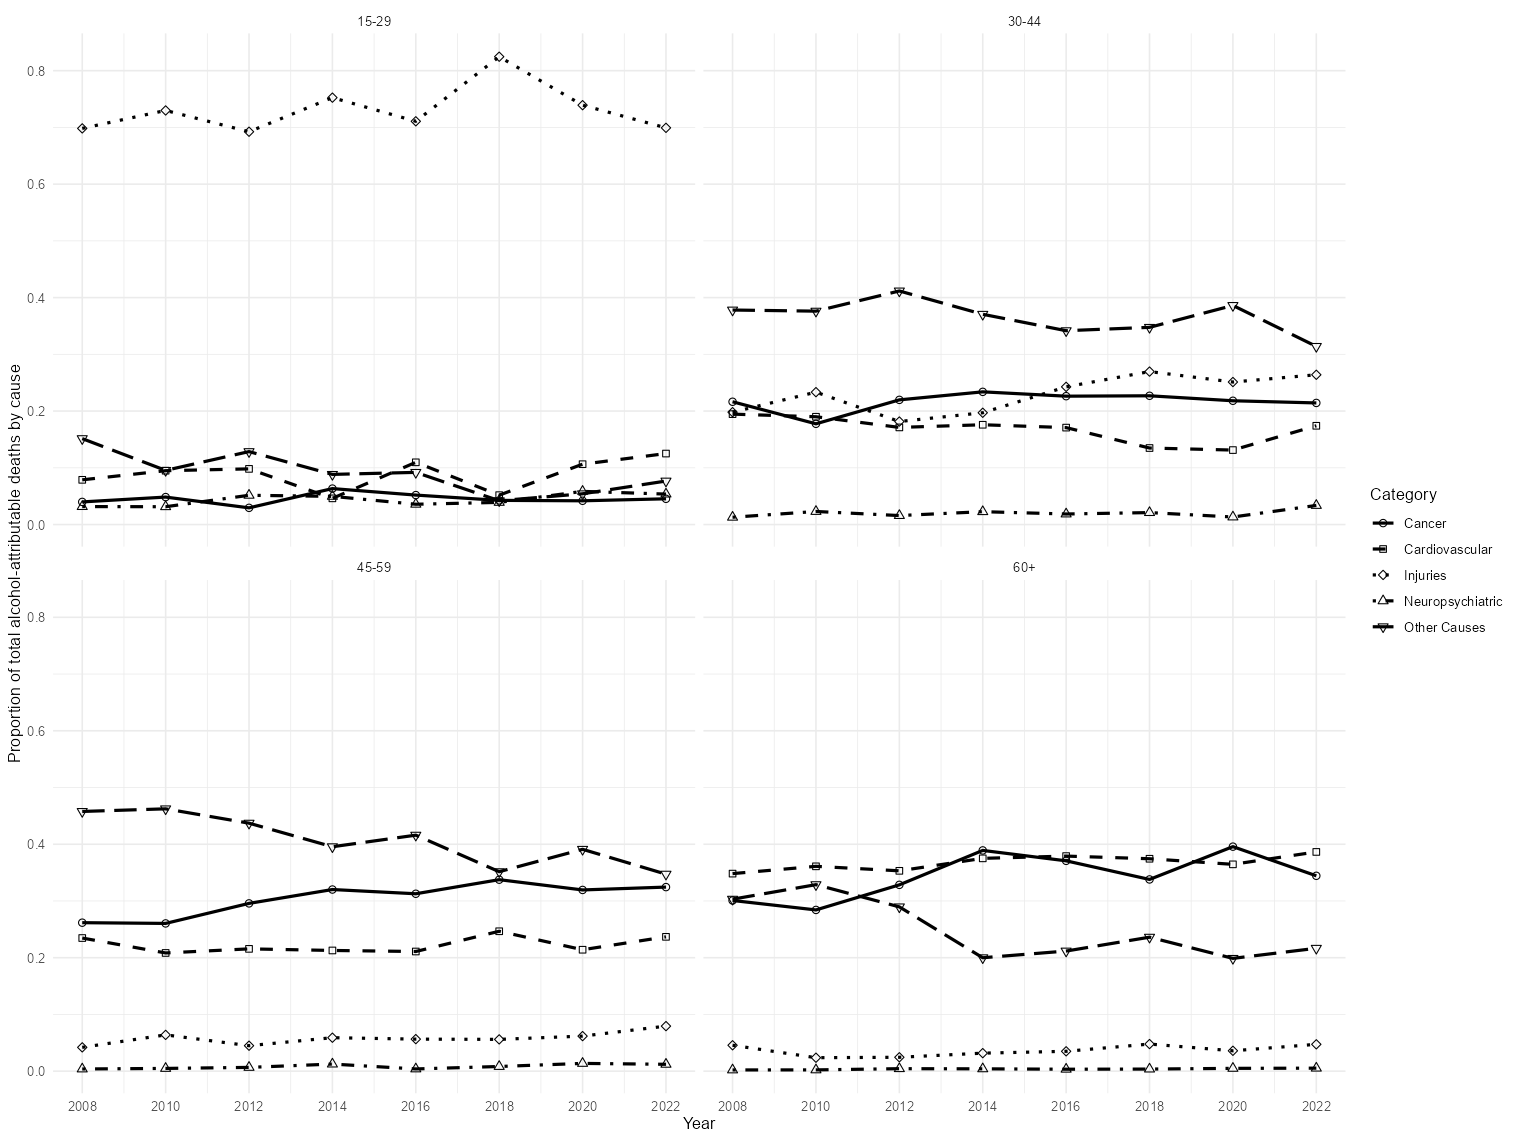

In [423]:
#| label: mort-trends-age-sex-chile21-fig
#| results: "hold"

mortality_results_cat %>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(size = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022),
    labels = c(2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022)
  ) +
  scale_shape_manual(
    values = c(
      "Cancer" = 21,
      "Cardiovascular" = 22,
      "Injuries" = 23,
      "Neuropsychiatric" = 24,
      "Other Causes" = 25
    )
  ) +
  scale_linetype_manual(
    values = c(
      "Cancer" = "solid",
      "Cardiovascular" = "dashed",
      "Injuries" = "dotted",
      "Neuropsychiatric" = "dotdash",
      "Other Causes" = "longdash"
    )
  ) +
  facet_wrap(~ age_group, labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal()

fig5 <- mortality_results_cat %>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2008, 2022, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.25, 0.50, 0.75),
    limits = c(0, 0.93)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = "__andres_control/Figure 4.png",
  plot = fig5,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

[1] "Without pancreatic and stomach cancer, women"


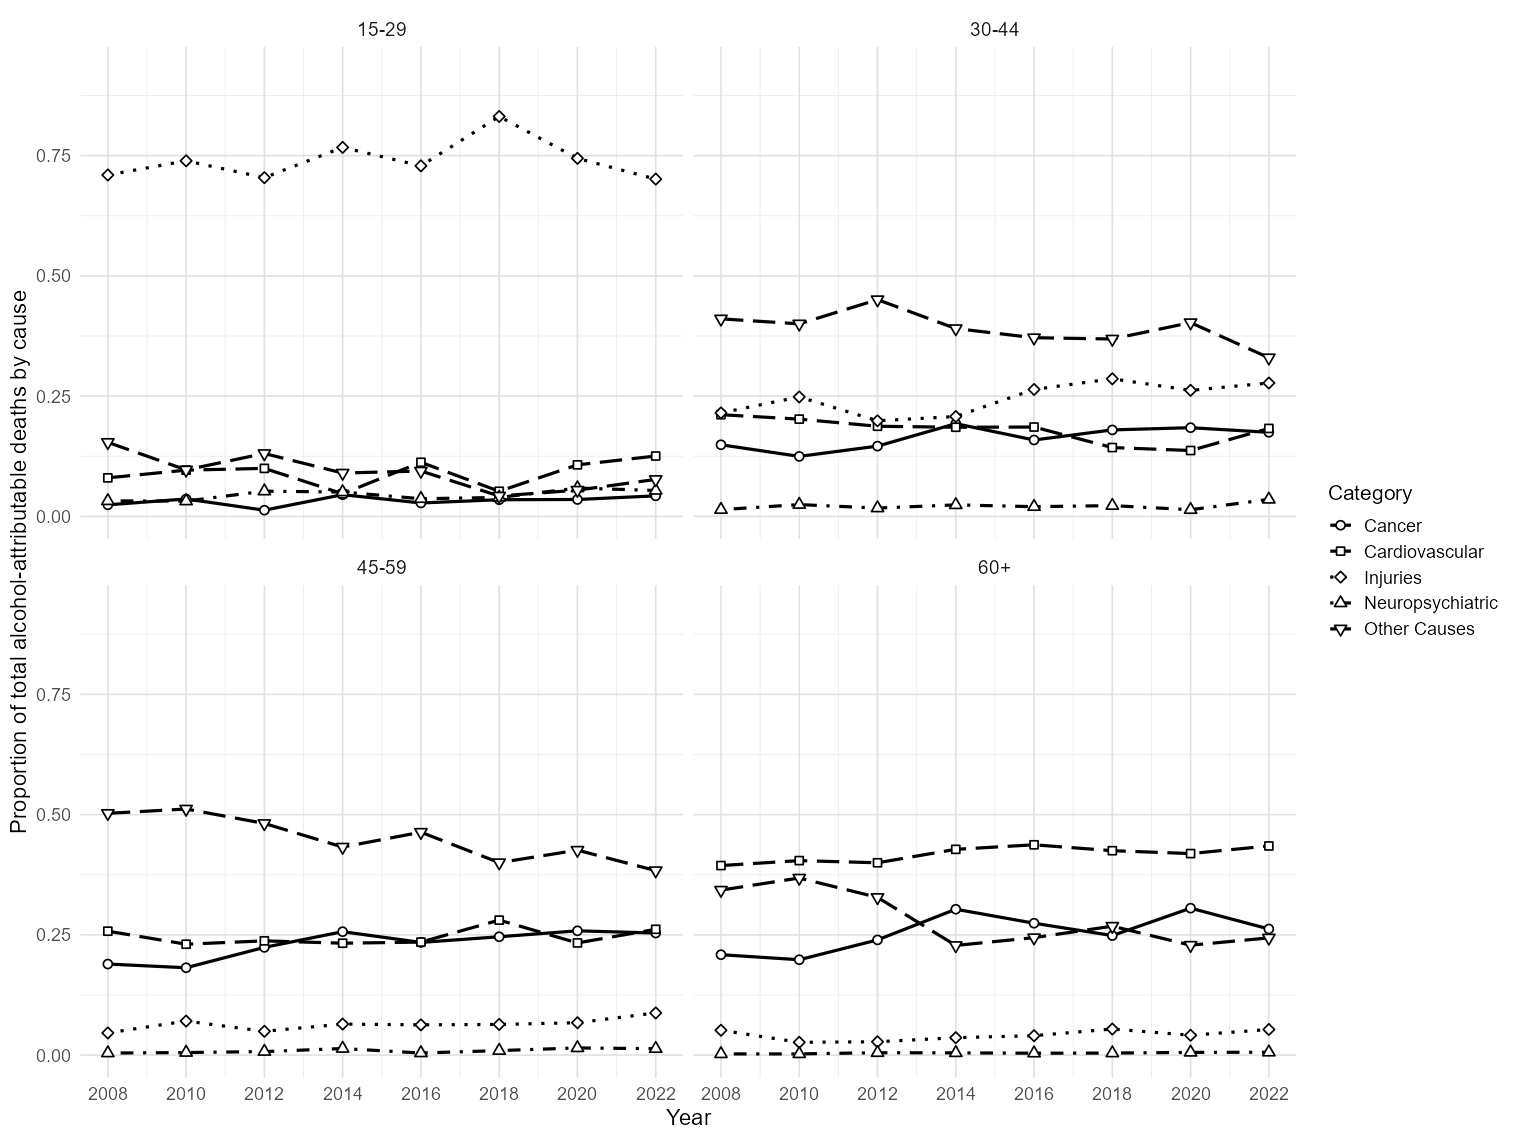

In [424]:
#| label: mort-trends-age-sex-chile21b-fig-fitlered
#| results: "hold"

print("Without pancreatic and stomach cancer, women")

mortality_results_cat_not_stomach_pancreas_cancer%>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2008, 2022, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.25, 0.50, 0.75),
    limits = c(0, 0.93)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = "__andres_control/Figure 4_not_pancreas_stomach.png",
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)


In [425]:
#| label: mort-trends-age-sex-chile21-post1
#| results: "hold"

mortality_results_cat_jrt_yr_cause_women<- 
mortality_results_cat_jrt %>%
  filter(gender == "Mujer") %>%
  group_by(age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup()

mortality_results_cat %>%
  filter(gender == "Mujer") %>%
  group_by(age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() |> 
  left_join(mortality_results_cat_jrt_yr_cause_women, by= c("age_group", "category")) |> 
  dplyr::select(age_group, category, prop_mort.x, prop_mort.y)

# A tibble: 20 × 4
   age_group category         prop_mort.x prop_mort.y
       <dbl> <chr>                  <dbl>       <dbl>
 1         1 Cancer               0.0455      0.0314 
 2         1 Cardiovascular       0.0888      0.151  
 3         1 Injuries             0.731       0.638  
 4         1 Neuropsychiatric     0.0435      0.0359 
 5         1 Other Causes         0.0914      0.144  
 6         2 Cancer               0.216       0.124  
 7         2 Cardiovascular       0.166       0.294  
 8         2 Injuries             0.233       0.184  
 9         2 Neuropsychiatric     0.0205      0.00527
10         2 Other Causes         0.364       0.393  
11         3 Cancer               0.303       0.162  
12         3 Cardiovascular       0.222       0.407  
13         3 Injuries             0.0578      0.0424 
14         3 Neuropsychiatric     0.00809     0.00217
15         3 Other Causes         0.409       0.387  
16         4 Cancer               0.343       0.134  
17       

In [426]:
#| label: mort-trends-age-sex-chile21-post2
#| results: "hold"

mortality_results_cat_jrt_yr_cause_women_more18<- 
mortality_results_cat_jrt %>%
  filter(gender == "Mujer") %>%
  mutate(more18= ifelse(year>=2018,1,0)) |> 
  group_by(age_group, more18, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, more18) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup()

mortality_results_cat %>%
  filter(gender == "Mujer") %>%
  mutate(more18= ifelse(year>=2018,1,0)) |> 
  group_by(age_group, more18, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, more18) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() |> 
  left_join(mortality_results_cat_jrt_yr_cause_women_more18, by=c("age_group", "category", "more18")) |> 
  filter(age_group==3)|> 
  dplyr::select(age_group, more18, category, prop_mort.x, prop_mort.y) #|> 

# A tibble: 10 × 5
   age_group more18 category         prop_mort.x prop_mort.y
       <dbl>  <dbl> <chr>                  <dbl>       <dbl>
 1         3      0 Cancer               0.289       0.155  
 2         3      0 Cardiovascular       0.217       0.404  
 3         3      0 Injuries             0.0532      0.0315 
 4         3      0 Neuropsychiatric     0.00606     0.00257
 5         3      0 Other Causes         0.435       0.406  
 6         3      1 Cancer               0.327       0.172  
 7         3      1 Cardiovascular       0.231       0.412  
 8         3      1 Injuries             0.0653      0.0604 
 9         3      1 Neuropsychiatric     0.0115      0.00151
10         3      1 Other Causes         0.365       0.354  

#### Tables

In [427]:
#| label: mort-trends-age-sex-chile22-tab1-women
#| results: "hold"

mortality_results %>%
  # Filter for "Mujer"
  filter(gender == "Mujer") %>% 
  # Group by year and disease (exclude age_group)
  group_by(year, disease) %>%
  # Summarize values across age groups
  summarise(
    mort = sum(round(mort,0), na.rm = TRUE),
    ci = paste0("[", sum(round(ll_mort,0), na.rm = TRUE), "-", sum(round(up_mort,0), na.rm = TRUE), "]"),
    .groups = "drop"
  ) %>%
  # Pivot years into columns
  pivot_wider(
    names_from = year,
    values_from = c(mort, ci)
  )  |>  knitr::kable("markdown", caption= "Table, women")



Table: Table, women

|disease                        | mort_2008| mort_2010| mort_2012| mort_2014| mort_2016| mort_2018| mort_2020| mort_2022|ci_2008   |ci_2010   |ci_2012   |ci_2014    |ci_2016   |ci_2018   |ci_2020   |ci_2022   |
|:------------------------------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|:---------|:---------|:---------|:----------|:---------|:---------|:---------|:---------|
|Acute Pancreatitis             |        27|        26|        20|        18|        28|        35|        29|        28|[20-38]   |[19-39]   |[12-30]   |[9-30]     |[19-39]   |[26-47]   |[17-46]   |[16-45]   |
|Breast Cancer                  |        51|        46|        45|        67|        60|        61|        79|        70|[42-60]   |[38-54]   |[37-55]   |[56-77]    |[50-70]   |[50-73]   |[67-92]   |[58-82]   |
|Colon and rectum Cancer        |        45|        42|        42|        60|        59|        68|        84|        85|[34-55]   |[

In [428]:
#| label: mort-trends-age-sex-chile23-tab2-men
#| results: "hold"

 mortality_results %>%
  # Filter for "Mujer"
  filter(gender == "Hombre") %>% 
  # Group by year and disease (exclude age_group)
  group_by(year, disease) %>%
  # Summarize values across age groups
  summarise(
    mort = sum(round(mort,0), na.rm = TRUE),
    ci = paste0("[", sum(round(ll_mort,0), na.rm = TRUE), "-", sum(round(up_mort,0), na.rm = TRUE), "]"),
    .groups = "drop"
  ) %>%
  # Pivot years into columns
  pivot_wider(
    names_from = year,
    values_from = c(mort, ci)
  ) |>  knitr::kable("markdown", caption= "Table, men")



Table: Table, men

|disease                        | mort_2008| mort_2010| mort_2012| mort_2014| mort_2016| mort_2018| mort_2020| mort_2022|ci_2008     |ci_2010     |ci_2012     |ci_2014     |ci_2016     |ci_2018     |ci_2020     |ci_2022     |
|:------------------------------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|:-----------|:-----------|:-----------|:-----------|:-----------|:-----------|:-----------|:-----------|
|Acute Pancreatitis             |        86|        84|        77|        91|        91|        94|       104|        97|[60-112]    |[60-109]    |[51-106]    |[60-120]    |[64-119]    |[66-122]    |[71-138]    |[67-130]    |
|Colon and rectum Cancer        |       259|       287|       254|       306|       355|       432|       460|       474|[229-289]   |[261-312]   |[219-290]   |[262-352]   |[314-396]   |[382-484]   |[398-521]   |[414-536]   |
|DM2                            |        42|        46|        42|        5

In [429]:
#| label: mort-trends-age-sex-chile24
#| results: "hold"

# ── 1. Total attributable deaths by year ──────────────────────────────────────
# Suma mort sobre todas las enfermedades, grupos de edad y sexo
# Nota: IHD/IS/DM2 pueden ser negativos — se incluyen (no clipear)

attr_by_year <- mortality_results |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  )
# ── 2. Total observed deaths by year (de def, solo >= 15 años) ─────────────────
total_by_year <- def |>
  dplyr::filter(!is.na(age_group)) |>          # age >= 15 ya filtrado en chile11
  dplyr::group_by(year) |>
  dplyr::summarise(total_deaths = dplyr::n(), .groups = "drop")

total_by_year_sex <- def |>
  dplyr::filter(!is.na(age_group)) |>
  dplyr::count(year, gender, name = "total_deaths")
# ── 3. Burden (%) ──────────────────────────────────────────────────────────────
burden <- attr_by_year |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_m <-  mortality_results |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::filter(gender =="Hombre") |> 
  dplyr::left_join(total_by_year_sex, by = c("year", "gender")) |> 
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_f <-  mortality_results |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::filter(gender =="Mujer") |> 
  dplyr::left_join(total_by_year_sex, by = c("year", "gender")) |> 
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
# ── 4. Rate of decline 2008 → 2022 ────────────────────────────────────────────
b2008 <- burden$burden_pct[burden$year == 2008]
b2022 <- burden$burden_pct[burden$year == 2022]
cat(sprintf("2008: %.2f%%\n2022: %.2f%%\nChange: %.1f%%\n",
            b2008, b2022, (b2022 - b2008) / b2008 * 100))

2008: 7.39%
2022: 4.87%
Change: -34.1%


In [430]:
#| label: mort-trends-age-sex-chile25
#| results: "hold"

burden |> knitr::kable("markdown", caption= "Burden by year") |>  print()
burden_m|> knitr::kable("markdown", caption= "Burden by year, Male population") |>  print()
burden_f|> knitr::kable("markdown", caption= "Burden by year, Female population") |>  print()



Table: Burden by year

| year| attr_deaths| attr_deaths_ll| attr_deaths_ul| total_deaths| burden_pct| burden_pct_ll| burden_pct_ul|
|----:|-----------:|--------------:|--------------:|------------:|----------:|-------------:|-------------:|
| 2008|    6471.032|       4397.876|       8541.910|        87595|   7.387445|      5.020693|      9.751595|
| 2010|    5907.171|       4160.311|       7734.531|        95470|   6.187463|      4.357716|      8.101530|
| 2012|    5182.157|       3370.629|       7038.823|        96377|   5.376965|      3.497337|      7.303426|
| 2014|    5398.036|       3219.561|       7538.342|        99662|   5.416343|      3.230480|      7.563908|
| 2016|    5831.277|       3862.715|       7816.501|       101963|   5.719013|      3.788349|      7.666017|
| 2018|    6321.999|       4273.502|       8402.204|       104907|   6.026289|      4.073610|      8.009193|
| 2020|    6243.568|       4063.742|       8411.197|       124706|   5.006630|      3.258658|      6.74

In [431]:
#| label: mort-trends-age-sex-chile26-major-results
#| results: "hold"

#Helpers
fmt_pct <- function(x, digits = 2) {
  paste0(formatC(x, format = "f", digits = digits), "%")
}
fmt_change <- function(x) {
  paste0(ifelse(x < 0, "\u2212", ""), formatC(abs(x), format = "f", digits = 1), "%")
}
fmt_ci <- function(x, lo, hi) {
  sprintf("%.2f%% (95%% CI: %.2f\u2013%.2f%%)", x, lo, hi)
}

#:#:#:#:#:#:#:#:
total_by_year <- def |>
  dplyr::filter(!is.na(age_group)) |>
  dplyr::count(year, name = "total_deaths")
burden <- mortality_results |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    attr_deaths    = sum(mort, na.rm = TRUE),
    attr_deaths_ll = sum(ll_mort, na.rm = TRUE),
    attr_deaths_ul = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_by_sex <- mortality_results |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths    = sum(mort, na.rm = TRUE),
    attr_deaths_ll = sum(ll_mort, na.rm = TRUE),
    attr_deaths_ul = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
b2008 <- burden |>
  dplyr::filter(year == 2008) |>
  dplyr::slice(1)
b2022 <- burden |>
  dplyr::filter(year == 2022) |>
  dplyr::slice(1)
decline_2008_2022 <-
  (b2022$burden_pct - b2008$burden_pct) / b2008$burden_pct * 100
male_2008 <- burden_by_sex |>
  dplyr::filter(year == 2008, gender == "Hombre") |>
  dplyr::pull(burden_pct)
female_2008 <- burden_by_sex |>
  dplyr::filter(year == 2008, gender == "Mujer") |>
  dplyr::pull(burden_pct)
ihd_male <- mortality_results |>
  dplyr::filter(disease == "Ischaemic Heart Disease", gender == "Hombre") |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll   = sum(ll_mort, na.rm = TRUE),
    ul   = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  )
ihd_male_text <- if (
  all(ihd_male$mort > 0, na.rm = TRUE) &&
    any(ihd_male$ll < 0 & ihd_male$ul > 0, na.rm = TRUE)
) {
  "Positive, very wide CI (straddles null)"
} else {
  "Review IHD male estimates"
}
hhd <- mortality_results |>
  dplyr::filter(disease == "Hypertensive Heart Disease") |>
  dplyr::group_by(year) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE), .groups = "drop") |>
  dplyr::arrange(year)
hhd_text <- if (
  all(hhd$mort > 0, na.rm = TRUE) &&
    dplyr::last(hhd$mort) > dplyr::first(hhd$mort)
) {
  "Positive and growing"
} else {
  "Review HHD estimates"
}
dominant_cause <- mortality_results |>
  dplyr::group_by(disease) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE), .groups = "drop") |>
  dplyr::slice_max(order_by = mort, n = 1, with_ties = FALSE) |>
  dplyr::pull(disease)
lc_text <- if (dominant_cause == "Liver Cirrhosis") {
  "Yes (unchanged)"
} else {
  paste("No:", dominant_cause)
}
young_male_injuries <- mortality_results |>
  dplyr::filter(
    gender == "Hombre",
    age_group == 1,
    stringr::str_detect(disease, stringr::regex("injur|road", ignore_case = TRUE))
  ) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE)) |>
  dplyr::pull(mort)

injury_text <- if (young_male_injuries > 0) {
  "Yes (unchanged)"
} else {
  "Review injuries in young men"
}
comparison_table <- tibble::tibble(
  Aspect = c(
    "Total burden 2008",
    "Total burden 2022",
    "Rate of decline 2008\u20132022",
    "Males burden 2008",
    "Females burden 2008",
    "IHD males",
    "HHD",
    "Liver cirrhosis dominance",
    "Injuries in young men"
  ),
  `Published paper` = c(
    "14.6%",
    "9.6%",
    "\u221234%",
    "\u2014",
    "\u2014",
    "Major positive",
    "Not highlighted",
    "Yes",
    "Yes"
  ),
  `Recent analysis` = c(
    fmt_ci(b2008$burden_pct, b2008$burden_pct_ll, b2008$burden_pct_ul),
    fmt_ci(b2022$burden_pct, b2022$burden_pct_ll, b2022$burden_pct_ul),
    fmt_change(decline_2008_2022),
    fmt_pct(male_2008),
    fmt_pct(female_2008),
    ihd_male_text,
    hhd_text,
    lc_text,
    injury_text
  )
)
comparison_table |>
  knitr::kable("markdown")



|Aspect                    |Published paper |Recent analysis            |
|:-------------------------|:---------------|:--------------------------|
|Total burden 2008         |14.6%           |7.39% (95% CI: 5.02–9.75%) |
|Total burden 2022         |9.6%            |4.87% (95% CI: 3.19–6.60%) |
|Rate of decline 2008–2022 |−34%            |−34.1%                     |
|Males burden 2008         |—               |5.58%                      |
|Females burden 2008       |—               |1.81%                      |
|IHD males                 |Major positive  |Review IHD male estimates  |
|HHD                       |Not highlighted |Positive and growing       |
|Liver cirrhosis dominance |Yes             |Yes (unchanged)            |
|Injuries in young men     |Yes             |Yes (unchanged)            |

In [432]:
#| label: mort-trends-age-sex-chile27-major-results2
#| results: "hold"

fmt_pct <- function(x, digits = 1) {
  paste0(formatC(x, format = "f", digits = digits), "%")
}
fmt_pct_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f%% (95%% CI: %.", digits, "f\u{2013}%.", digits, "f%%)"),
    x, lo, hi
  )
}
fmt_rate_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f per 100,000 (95%% CI: %.", digits, "f\u{2013}%.", digits, "f)"),
    x, lo, hi
  )
}
fmt_change <- function(x, digits = 1) {
  paste0(
    ifelse(x < 0, "\u{2212}", ""),
    formatC(abs(x), format = "f", digits = digits),
    "%"
  )
}

def_analysis <- def |>
  dplyr::filter(!is.na(age_group))

deaths_total <- def_analysis |>
  dplyr::count(year, name = "n")

deaths_sex <- def_analysis |>
  dplyr::count(year, gender, name = "n")

burden_total <- mortality_results |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_total, by = "year") |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )

burden_sex <- mortality_results |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_sex, by = c("year", "gender")) |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )

total_2008 <- burden_total |> dplyr::filter(year == 2008)
total_2022 <- burden_total |> dplyr::filter(year == 2022)
male_2022 <- burden_sex |> dplyr::filter(year == 2022, gender == "Hombre")
female_2022 <- burden_sex |> dplyr::filter(year == 2022, gender == "Mujer")

decline_total <- (total_2022$prop - total_2008$prop) / total_2008$prop * 100

lowest_total_rate <- std_rates |>
  dplyr::filter(gender == "Total") |>
  dplyr::slice_min(order_by = std_mort_rate, n = 1, with_ties = FALSE)

post_2012_peak_total_rate <- std_rates |>
  dplyr::filter(gender == "Total", year > 2012) |>
  dplyr::slice_max(order_by = std_mort_rate, n = 1, with_ties = FALSE)

total_rate_2022 <- std_rates |> dplyr::filter(year == 2022, gender == "Total")
male_rate_2022 <- std_rates |> dplyr::filter(year == 2022, gender == "Male")
female_rate_2022 <- std_rates |> dplyr::filter(year == 2022, gender == "Female")

extended_comparison <- tibble::tibble(
  Aspect = c(
    "Total burden 2008",
    "Total burden 2022",
    "Rate of decline 2008-2022",
    "Lowest total mortality rate",
    "Post-2012 peak total mortality rate",
    "Total mortality rate 2022",
    "Male burden 2022",
    "Female burden 2022",
    "Male mortality rate 2022",
    "Female mortality rate 2022"
  ),
  `Published paper` = c(
    "14.6% (95% CI: 10.9-18.4%)",
    "9.6% (95% CI: 7.2-12.2%)",
    "\u{2212}34%",
    "2012: 62 per 100,000",
    "2018 peak",
    "65.4 per 100,000",
    "12.4%",
    "6.4%",
    "84.4 per 100,000",
    "38.4 per 100,000"
  ),
  `Recent analysis` = c(
    fmt_pct_ci(total_2008$prop, total_2008$ll_prop, total_2008$up_prop),
    fmt_pct_ci(total_2022$prop, total_2022$ll_prop, total_2022$up_prop),
    
    fmt_change(decline_total),
    paste0(lowest_total_rate$year, ": ", fmt_rate_ci(
      lowest_total_rate$std_mort_rate,
      lowest_total_rate$ll_std_mort_rate,
      lowest_total_rate$up_std_mort_rate
    )),
    paste0(post_2012_peak_total_rate$year, ": ", fmt_rate_ci(
      post_2012_peak_total_rate$std_mort_rate,
      post_2012_peak_total_rate$ll_std_mort_rate,
      post_2012_peak_total_rate$up_std_mort_rate
    )),
    fmt_rate_ci(
      total_rate_2022$std_mort_rate,
      total_rate_2022$ll_std_mort_rate,
      total_rate_2022$up_std_mort_rate
    ),
    fmt_pct_ci(male_2022$prop, male_2022$ll_prop, male_2022$up_prop),
    fmt_pct_ci(female_2022$prop, female_2022$ll_prop, female_2022$up_prop),
    fmt_rate_ci(
      male_rate_2022$std_mort_rate,
      male_rate_2022$ll_std_mort_rate,
      male_rate_2022$up_std_mort_rate
    ),
    fmt_rate_ci(
      female_rate_2022$std_mort_rate,
      female_rate_2022$ll_std_mort_rate,
      female_rate_2022$up_std_mort_rate
    )
  )
)

extended_comparison |>
  knitr::kable("markdown")



|Aspect                              |Published paper            |Recent analysis                            |
|:-----------------------------------|:--------------------------|:------------------------------------------|
|Total burden 2008                   |14.6% (95% CI: 10.9-18.4%) |7.4% (95% CI: 5.0–9.8%)                    |
|Total burden 2022                   |9.6% (95% CI: 7.2-12.2%)   |4.9% (95% CI: 3.2–6.6%)                    |
|Rate of decline 2008-2022           |−34%                       |−34.1%                                     |
|Lowest total mortality rate         |2012: 62 per 100,000       |2020: 39.0 per 100,000 (95% CI: 25.4–52.5) |
|Post-2012 peak total mortality rate |2018 peak                  |2018: 42.0 per 100,000 (95% CI: 28.4–55.8) |
|Total mortality rate 2022           |65.4 per 100,000           |39.0 per 100,000 (95% CI: 25.6–52.9)       |
|Male burden 2022                    |12.4%                      |7.0% (95% CI: 4.6–9.4%)                    |

In [433]:
#| label: mort-trends-age-sex-chile27b-major-results2-who-scope
#| results: "hold"
mortality_results_who_scope <- mortality_results |>
  dplyr::filter(!disease %in% c("Stomach Cancer", "Pancreatic Cancer"))

burden_total_who_scope <- mortality_results_who_scope |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_total, by = "year") |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )
burden_sex_who_scope <- mortality_results_who_scope |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_sex, by = c("year", "gender")) |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )

std_rates_who_scope <- dplyr::bind_rows(
  make_std_rate(mortality_results_who_scope, spw_tot, "Total"),
  make_std_rate(
    mortality_results_who_scope |> dplyr::filter(gender == "Hombre"),
    spw_male,
    "Hombre"
  ),
  make_std_rate(
    mortality_results_who_scope |> dplyr::filter(gender == "Mujer"),
    spw_fem,
    "Mujer"
  )
)

fmt_rate_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f (95%% CI: %.", digits, "f–%.", digits, "f)"),
    x, lo, hi
  )
}

print(paste0("std. mortality rate w/o stomach & pancreatic cancer: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2022 & std_rates_who_scope$gender=="Total"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("std. mortality rate w/o stomach & pancreatic cancer, men: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2022 & std_rates_who_scope$gender=="Hombre"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("std. mortality rate w/o stomach & pancreatic cancer, women: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2022 & std_rates_who_scope$gender=="Mujer"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer: ", 
with(burden_total_who_scope[which(burden_total_who_scope$year==2022),], 
fmt_pct_ci(prop, ll_prop, up_prop))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer, men: ", 
with(burden_sex_who_scope[which(burden_sex_who_scope$year==2022 & burden_sex_who_scope$gender=="Hombre"),], 
fmt_pct_ci(prop, ll_prop, up_prop))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer, women: ", 
with(burden_sex_who_scope[which(burden_sex_who_scope$year==2022 & burden_sex_who_scope$gender=="Mujer"),], 
fmt_pct_ci(prop, ll_prop, up_prop))))


[1] "std. mortality rate w/o stomach & pancreatic cancer: 36.8 (95% CI: 23.9–50.1)"
[1] "std. mortality rate w/o stomach & pancreatic cancer, men: 60.4 (95% CI: 39.7–81.3)"
[1] "std. mortality rate w/o stomach & pancreatic cancer, women: 15.9 (95% CI: 9.8–22.4)"
[1] "alcohol burden w/o stomach & pancreatic cancer: 4.6% (95% CI: 3.0–6.2%)"
[1] "alcohol burden w/o stomach & pancreatic cancer, men: 6.7% (95% CI: 4.4–9.0%)"
[1] "alcohol burden w/o stomach & pancreatic cancer, women: 2.3% (95% CI: 1.4–3.2%)"


In [434]:
cats_106 <- c("Breast Cancer","Colon and rectum Cancer","Larynx Cancer",
  "Oral Cavity and Pharynx Cancer","Other Pharyngeal Cancer","Liver Cancer",
  "Oesophagus Cancer","Stomach Cancer","Pancreatic Cancer",
  "Intentional Injuries","Road Injuries","Unintentional Injuries",
  "Hypertensive Heart Disease","Intracerebral Haemorrhage","Ischaemic Heart Disease",
  "Ischaemic Stroke","DM2","Liver Cirrhosis","Lower Respiratory Infection",
  "Tuberculosis","Acute Pancreatitis","HIV","Epilepsy")
setdiff(unique(mortality_results$disease), cats_106)   # lo que cae en NA en Fig 4/5


character(0)

We introduced the WHO WOrld 15+ weights (fraction of all-ages) 15-29= 0.2462, 30-44=0.2135, 45-59= 0.1596 and 60+= 0.11955 (which sums 0.7388)

In [435]:
#| label: mort-trends-age-sex-chile27c-who-scope-whostd
#| results: "hold"

# WHO-scope (sin Stomach/Pancreatic) RE-ESTANDARIZADO a WHO World Standard.
# Pesos grupos 1-4 (15-29/30-44/45-59/60+) suman 0.7388 -> NO renormalizar
# (renormalizar a 1 = WHO-15+, infla ~1.35x y rompe comparabilidad con GHO all-ages).
spw_tot_who  <- pop_tot  |> dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_who_world_all_age, by = "age_group")
spw_male_who <- pop_male |> dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_who_world_all_age, by = "age_group")
spw_fem_who  <- pop_fem  |> dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_who_world_all_age, by = "age_group")

std_rates_who_scope_whostd <- dplyr::bind_rows(
  make_std_rate(mortality_results_who_scope,
                spw_tot_who,  "Total"),
  make_std_rate(mortality_results_who_scope |> dplyr::filter(gender == "Hombre"),
                spw_male_who, "Male"),
  make_std_rate(mortality_results_who_scope |> dplyr::filter(gender == "Mujer"),
                spw_fem_who,  "Female")
)

for (gg in c("Total", "Male", "Female")) {
  r <- std_rates_who_scope_whostd[
    std_rates_who_scope_whostd$year == 2022 & std_rates_who_scope_whostd$gender == gg, ]
  print(paste0("WHO-World std, w/o stomach & pancreatic cancer, ", gg, ": ",
               fmt_rate_ci(r$std_mort_rate, r$ll_std_mort_rate, r$up_std_mort_rate)))
}

std_rates_who_scope_whostd |>
  knitr::kable("markdown", caption = "WHO-scope, standardized to WHO World")


[1] "WHO-World std, w/o stomach & pancreatic cancer, Total: 23.7 (95% CI: 15.3–32.3)"
[1] "WHO-World std, w/o stomach & pancreatic cancer, Male: 39.0 (95% CI: 25.5–52.6)"
[1] "WHO-World std, w/o stomach & pancreatic cancer, Female: 9.9 (95% CI: 6.1–13.9)"




Table: WHO-scope, standardized to WHO World

| year| std_mort_rate| ll_std_mort_rate| up_std_mort_rate|gender |
|----:|-------------:|----------------:|----------------:|:------|
| 2008|     34.249476|        23.059258|         45.43580|Total  |
| 2010|     29.522859|        20.561291|         38.90790|Total  |
| 2012|     24.495556|        15.810717|         33.40800|Total  |
| 2014|     24.164866|        14.314745|         33.85602|Total  |
| 2016|     24.572539|        16.131706|         33.12581|Total  |
| 2018|     24.884750|        16.616611|         33.31156|Total  |
| 2020|     23.440507|        15.121615|         31.75596|Total  |
| 2022|     23.652114|        15.310113|         32.25866|Total  |
| 2008|     57.412897|        38.776246|         75.82496|Male   |
| 2010|     49.284795|        35.042748|         64.19231|Male   |
| 2012|     41.746529|        27.288021|         56.61096|Male   |
| 2014|     41.047116|        25.449249|         56.63400|Male   |
| 2016|     40.

### Reference metrics

**WHO 2024, Alcohol-attributable, age-standardized death rates, per 100,000 population**

| Indicator                                | Sex         | Age group   | Rate | IC 95%        |
|:-----------------------------------------|:-------------|:---------------|-----:|:--------------|
| Alcohol-attributable all-cause deaths    | Both sexes   | All age groups | 23.3 | [18.8 - 28.5] |
| Alcohol-attributable all-cause deaths    | Male         | All age groups | 42.3 | [33.3 - 51.9] |
| Alcohol-attributable all-cause deaths    | Female       | All age groups |  6.5 | [4.1 - 9.6]   |
| Cancer, alcohol-attributable             | Female       | All age groups |  1.8 | [1.2 - 2.5]   |
| Cancer, alcohol-attributable             | Female       | 15+ years      |  2.4 | [1.6 - 3.4]   |
| Cancer, alcohol-attributable             | Both sexes   | All age groups |  3.3 | [2.5 - 4.0]   |
| Cancer, alcohol-attributable             | Both sexes   | 15+ years      |  4.5 | [3.3 - 5.6]   |
| Cancer, alcohol-attributable             | Male         | All age groups |  5.3 | [4.0 - 6.5]   |
| Cancer, alcohol-attributable             | Male         | 15+ years      |  7.2 | [5.3 - 8.9]   |
| Liver cirrhosis, alcohol-attributable    | Male         | All age groups | 11.0 | [8.0 - 13.2]  |
| Liver cirrhosis, alcohol-attributable    | Male         | 15+ years      | 14.9 | [10.5 - 17.9] |
| Liver cirrhosis, alcohol-attributable    | Female       | All age groups |  2.3 | [1.8 - 2.8]   |
| Liver cirrhosis, alcohol-attributable    | Female       | 15+ years      |  3.2 | [2.5 - 3.8]   |
| Liver cirrhosis, alcohol-attributable    | Both sexes   | All age groups |  6.4 | [4.8 - 7.6]   |
| Liver cirrhosis, alcohol-attributable    | Both sexes   | 15+ years      |  8.7 | [6.4 - 10.3]  |
| Road traffic crashes, alcohol-attributable | Female     | All age groups |  1.9 | [1.4 - 2.6]   |
| Road traffic crashes, alcohol-attributable | Male       | 15+ years      | 11.2 | [7.3 - 16.2]  |
| Road traffic crashes, alcohol-attributable | Female     | 15+ years      |  2.1 | [1.6 - 3.0]   |
| Road traffic crashes, alcohol-attributable | Both sexes | All age groups |  5.1 | [3.5 - 7.3]   |
| Road traffic crashes, alcohol-attributable | Both sexes | 15+ years      |  6.6 | [4.4 - 9.4]   |
| Road traffic crashes, alcohol-attributable | Male       | All age groups |  8.5 | [5.6 - 12.5]  |

*Note. https://www.who.int/data/gho/data/indicators/indicator-details/GHO/alcohol-attributable-all-cause-deaths--age-standardized-death-rates-(all-ages)--per-100-000-population*

 **Mortality rate by age group, Chile (DEIS)**

| Age group | Rate per 1,000 inhabitants |
| --- | --- |
| 20–44 years | 0.91 |
| 45–64 years | 4.50 |
| 65–79 years | 20.06 |

**Leading Causes of Death (Chile, DEIS)**

| Cause | Rate per 100,000 | Percentage |
| --- | --- | --- |
| Circulatory system diseases | 150.38 | 26.40% |
| Tumors (Cancer) | 148.85 | 26.14% |
| External causes | 41.14 | 7.22% |

**Specific Cause-Specific Mortality Rates (Chile, DEIS)**

| Código CIE-10 | Causa seleccionada | Defunciones total | % del total | Tasa total | Defunciones hombres | Tasa hombres | Defunciones mujeres | Tasa mujeres |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Todas las causas | Todas las causas | 106.796 | 100,00 | 569,54 | 56.093 | 606,77 | 50.684 | 533,13 |
| C00-D48 | Tumores (neoplasias) | 27.912 | 26,13 | 148,85 | 14.604 | 157,98 | 13.308 | 139,98 |
| I00-I99 | Enfermedades del sistema circulatorio | 28.199 | 26,40 | 150,38 | 14.354 | 155,27 | 13.845 | 145,63 |
| J00-J99 | Enfermedades del sistema respiratorio | 12.228 | 11,45 | 65,21 | 6.073 | 65,69 | 6.155 | 64,74 |
| K00-K93 | Enfermedades del sistema digestivo | 7.913 | 7,41 | 42,20 | 4.586 | 49,61 | 3.327 | 35,00 |
| V01-Y98 | Causa externa de mortalidad | 7.715 | 7,22 | 41,14 | 5.773 | 62,45 | 1.942 | 20,43 |
| C16.- | Tumor maligno del estómago | 3.165 | 2,96 | 16,88 | 2.153 | 23,29 | 1.012 | 10,64 |
| C33-C34 | Tumor maligno de tráquea, bronquios y pulmón | 3.307 | 3,10 | 17,64 | 1.959 | 21,19 | 1.348 | 14,18 |
| E10-E14 | Diabetes mellitus | 3.207 | 3,00 | 17,10 | 1.580 | 17,09 | 1.627 | 17,11 |
| I10-I13 | Enfermedades hipertensivas | 6.088 | 5,70 | 32,47 | 2.492 | 26,96 | 3.596 | 37,83 |
| I20-I25 | Enfermedad isquémica del corazón | 8.020 | 7,51 | 42,77 | 4.943 | 53,47 | 3.077 | 32,37 |
| I60-I69 | Enfermedades cerebrovasculares | 8.033 | 7,52 | 42,84 | 3.929 | 42,50 | 4.104 | 43,17 |
| J12-J18 | Neumonía | 4.324 | 4,05 | 23,06 | 2.115 | 22,88 | 2.209 | 23,24 |
| J40-J44 | Bronquitis, enfisema y otras enfermedades pulmonares obstructivas crónicas | 3.331 | 3,12 | 17,76 | 1.692 | 18,30 | 1.639 | 17,24 |
| K70-K76 | Cirrosis hepática y otras enfermedades crónicas del hígado | 4.052 | 3,79 | 21,61 | 2.783 | 30,10 | 1.269 | 13,35 |
| V01-V99** | Accidentes de tránsito | 1.790 | 1,68 | 9,55 | 1.378 | 14,91 | 412 | 4,33 |
| X60-X84 | Lesiones autoinfligidas intencionalmente | 1.823 | 1,71 | 9,72 | 1.507 | 16,30 | 316 | 3,32 |


*Source. Departamento de Estadísticas e Información de Salud (DEIS), Ministerio de Salud. Indicadores básicos de salud, Chile 2018. Santiago: Ministerio de Salud; 2018. Disponible en: https://repositoriodeis.minsal.cl/Deis/indicadores/IBS%202018.pdf*

****Number of deaths by sex and mortality rates, 2022**

| Age group | Total deaths | Male deaths | Female deaths | Male mortality rate | Female mortality rate | Male excess mortality |
|---|---:|---:|---:|---:|---:|---:|
| Total | 136,969 | 71,684 | 65,278 | 7.3 | 6.5 | 1.1 |
| 0 years | 1,110 | 612 | 491 | 5.1 | 4.2 | 1.2 |
| 1-4 years | 210 | 112 | 98 | 0.2 | 0.2 | 1.1 |
| 5-9 years | 169 | 94 | 75 | 0.1 | 0.1 | 1.2 |
| 10-14 years | 206 | 117 | 89 | 0.2 | 0.1 | 1.3 |
| 15-19 years | 562 | 404 | 158 | 0.6 | 0.3 | 2.5 |
| 20-24 years | 1,008 | 780 | 228 | 1.1 | 0.3 | 3.3 |
| 25-29 years | 1,256 | 939 | 317 | 1.2 | 0.4 | 2.9 |
| 30-34 years | 1,575 | 1,165 | 410 | 1.4 | 0.5 | 2.8 |
| 35-39 years | 1,738 | 1,213 | 525 | 1.6 | 0.7 | 2.3 |
| 40-44 years | 2,274 | 1,504 | 770 | 2.2 | 1.1 | 1.9 |
| 45-49 years | 3,186 | 2,120 | 1,066 | 3.2 | 1.6 | 2.0 |
| 50-54 years | 4,540 | 2,967 | 1,573 | 4.9 | 2.5 | 1.9 |
| 55-59 years | 6,869 | 4,413 | 2,456 | 7.7 | 4.0 | 1.9 |
| 60-64 years | 9,119 | 5,628 | 3,491 | 11.4 | 6.4 | 1.8 |
| 65-69 years | 11,625 | 7,019 | 4,606 | 17.2 | 9.9 | 1.7 |
| 70-74 years | 13,710 | 7,929 | 5,781 | 26.9 | 16.3 | 1.7 |
| 75-79 years | 17,027 | 9,290 | 7,737 | 47.9 | 30.2 | 1.6 |
| 80-84 years | 18,771 | 9,477 | 9,294 | 80.1 | 51.6 | 1.6 |
| 85-89 years | 18,404 | 8,096 | 10,308 | 132.7 | 92.3 | 1.4 |
| 90-94 years | 15,658 | 5,683 | 9,975 | 209.0 | 165.8 | 1.3 |
| 95-99 years | 6,457 | 1,807 | 4,650 | 263.2 | 237.8 | 1.1 |
| 100 years or older | 1,495 | 315 | 1,180 | 302.9 | 268.0 | 1.1 |

Source: *https://www.ine.gob.cl/docs/default-source/nacimientos-matrimonios-y-defunciones/publicaciones-y-anuarios/s%C3%ADntesis-anuarios-de-estad%C3%ADsticas-vitales/anuario-de-estad%C3%ADsticas-vitales-2022-s%C3%ADntesis.pdf?sfvrsn=4838c658_4*

## MWE

In [436]:
rm(list = ls()); gc()

library(MicSim)
#source("Simulacion/patch_micSim.R")
source(paste0(gsub("/__andres_control","",getwd()),"/","Simulacion/patch_micSim.R"))

# -----------------------------
# 1. Simulation setup
# -----------------------------
startDate <- 20140101
endDate <- 20241231
simHorizon <- c(startDate = startDate, endDate = endDate)
set.seed(234)
maxAge <- 100
monthSchoolEnrol <- 9

# -----------------------------
# 2. Define state space
# -----------------------------
sex <- c("m", "f")
fert <- c("0", "1+")
marital <- c("NM", "M", "D", "W")
edu <- c("no", "low", "med", "high")
drink <- c("Abstainer", "Moderate", "Heavy")

stateSpace <- expand.grid(
  sex = sex,
  fert = fert,
  marital = marital,
  edu = edu,
  drink = drink
)
absStates <- c("dead", "rest")

# -----------------------------
# 3. Initial population
# -----------------------------
N <- 25
birthDates <- runif(N, min = getInDays(19500101), max = getInDays(20131231))

getRandInitState <- function(birthDate, refDate = simHorizon[1]) {
  age <- trunc((getInDays(refDate) - birthDate) / 365.25)
  s1 <- sample(sex, 1)
  s2 <- ifelse(age <= 18, fert[1], sample(fert, 1))
  s3 <- ifelse(
    age <= 18,
    marital[1],
    ifelse(age <= 22, sample(marital[1:3], 1), sample(marital, 1))
  )
  s4 <- ifelse(
    age <= 7,
    edu[1],
    ifelse(age <= 18, edu[2], ifelse(age <= 23, sample(edu[2:3], 1), sample(edu[-1], 1)))
  )
  s5 <- sample(drink, 1, prob = c(0.4, 0.4, 0.2))

  paste(c(s1, s2, s3, s4, s5), collapse = "/")
}
initPop <- data.frame(
  ID = 1:N,
  birthDate = getInDateFormat(birthDates),
  initState = sapply(birthDates, getRandInitState)
)
# -----------------------------
# 4. Immigrants
# -----------------------------
M <- 5
immigrDates <- runif(M, min = getInDays(20140101), max = getInDays(20241231))
immigrAges <- runif(M, min = 15 * 365.25, max = 70 * 365.25)
immigrBirthDates <- immigrDates - immigrAges
IDmig <- max(initPop$ID) + 1:M

immigrPop <- data.frame(
  ID = IDmig,
  immigrDate = getInDateFormat(immigrDates),
  birthDate = getInDateFormat(immigrBirthDates),
  immigrInitState = mapply(getRandInitState, immigrBirthDates, immigrDates)
)
# -----------------------------
# 5. Newborn initial states
# -----------------------------
varInitStates <- rbind(
  c("m", "0", "NM", "no", "Abstainer"),
  c("f", "0", "NM", "no", "Abstainer")
)
initStatesProb <- c(0.515, 0.485)
# -----------------------------
# 6. Transition functions
# -----------------------------
fert1Rates <- function(age, calTime) {
  b <- ifelse(calTime <= 2020, 3.9, 3.3)
  c <- ifelse(calTime <= 2020, 28, 29)
  rate <- (b / c) * (c / age)^(3 / 2) * exp(-b^2 * (c / age + age / c - 2))
  rate[age <= 15 | age >= 45] <- 0
  rate
}
fert2Rates <- function(age, calTime, duration) {
  b <- ifelse(calTime <= 2020, 3.2, 2.8)
  c <- ifelse(calTime <= 2020, 32, 33)
  rate <- (b / c) * (c / age)^(3 / 2) * exp(-b^2 * (c / age + age / c - 2))
  rate[age <= 15 | age >= 45 | duration < 0.75] <- 0
  rate
}
marriage1Rates <- function(age, calTime) {
  rate <- dnorm(age, mean = ifelse(calTime <= 2020, 25, 30), sd = 3)
  rate[age <= 16] <- 0
  rate
}
marriage2Rates <- function(age, calTime) {
  b <- ifelse(calTime <= 2020, 0.07, 0.10)
  p <- 2.7
  lambda <- ifelse(calTime <= 1950, 0.04, 0.03)
  rate <- b * p * (lambda * age)^(p - 1) / (1 + (lambda * age)^p)
  rate[age <= 18] <- 0
  rate
}
divorceRates <- function(age, calTime) {
  rate <- dnorm(age, mean = 40, sd = ifelse(calTime <= 2020, 7, 6))
  rate[age <= 18] <- 0
  rate
}
widowhoodRates <- function(age, calTime) {
  ifelse(age <= 30, 0, pgamma(age - 30, shape = 6, rate = 0.06))
}
noToLowEduRates <- function(age, calTime) {
  ifelse(age == 7, Inf, 0)
}
lowToMedEduRates <- function(age, calTime) {
  rate <- dnorm(age, mean = 16, sd = 1)
  rate[age <= 15 | age >= 25] <- 0
  rate
}
medToHighEduRates <- function(age, calTime) {
  rate <- dnorm(age, mean = 20, sd = 3)
  rate[age <= 18 | age >= 35] <- 0
  rate
}
emigrRates <- function(age, calTime) {
  ifelse(age <= 18, 0, 0.0025)
}
ModerateDead <- function(age, calTime) {
  a <- 0.00005
  b <- 0.09
  a * exp(b * age)
}
HeavyDead <- function(age, calTime) {
  a <- 0.0001
  b <- 0.1
  a * exp(b * age)
}

# -----------------------------
# 7. Transition matrix
# -----------------------------
fertTrMatrix <- cbind(c("0->1+", "1+->1+"), c("fert1Rates", "fert2Rates"))

maritalTrMatrix <- cbind(
  c("NM->M", "M->D", "M->W", "D->M", "W->M"),
  c("marriage1Rates", "divorceRates", "widowhoodRates", "marriage2Rates", "marriage2Rates")
)
eduTrMatrix <- cbind(
  c("no->low", "low->med", "med->high"),
  c("noToLowEduRates", "lowToMedEduRates", "medToHighEduRates")
)
allTransitions <- rbind(fertTrMatrix, maritalTrMatrix, eduTrMatrix)
absTransitions <- rbind(
  c("Moderate/dead", "ModerateDead"),
  c("Heavy/dead", "HeavyDead"),
  c("rest", "emigrRates")
)
transitionMatrix <- buildTransitionMatrix(
  allTransitions = allTransitions,
  absTransitions = absTransitions,
  stateSpace = stateSpace
)
fertTr <- fertTrMatrix[, 1]

# -----------------------------
# 8. Run simulation
# -----------------------------
pop <- micSim(
  initPop = initPop,
  immigrPop = immigrPop,
  transitionMatrix = transitionMatrix,
  absStates = absStates,
  varInitStates = varInitStates,
  initStatesProb = initStatesProb,
  maxAge = maxAge,
  simHorizon = simHorizon,
  fertTr = fertTr,
  monthSchoolEnrol = monthSchoolEnrol
)
if ("motherID" %in% names(pop)) {
  pop$motherID <- NULL
}
# -----------------------------
# 9. Output
# -----------------------------
head(pop, 10)
table(pop$To)

micSim wrapper loaded in .GlobalEnv. MicSim namespace was not modified.
Initialization ... 
[1] "Starting at:  2026-06-02 18:57:49.932587"
[1] "Ending at:  2026-06-02 18:57:50.740318"
Simulation is running ... 
Year:  2014 
Year:  2015 
Year:  2016 
Year:  2017 
Year:  2018 
Year:  2019 
Year:  2020 
Year:  2021 
Year:  2022 
Year:  2023 
Year:  2024 
Simulation has finished.
------------------



                  dead     f/0/D/low/Moderate     f/0/M/low/Moderate     f/0/M/med/Moderate    f/1+/D/low/Moderate    f/1+/D/med/Moderate  f/1+/M/high/Abstainer    f/1+/M/low/Moderate    f/1+/M/med/Moderate 
                     2                      1                      2                      1                      2                      1                      1                      1                      1 
 f/1+/NM/low/Abstainer    f/1+/NM/no/Moderate    f/1+/W/low/Moderate  m/0/NM/high/Abstainer      m/0/NM/high/Heavy   m/0/NM/med/Abstainer       m/0/NM/med/Heavy  m/1+/D/high/Abstainer    m/1+/D/low/Moderate 
                     1                      1                      1                      2                      1                      2                      1                      1                      1 
 m/1+/M/high/Abstainer      m/1+/M/high/Heavy   m/1+/M/low/Abstainer   m/1+/M/med/Abstainer m/1+/NM/high/Abstainer     m/1+/NM/high/Heavy  m/1+/NM/low/Abstainer   m/1+

## References

::: {#refs}
:::